# Improved main baseline

This copy keeps the baseline MSE training objective and fixes consistency issues only: current-control alignment in diagnostics, denormalized NN corrections before integration, physics-only predictions through the same one-step integrator, updated fitted-rate surrogate text, and NED vertical thrust sign.


In [1]:
import torch

def wrap_to_pi(a):
    """Wrap angles to [-pi, pi]."""
    return torch.atan2(torch.sin(a), torch.cos(a))


# ---------------------------------------------------------------------------
# Quaternion helpers (singularity-free attitude representation)
# ---------------------------------------------------------------------------

def euler_to_quat(roll, pitch, yaw):
    """
    Convert ZYX Euler angles to unit quaternion [w, x, y, z].
    roll, pitch, yaw: (B,) tensors  ->  returns (B,4)
    """
    cr, sr = torch.cos(roll * 0.5), torch.sin(roll * 0.5)
    cp, sp = torch.cos(pitch * 0.5), torch.sin(pitch * 0.5)
    cy, sy = torch.cos(yaw * 0.5), torch.sin(yaw * 0.5)
    qw = cr * cp * cy + sr * sp * sy
    qx = sr * cp * cy - cr * sp * sy
    qy = cr * sp * cy + sr * cp * sy
    qz = cr * cp * sy - sr * sp * cy
    return torch.stack([qw, qx, qy, qz], dim=1)  # (B,4)


def quat_mul(q1, q2):
    """
    Hamilton product q1 x q2.
    q1, q2: (B,4) as [w, x, y, z]  ->  returns (B,4)
    """
    w1, x1, y1, z1 = q1[:, 0], q1[:, 1], q1[:, 2], q1[:, 3]
    w2, x2, y2, z2 = q2[:, 0], q2[:, 1], q2[:, 2], q2[:, 3]
    return torch.stack([
        w1*w2 - x1*x2 - y1*y2 - z1*z2,
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2,
    ], dim=1)  # (B,4)


def quat_normalize(q, eps=1e-8):
    """Normalize quaternion to unit length. q: (B,4) -> (B,4)"""
    return q / (q.norm(dim=1, keepdim=True) + eps)


def omega_to_quat_delta(omega, dt):
    """
    Quaternion increment from body-frame angular velocity (exact axis-angle).
    omega: (B,3) [wx, wy, wz]  dt: (B,1) or scalar  ->  returns (B,4)
    """
    half_angle_vec = 0.5 * omega * dt              # (B,3)
    angle = half_angle_vec.norm(dim=1, keepdim=True)  # (B,1)
    # sinc(angle) = sin(angle)/angle, numerically safe for angle -> 0
    sinc = torch.where(angle > 1e-8,
                       torch.sin(angle) / angle,
                       torch.ones_like(angle))
    dqw   = torch.cos(angle)          # (B,1)
    dqxyz = sinc * half_angle_vec     # (B,3)
    return torch.cat([dqw, dqxyz], dim=1)  # (B,4)


def quat_to_euler(q):
    """
    Convert unit quaternion [w, x, y, z] to ZYX Euler angles [roll, pitch, yaw].
    q: (B,4)  ->  returns (B,3)
    """
    w, x, y, z = q[:, 0], q[:, 1], q[:, 2], q[:, 3]
    # roll (x-axis rotation)
    sinr_cosp = 2.0 * (w * x + y * z)
    cosr_cosp = 1.0 - 2.0 * (x * x + y * y)
    roll = torch.atan2(sinr_cosp, cosr_cosp)
    # pitch (y-axis) -- clamped to avoid NaN from asin
    sinp = torch.clamp(2.0 * (w * y - z * x), -1.0, 1.0)
    pitch = torch.asin(sinp)
    # yaw (z-axis rotation)
    siny_cosp = 2.0 * (w * z + x * y)
    cosy_cosp = 1.0 - 2.0 * (y * y + z * z)
    yaw = torch.atan2(siny_cosp, cosy_cosp)
    return torch.stack([roll, pitch, yaw], dim=1)  # (B,3)


**Step 1: System Dynamics**

In [2]:
import torch

# Learned affine inner-loop surrogate for body-rate commands.
# These values are re-estimated from the training set in the dataset cell below.
RATE_W_COEF = torch.tensor([-20.0, -20.0, -12.5], dtype=torch.float32)  # multiplies current body rate
RATE_U_COEF = torch.tensor([20.0, 20.0, 12.5], dtype=torch.float32)     # multiplies logged body-rate command
RATE_BIAS   = torch.tensor([0.0, 0.0, 0.0], dtype=torch.float32)

def system_dynamics(state_vector, control_input, mass, inertia, g):
    """
    Drone dynamics with real logged controls:
      control_input = [thrust, cmd_roll_rate, cmd_pitch_rate, cmd_yaw_rate]

    Translational channel:
      Uses thrust directly in the world-frame acceleration equations.

    Rotational channel:
      Uses a fitted affine surrogate for the hidden PX4 inner-loop:
          w_dot = a * w + b * u_rate + c
      fit from training data, per axis.
    """
    if not isinstance(inertia, torch.Tensor):
        inertia = torch.tensor(inertia, dtype=state_vector.dtype, device=state_vector.device)
    else:
        inertia = inertia.to(device=state_vector.device, dtype=state_vector.dtype)

    rate_w = RATE_W_COEF.to(device=state_vector.device, dtype=state_vector.dtype)
    rate_u = RATE_U_COEF.to(device=state_vector.device, dtype=state_vector.dtype)
    rate_b = RATE_BIAS.to(device=state_vector.device, dtype=state_vector.dtype)

    x, y, z = state_vector[:,0], state_vector[:,1], state_vector[:,2]
    roll, pitch, yaw = state_vector[:,3], state_vector[:,4], state_vector[:,5]
    vx, vy, vz = state_vector[:,6], state_vector[:,7], state_vector[:,8]
    w_roll, w_pitch, w_yaw = state_vector[:,9], state_vector[:,10], state_vector[:,11]

    thrust = control_input[:,0]
    cmd_rates = control_input[:,1:4]

    # world-frame kinematics
    x_dot = vx
    y_dot = vy
    z_dot = vz

    roll_dot  = w_roll + torch.sin(roll) * torch.tan(pitch) * w_pitch + torch.cos(roll) * torch.tan(pitch) * w_yaw
    pitch_dot = torch.cos(roll) * w_pitch - torch.sin(roll) * w_yaw
    yaw_dot   = (torch.sin(roll) / torch.cos(pitch)) * w_pitch + (torch.cos(roll) / torch.cos(pitch)) * w_yaw

    # NED convention: z positive downwards
    vx_dot = (thrust / mass) * (torch.cos(roll) * torch.sin(pitch) * torch.cos(yaw) + torch.sin(roll) * torch.sin(yaw))
    vy_dot = (thrust / mass) * (torch.cos(roll) * torch.sin(pitch) * torch.sin(yaw) - torch.sin(roll) * torch.cos(yaw))
    vz_dot = g + (thrust / mass) * (torch.cos(roll) * torch.cos(pitch))

    w_body = state_vector[:, 9:12]
    w_dot_body = rate_w.view(1, 3) * w_body + rate_u.view(1, 3) * cmd_rates + rate_b.view(1, 3)

    state_vector_dot = torch.stack([
        x_dot, y_dot, z_dot,
        roll_dot, pitch_dot, yaw_dot,
        vx_dot, vy_dot, vz_dot,
        w_dot_body[:, 0], w_dot_body[:, 1], w_dot_body[:, 2]
    ], dim=1)

    return state_vector_dot


**Step 2: NN model**

In [3]:
import torch
import torch.nn as nn

class ResidualBModel(nn.Module):
    """
    Physics-informed residual model.

    Input features (16-dim, normalized internally):
        [sin/cos(roll,pitch,yaw)(6), v_norm(3), w_norm(3), u_norm(4)]
    Output (6-dim, derivative corrections):
        [vdot_corr(3), wdot_corr(3)]  units: m/s^2 and rad/s^2

    The NN corrects the physics derivative directly (dt-agnostic):
        vdot_total = vdot_phys + vdot_corr
        wdot_total = wdot_phys + wdot_corr
    Velocities (v, w) and controls (u) are normalized internally using
    stored statistics before being fed to the network.

    dropout_rate: dropout probability applied after each hidden activation
                  (set 0.0 to disable; typical values 0.05 - 0.2)
    """
    def __init__(self, hidden_layers_size, activation_fn,
                 output_activation=nn.Identity, dropout_rate=0.0,
                 vel_mean=None,     vel_std=None,
                 ang_vel_mean=None, ang_vel_std=None,
                 ctrl_mean=None,    ctrl_std=None):
        super().__init__()
        self.n_out = 6
        n_control = 4
        n_input = 6 + 3 + 3 + n_control  # 16

        layers = [nn.Linear(n_input, hidden_layers_size[0]), activation_fn()]
        if dropout_rate > 0.0:
            layers.append(nn.Dropout(p=dropout_rate))
        for i in range(len(hidden_layers_size) - 1):
            layers += [nn.Linear(hidden_layers_size[i], hidden_layers_size[i + 1]), activation_fn()]
            if dropout_rate > 0.0:
                layers.append(nn.Dropout(p=dropout_rate))
        layers += [nn.Linear(hidden_layers_size[-1], self.n_out), output_activation()]
        self.corr_net = nn.Sequential(*layers)

        for m in self.corr_net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

        # ---------- input normalisation buffers (not trainable) ----------
        def _mbuf(v, size):
            return (torch.zeros(size, dtype=torch.float32) if v is None
                    else torch.as_tensor(v, dtype=torch.float32).view(size))
        def _sbuf(v, size):
            return (torch.ones(size, dtype=torch.float32) if v is None
                    else torch.as_tensor(v, dtype=torch.float32).view(size))

        self.register_buffer('vel_mean',     _mbuf(vel_mean,     3))
        self.register_buffer('vel_std',      _sbuf(vel_std,      3))
        self.register_buffer('ang_vel_mean', _mbuf(ang_vel_mean, 3))
        self.register_buffer('ang_vel_std',  _sbuf(ang_vel_std,  3))
        self.register_buffer('ctrl_mean',    _mbuf(ctrl_mean,    4))
        self.register_buffer('ctrl_std',     _sbuf(ctrl_std,     4))

    def build_features(self, state_vector, control_input):
        """
        Build normalised 16-dim feature vector.
        state_vector : (B,12) [x,y,z, roll,pitch,yaw, vx,vy,vz, w_roll,w_pitch,w_yaw]
        control_input: (B,4)  [thrust, tau_roll, tau_pitch, tau_yaw]
        """
        roll  = state_vector[:, 3]
        pitch = state_vector[:, 4]
        yaw   = state_vector[:, 5]

        trig = torch.stack([
            torch.sin(roll), torch.cos(roll),
            torch.sin(pitch), torch.cos(pitch),
            torch.sin(yaw),   torch.cos(yaw),
        ], dim=1)  # (B,6)

        v = (state_vector[:, 6:9]  - self.vel_mean)     / self.vel_std      # (B,3)
        w = (state_vector[:, 9:12] - self.ang_vel_mean) / self.ang_vel_std  # (B,3)
        u = (control_input          - self.ctrl_mean)    / self.ctrl_std     # (B,4)

        return torch.cat([trig, v, w, u], dim=1)  # (B,16)

    def forward(self, state_vector, control_input):
        z = self.build_features(state_vector, control_input)  # (B,16)
        return self.corr_net(z)  # (B,6): [vdot_corr(3), wdot_corr(3)]


**Step 3: Data preprocessing**

In [4]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def dataset_masking(dataset=None):

    # Add dt column at position 1 (limiting the number to 6 decimal points)
    dataset.insert(1, 'dt', dataset['time'].diff().fillna(0).round(6))  # Calculate time intervals (dt) between consecutive samples and place it in a new column 'dt' in position 1

    # Add Euler angles columns (roll, pitch, yaw) at positions 17, 18, 19
    dataset.insert(17, 'roll', 0.0)
    dataset.insert(18, 'pitch', 0.0)
    dataset.insert(19, 'yaw', 0.0)

    # Add the following non-used columns to match the old dataset format
    dataset.insert(24, 'pwm_1', 0.0)
    dataset.insert(25, 'pwm_2', 0.0)
    dataset.insert(26, 'pwm_3', 0.0)
    dataset.insert(27, 'pwm_4', 0.0)
    dataset.insert(28, 'total_thrust', 0.0)

    # Keep three legacy placeholder columns after the logged body-rate commands.
    # These columns are no longer used as controls. They only preserve the old
    # dataset layout so the rest of the notebook can be patched incrementally.
    dataset.insert(33, 'unused_legacy_1', 0.0)
    dataset.insert(34, 'unused_legacy_2', 0.0)
    dataset.insert(35, 'unused_legacy_3', 0.0)

    # Drop the unused columns (from 40 to the end, keeping x_ref..yaw_ref)
    dataset = dataset.drop(columns=dataset.columns[40:])

    return dataset

def from_quaternion_to_euler(dataset=None):
    """
    Convert quaternion orientation to Euler angles (roll, pitch, yaw) in the dataset.
    Quaternion format in dataset: [q_w, q_x, q_y, q_z]
    Euler angles format: [roll, pitch, yaw]
    """
    q_w = dataset[:, 20:21]
    q_x = dataset[:, 21:22]
    q_y = dataset[:, 22:23]
    q_z = dataset[:, 23:24]

    # Compute roll (x-axis rotation)
    sinr_cosp = 2 * (q_w * q_x + q_y * q_z)
    cosr_cosp = 1 - 2 * (q_x**2 + q_y**2)
    roll = np.arctan2(sinr_cosp, cosr_cosp)

    # Compute pitch (y-axis rotation)
    sinp = 2 * (q_w * q_y - q_z * q_x)
    pitch = np.where(np.abs(sinp) >= 1, np.sign(sinp) * (np.pi / 2), np.arcsin(sinp))

    # Compute yaw (z-axis rotation)
    siny_cosp = 2 * (q_w * q_z + q_x * q_y)
    cosy_cosp = 1 - 2 * (q_y**2 + q_z**2)
    yaw = np.arctan2(siny_cosp, cosy_cosp)

    # Replace quaternion columns with Euler angles in the dataset (rounding to 6 decimal points)
    dataset[:, 17:18] = np.round(roll, 6)
    dataset[:, 18:19] = np.round(pitch, 6)
    dataset[:, 19:20] = np.round(yaw, 6)

    return dataset

def px4_pwm_to_thrust(dataset = None, mass=2.0, g=9.81):
    """
    1) I need to clamp the values of cmd_thrust between -1 and 0, because out of this interval the drone will read only -1 and 0, so it doesn't make sense to have values outside this range
    2) The cmd_thrust in the dataset is a PWM (or another signal), so i need to apply a conversion factor to get the actual thrust force. This factor is determined empirically to match the hover condition
    """
    cmd_thrust = dataset[:, 29:30] 
    cmd_thrust = np.clip(cmd_thrust, -1.0, 0.0)  # Clamp between -1 and 0

    thrust = cmd_thrust * mass * g / 0.72 #-0.72 # conversion factor to get thrust in Newtons
    dataset[:, 29:30] = np.round(thrust, 6)

    return dataset



def px4_angular_rate_to_torque(
    dataset=None,
    inertia=np.array([0.0216, 0.0216, 0.04]),
    use_fd_alpha: bool = True,  # <-- NEW
):
    """
    Compute torques by inverting Euler rotational dynamics.

    If use_fd_alpha=True, compute angular acceleration from finite differences:
        alpha_k ≈ (omega_{k+1} - omega_k) / dt_k
    This is often better time-aligned than logged alpha channels (which may be filtered/lagged).
    """

    I_x, I_y, I_z = inertia[0], inertia[1], inertia[2]

    # body rates
    w_roll  = dataset[:, 11:12]
    w_pitch = dataset[:, 12:13]
    w_yaw   = dataset[:, 13:14]

    if use_fd_alpha:
        dt = dataset[:, 1:2]
        # finite-difference alpha (same length, last row repeats previous alpha)
        alpha_roll  = np.zeros_like(w_roll)
        alpha_pitch = np.zeros_like(w_pitch)
        alpha_yaw   = np.zeros_like(w_yaw)

        # avoid divide-by-zero at segment boundaries (dt==0 marks new trajectory)
        valid = (dt[1:] > 0)

        dw_roll  = (w_roll[1:]  - w_roll[:-1])
        dw_pitch = (w_pitch[1:] - w_pitch[:-1])
        dw_yaw   = (w_yaw[1:]   - w_yaw[:-1])

        alpha_roll[1:][valid[:, 0]]  = (dw_roll[valid[:, 0]]  / dt[1:][valid[:, 0]])
        alpha_pitch[1:][valid[:, 0]] = (dw_pitch[valid[:, 0]] / dt[1:][valid[:, 0]])
        alpha_yaw[1:][valid[:, 0]]   = (dw_yaw[valid[:, 0]]   / dt[1:][valid[:, 0]])

        # simple fill for invalid points (start of segment): keep 0
        # (alternatively copy next valid value)
    else:
        # use logged alpha columns
        alpha_roll  = dataset[:, 14:15]
        alpha_pitch = dataset[:, 15:16]
        alpha_yaw   = dataset[:, 16:17]

    # invert dynamics to get torque
    tau_x = I_x * alpha_roll  - (I_y - I_z) * w_pitch * w_yaw
    tau_y = I_y * alpha_pitch - (I_z - I_x) * w_roll  * w_yaw
    tau_z = I_z * alpha_yaw   - (I_x - I_y) * w_roll  * w_pitch

    dataset[:, 33:34] = np.round(tau_x, 6)
    dataset[:, 34:35] = np.round(tau_y, 6)
    dataset[:, 35:36] = np.round(tau_z, 6)

    return dataset

def get_mean_and_std(dataset=None):
    """
    Get mean and standard deviation of the whole dataset for normalization.
    Controls use the logged PX4 inputs [cmd_thrust, cmd_roll_rate, cmd_pitch_rate, cmd_yaw_rate].
    """
    time = dataset[:, 0:1]
    dt = dataset[:, 1:2]
    linear_pos = dataset[:, 2:5]
    linear_vel = dataset[:, 5:8]
    linear_acc = dataset[:, 8:11]
    angular_vel = dataset[:, 11:14]
    angular_acc = dataset[:, 14:17]
    angular_pos = dataset[:, 17:20]
    rest_of_the_data = dataset[:, 20:29]
    controls = dataset[:, 29:33]

    lin_pos_mean = linear_pos.mean(axis=0)
    lin_pos_std = linear_pos.std(axis=0) + 1e-8

    lin_vel_mean = linear_vel.mean(axis=0)
    lin_vel_std = linear_vel.std(axis=0) + 1e-8

    lin_acc_mean = linear_acc.mean(axis=0)
    lin_acc_std = linear_acc.std(axis=0) + 1e-8

    ang_vel_mean = angular_vel.mean(axis=0)
    ang_vel_std = angular_vel.std(axis=0) + 1e-8

    ang_acc_mean = angular_acc.mean(axis=0)
    ang_acc_std = angular_acc.std(axis=0) + 1e-8

    controls_mean = controls.mean(axis=0)
    controls_std = controls.std(axis=0) + 1e-8

    mean = np.hstack((lin_pos_mean, lin_vel_mean, ang_vel_mean, lin_acc_mean, ang_acc_mean, controls_mean))
    std = np.hstack((lin_pos_std, lin_vel_std, ang_vel_std, lin_acc_std, ang_acc_std, controls_std))

    return mean, std


def split_data(dataset=None, time_period = 1, dt=0.2, t0 = 30, t1 = 150, t2 = 220):
    """
    Split dataset into training, validation, and testing sets based on time intervals.
    """
    m, _ = dataset.shape

    # Define the delta_t in terms of number of samples
    delta_t = int(time_period / dt)  # number of samples corresponding to the time_period (3/0.2 = 15 samples)

    # Find the first index that corresponding to t0, t1, t2
    start_t0 = np.searchsorted(dataset[:, 0], t0) # index where time >= t0 ( it takes the first index that satisfies the condition)
    start_t1 = np.searchsorted(dataset[:, 0], t1) 
    start_t2 = np.searchsorted(dataset[:, 0], t2)

    end_t0 = start_t0 + delta_t
    end_t1 = start_t1 + delta_t
    end_t2 = start_t2 + delta_t 
    
    data_test_0 = dataset[ start_t0:end_t0, : ]  
    data_test_1 = dataset[ start_t1:end_t1, : ]  
    data_test_2 = dataset[ start_t2:end_t2, : ]

    # Make an array for the tests
    data_test = [data_test_0, data_test_1, data_test_2]

    # Separate testing data from the rest
    data_train_val_0 = dataset[0:start_t0, :]
    data_train_val_1 = dataset[end_t0:start_t1, :]
    data_train_val_2 = dataset[end_t1:start_t2, :]
    data_train_val_3 = dataset[end_t2:m, :]

    # Ensure that the testing/validation samples are evenly distributed in each set, to ease the pair creation (current, next)
    if (data_train_val_0.shape[0] % 2) != 0:
        data_train_val_0 = data_train_val_0[:-1, :] # remove the last sample if odd
    if (data_train_val_1.shape[0] % 2) != 0:
        data_train_val_1 = data_train_val_1[:-1, :]
    if (data_train_val_2.shape[0] % 2) != 0:
        data_train_val_2 = data_train_val_2[:-1, :]
    if (data_train_val_3.shape[0] % 2) != 0:
        data_train_val_3 = data_train_val_3[:-1, :]

    data_train_val = np.vstack((data_train_val_0, data_train_val_1, data_train_val_2, data_train_val_3))

    return data_test, data_train_val
    
def configure_data(dataset):
    m, n = dataset.shape
    dt_test = dataset[:, 1:2]
    linear_pos = dataset[:,2:5]
    linear_vel = dataset[:,5:8]
    linear_acc = dataset[:, 8:11]
    angular_vel = dataset[:,11:14]
    angular_acc = dataset[:, 14:17]
    angular_pos = dataset[:,17:20]
    states = np.hstack((linear_pos, angular_pos, linear_vel, angular_vel, linear_acc, angular_acc))
    controls = dataset[:, 29:33]  # cmd_thrust, cmd_roll_rate, cmd_pitch_rate, cmd_yaw_rate

    return states, controls, dt_test


def create_and_shuffle_pairs(data=None):
    """
    Create (current, next) pairs from time-ordered data and shuffle them.

    Cross-trajectory boundary pairs are excluded: when multiple flight
    segments are stacked vertically, the first row of each new segment has
    dt == 0 (set by dataset_masking).  Using that row as the "next" state
    of the previous segment would interlink two different trajectories, so
    such pairs are filtered out before shuffling.
    """
    # Valid pairs: next row must NOT be the start of a new trajectory (dt != 0)
    valid_mask    = data[1:, 1] != 0.0        # column 1 is dt
    valid_indices = np.where(valid_mask)[0]   # indices i where (i, i+1) is valid

    current_samples = data[valid_indices]
    next_samples    = data[valid_indices + 1]

    # Shuffle for i.i.d. training
    rng     = np.random.default_rng(42)
    perm    = rng.permutation(len(valid_indices))

    return current_samples[perm], next_samples[perm]

def configure_training_and_validation_data(
    data_current=None,
    data_next=None,
    use_next_controls: bool = True,
):
    """
    Prepare paired data for training.

    Controls now use the *logged real control inputs*:
        [cmd_thrust, cmd_roll_rate, cmd_pitch_rate, cmd_yaw_rate]

    This removes the leakage path where body torques were reconstructed from the
    same measured angular velocities that the model is asked to predict.

    If use_next_controls=True, use controls from the next row (k+1) as the
    control applied over the interval [k, k+1].
    """

    # ---------- current state ----------
    linear_pos_curr     = data_current[:, 2:5]
    angular_pos_curr    = data_current[:, 17:20]
    linear_vel_curr     = data_current[:, 5:8]
    angular_vel_curr    = data_current[:, 11:14]
    linear_acc_curr     = data_current[:, 8:11]
    angular_acc_curr    = data_current[:, 14:17]

    states_curr = np.hstack((
        linear_pos_curr,
        angular_pos_curr,
        linear_vel_curr,
        angular_vel_curr,
        linear_acc_curr,
        angular_acc_curr
    ))

    # ---------- next state ----------
    dt = data_next[:, 1]
    linear_pos_next   = data_next[:, 2:5]
    angular_pos_next  = data_next[:, 17:20]
    linear_vel_next   = data_next[:, 5:8]
    angular_vel_next  = data_next[:, 11:14]
    linear_acc_next   = data_next[:, 8:11]
    angular_acc_next  = data_next[:, 14:17]

    states_next = np.hstack((
        linear_pos_next,
        angular_pos_next,
        linear_vel_next,
        angular_vel_next,
        linear_acc_next,
        angular_acc_next
    ))

    # ---------- real logged controls ----------
    uk = data_current[:, 29:33]   # thrust + body-rate commands
    U_next = data_next[:, 29:33]  # thrust + body-rate commands
    U_applied = U_next if use_next_controls else uk

    # ---------- dtype + tensors ----------
    xk = torch.tensor(np.array(states_curr, dtype=np.float32))
    X_next = torch.tensor(np.array(states_next, dtype=np.float32))
    U_applied = torch.tensor(np.array(U_applied, dtype=np.float32))
    dt = torch.tensor(np.array(dt, dtype=np.float32))

    return xk, X_next, U_applied, dt


def save_pairs_to_csv(X_current=None, X_next=None, uk=None, U_next=None, dt=None, filename=None):
    """
    Save paired data to CSV with clear structure for inspection.
    """
    import pandas as pd
    
    # Convert tensors to numpy if needed
    if isinstance(X_current, torch. Tensor):
        X_current = X_current.cpu().numpy()
        xk = X_next. cpu().numpy()
        uk = uk.cpu().numpy()
        U_next = U_next.cpu().numpy()
        dt = dt.cpu().numpy()
    
    # Create a dataframe with descriptive column names
    df = pd.DataFrame({
        # Pair index
        'pair_idx':  np.arange(len(X_current)),
        
        # Time step
        'dt': dt,
        
        # Current state
        'curr_x': X_current[:, 0],
        'curr_y': X_current[:, 1],
        'curr_z': X_current[:, 2],
        'curr_roll': X_current[:, 3],
        'curr_pitch': X_current[:, 4],
        'curr_yaw': X_current[:, 5],
        'curr_vx': X_current[:, 6],
        'curr_vy': X_current[:, 7],
        'curr_vz': X_current[:, 8],
        'curr_wx': X_current[:, 9],
        'curr_wy': X_current[:, 10],
        'curr_wz': X_current[:, 11],
        'curr_ax': X_current[:, 12],
        'curr_ay': X_current[:, 13],
        'curr_az': X_current[:, 14],
        'curr_alpha_x': X_current[:, 15],
        'curr_alpha_y': X_current[:, 16],
        'curr_alpha_z': X_current[:, 17],

        # Current controls
        'thrust': uk[:, 0],
        'torque_roll': uk[:, 1],
        'torque_pitch': uk[:, 2],
        'torque_yaw': uk[: , 3],
        
        # Next state
        'next_x': X_next[:, 0],
        'next_y': X_next[:, 1],
        'next_z': X_next[:, 2],
        'next_roll': X_next[:, 3],
        'next_pitch': X_next[:, 4],
        'next_yaw': X_next[:, 5],
        'next_vx': X_next[:, 6],
        'next_vy': X_next[:, 7],
        'next_vz': X_next[:, 8],
        'next_wx': X_next[:, 9],
        'next_wy': X_next[:, 10],
        'next_wz': X_next[:, 11],
        'next_ax': X_next[:, 12],
        'next_ay': X_next[:, 13],
        'next_az': X_next[:, 14],
        'next_alpha_x': X_next[:, 15],
        'next_alpha_y': X_next[:, 16],
        'next_alpha_z': X_next[:, 17],

        # Next controls
        'thrust': U_next[:, 0],
        'torque_roll': U_next[:, 1],
        'torque_pitch': U_next[:, 2],
        'torque_yaw': U_next[: , 3],
    })
    
    
    # Save to CSV
    df.to_csv(filename, index=False, float_format='%.6f')
    print(f"✅ Saved {len(df)} pairs to '{filename}'")
    
    return df



def normalize_NN_inputs(X_current=None, uk=None, mean=None, std=None):
    """
    Normalize NN inputs using provided mean and std.
    """
    # Unpack mean and std
    lin_pos_mean, lin_vel_mean, ang_vel_mean, lin_acc_mean, ang_acc_mean, controls_mean = mean[:3], mean[3:6], mean[6:9], mean[9:12], mean[12:15], mean[15:19]
    lin_pos_std, lin_vel_std, ang_vel_std, lin_acc_std, ang_acc_std, controls_std = std[:3], std[3:6], std[6:9], std[9:12], std[12:15], std[15:19]

    # Normalize current states
    linear_pos_curr_norm = (X_current[:3] - lin_pos_mean) / lin_pos_std
    linear_vel_curr_norm = (X_current[6:9] - lin_vel_mean) / lin_vel_std
    angular_vel_curr_norm = (X_current[9:12] - ang_vel_mean) / ang_vel_std
    # linear_acc_curr_norm = (X_current[12:15] - lin_acc_mean) / lin_acc_std
    # angular_acc_curr_norm = (X_current[15:18] - ang_acc_mean) / ang_acc_std
    controls_curr_norm = (uk - controls_mean) / controls_std

    # Reconstruct normalized current state tensor
    X_current_norm = np.concatenate((linear_pos_curr_norm, X_current[3:6], linear_vel_curr_norm, angular_vel_curr_norm)) #, linear_acc_curr_norm, angular_acc_curr_norm))
    U_curr_norm = controls_curr_norm

    return X_current_norm, U_curr_norm



def denormalize_NN_outputs(X_pred=None, mean=None, std=None):
    """
    Denormalize NN outputs using provided mean and std.
    """
    # Move mean and std from cpu to the same device as X_pred
    mean = torch.tensor(mean, dtype=torch.float32, device=X_pred.device)
    std = torch.tensor(std, dtype=torch.float32, device=X_pred.device)

    # Unpack mean and std
    lin_pos_mean, lin_vel_mean, ang_vel_mean, lin_acc_mean, ang_acc_mean, controls_mean = mean[:3], mean[3:6], mean[6:9], mean[9:12], mean[12:15], mean[15:19]
    lin_pos_std, lin_vel_std, ang_vel_std, lin_acc_std, ang_acc_std, controls_std = std[:3], std[3:6], std[6:9], std[9:12], std[12:15], std[15:19]

    # Denormalize predicted states
    linear_acc_pred_denorm = X_pred[:,:3] * lin_acc_std + lin_acc_mean
    angular_acc_pred_denorm = X_pred[:,3:6] * ang_acc_std + ang_acc_mean
    linear_vel_pred_denorm = X_pred[:,6:9] * lin_vel_std + lin_vel_mean
    angular_vel_pred_denorm = X_pred[:,9:12] * ang_vel_std + ang_vel_mean
    

    # Reconstruct denormalized next state tensor
    # X_pred_denorm = np.concatenate((linear_acc_denorm, angular_acc_denorm, linear_vel_denorm, angular_vel_denorm))
    X_pred_norm = torch.cat((linear_acc_pred_denorm, angular_acc_pred_denorm, linear_vel_pred_denorm, angular_vel_pred_denorm), dim=1) # dim=1 to concatenate along the feature dimension

    return X_pred_norm

def diff_sysdyn_dataset(state_vector, control_input, mass, inertia, g, dt, X_next):
    """
    Compute the error between the approximated system dynamics and the dataset derivatives.
    """
    # Compute the approximated derivatives using the system dynamics function
    state_vector_dot_approx = system_dynamics(state_vector, control_input, mass, inertia, g)

    # Euler integration to get the next state from the current state and the approximated derivatives
    state_vector_next_approx = state_vector + state_vector_dot_approx * dt

    # Compute the error between the approximated and actual next states
    error = X_next - state_vector_next_approx

    return error, state_vector_next_approx


In [5]:
class DynamicsNormalizer(nn.Module):
    def __init__(self, pos_scale, angle_scale, vel_scale, omega_scale, u_scale):
        super().__init__()

        self.register_buffer("pos_scale", torch.tensor(pos_scale))
        self.register_buffer("angle_scale", torch.tensor(angle_scale))
        self.register_buffer("vel_scale", torch.tensor(vel_scale))
        self.register_buffer("omega_scale", torch.tensor(omega_scale))
        self.register_buffer("u_scale", torch.tensor(u_scale))

    # ---------------- STATE ----------------
    def normalize_state(self, X):
        X = X.clone()
        X[:, 0:3]  /= self.pos_scale
        X[:, 3:6]  /= self.angle_scale
        X[:, 6:9]  /= self.vel_scale
        X[:, 9:12] /= self.omega_scale
        return X

    def denormalize_state(self, X):
        X = X.clone()
        X[:, 0:3]  *= self.pos_scale
        X[:, 3:6]  *= self.angle_scale
        X[:, 6:9]  *= self.vel_scale
        X[:, 9:12] *= self.omega_scale
        return X

    # ---------------- CONTROL ----------------
    def normalize_control(self, U):
        return U / self.u_scale

    def denormalize_control(self, U):
        return U * self.u_scale

    # ---------------- DELTAS ----------------
    def denormalize_deltas(self, d):
        d = d.clone()
        d[:, 0:3] *= self.vel_scale
        d[:, 3:6] *= self.omega_scale
        return d


In [6]:
import pickle

import pandas as pd
import numpy as np
import yaml

# from c_Data_preprocessing import *

#import numpy as np

# 1) import the physical parameters
with open("dataset/physical_param_config.yaml", 'r') as f: # Open the YAML file
    physical_params = yaml.safe_load(f) # Load the content into a Python dictionary
    mass, inertia, g = physical_params["Physical_parameters"]["mass"], physical_params["Physical_parameters"]["inertia"], physical_params["Physical_parameters"]["g"]
    thrust_min, torque_roll_min, torque_pitch_min, torque_yaw_min = physical_params["Physical_parameters"]["thrust_min"], physical_params["Physical_parameters"]["torque_roll_min"], physical_params["Physical_parameters"]["torque_pitch_min"], physical_params["Physical_parameters"]["torque_yaw_min"]
    thrust_max, torque_roll_max, torque_pitch_max, torque_yaw_max = physical_params["Physical_parameters"]["thrust_max"], physical_params["Physical_parameters"]["torque_roll_max"], physical_params["Physical_parameters"]["torque_pitch_max"], physical_params["Physical_parameters"]["torque_yaw_max"]
    min_cmd_values = [thrust_min, torque_roll_min, torque_pitch_min, torque_yaw_min]
    max_cmd_values = [thrust_max, torque_roll_max, torque_pitch_max, torque_yaw_max]

   
# 2) Load dataset
dataset_rough = pd.read_csv('dataset/data_set_drone.csv')
# Print the type of each column
#print(f"data_set_drone columns types: {dataset.dtypes}")

# 2a) I want to lead back the new dataset to the previous format (of the old dataset in order to not modify the rest of the code)
dataset_masked = dataset_masking(dataset_rough)

# 2b) Save the new dataset
dataset_masked.to_csv('dataset/dataset_masked.csv', index=False)
#print(f"Cmd_thrust: min={dataset['cmd_thrust'].min()}, max={dataset['cmd_thrust'].max()}")



# 3) Preprocess of the dataset
# 3a) Complete the dataset with the missing information
dataset_original = np.array(dataset_masked)
dataset_original = from_quaternion_to_euler(dataset_original)
dataset_original = px4_pwm_to_thrust(dataset = dataset_original, mass=mass, g=g)  # Convert PX4 signals (cmd_thrust (probably [PWM])) to cmd_thrust values [N]
# IMPORTANT: do NOT reconstruct torques from measured angular velocities here.
# We keep the real logged controls [cmd_thrust, cmd_roll_rate, cmd_pitch_rate, cmd_yaw_rate]
# and let system_dynamics consume them directly.


# 3f) Save the preprocessed datasets
pd.DataFrame(dataset_original).to_csv('dataset/dataset_original.csv', index=False)
# pd.DataFrame(dataset_generated).to_csv('dataset/dataset_generated.csv', index=False)
# pd.DataFrame(dataset).to_csv('dataset/dataset.csv', index=False)

**Step 4: Dataset visualization**

Fitted body-rate surrogate coefficients:
RATE_W_COEF = [-10.238225936889648, -16.358461380004883, -2.182405471801758]
RATE_U_COEF = [11.509714126586914, 17.880462646484375, 2.3395936489105225]
RATE_BIAS   = [-0.01663033291697502, -0.011653111316263676, -0.0008003623224794865]
Residual derivative stats:
r_mean = [0.006344881374388933, 0.024010729044675827, 0.0776493102312088, -2.825963241193108e-09, 7.06490810298277e-10, -8.94152474284482e-10]
r_std  = [0.21273232996463776, 0.4406454563140869, 0.19886411726474762, 0.7923634052276611, 0.899387538433075, 0.06647434085607529]


/tmp/ipykernel_975011/4174338561.py:98: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  xdot_train = system_dynamics(X_train_phys, U_train, mass=mass, inertia=torch.tensor(inertia), g=g)


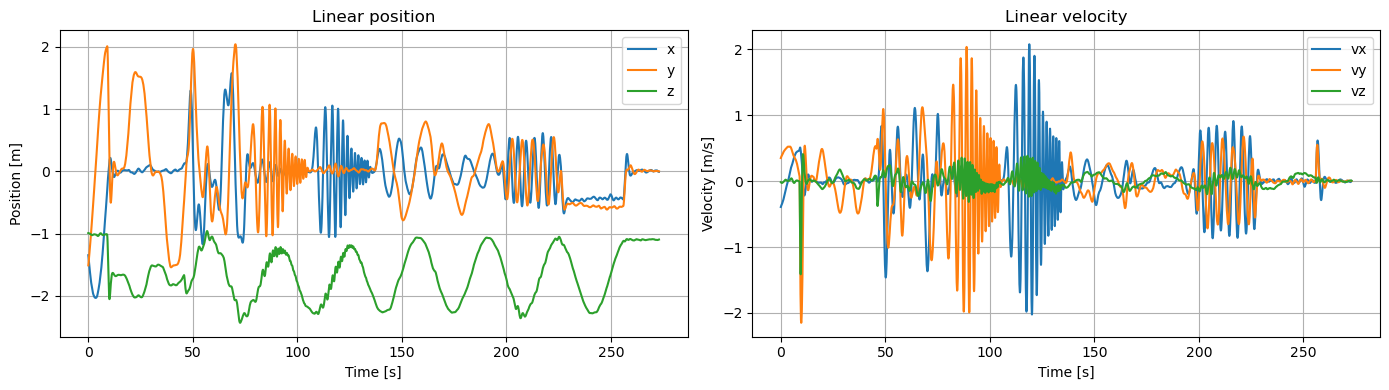

In [46]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load dataset
DATASET_PATH = os.path.join("dataset", "dataset_original.csv")
dataset_df   = pd.read_csv(DATASET_PATH)
dataset_np   = dataset_df.to_numpy(dtype=np.float32)

# dataset_original.csv is already preprocessed by the cell above.
# The control channels are the real logged PX4 inputs: thrust + body-rate commands.
# Reconstructed torques are intentionally not used.
dataset_np = from_quaternion_to_euler(dataset_np)

# ----- Global normalisation statistics for model inputs -----
mean, std = get_mean_and_std(dataset_np)
vel_mean     = mean[3:6];   vel_std     = std[3:6]
ang_vel_mean = mean[6:9];   ang_vel_std = std[6:9]
ctrl_mean    = mean[15:19]; ctrl_std    = std[15:19]

# ----- Train / val / test split -----
dt_candidates = dataset_np[:, 1]
dt_nominal    = float(np.median(dt_candidates[dt_candidates > 0])) if np.any(dt_candidates > 0) else 0.01
data_test_segments, data_train_val = split_data(
    dataset_np, time_period=1, dt=dt_nominal, t0=30, t1=150, t2=220)

# Shuffle and split train / val
pairs_curr, pairs_next = create_and_shuffle_pairs(data_train_val)
split_idx = int(0.8 * len(pairs_curr))
split_idx = min(max(split_idx, 1), len(pairs_curr) - 1)

train_data_current, val_data_current = pairs_curr[:split_idx], pairs_curr[split_idx:]
train_data_next,    val_data_next    = pairs_next[:split_idx], pairs_next[split_idx:]

# IMPORTANT:
# With real logged controls, use the CURRENT control row for x[k] -> x[k+1].
# The earlier "next" alignment mostly compensated the synthetic-torque leakage.
USE_NEXT_CONTROLS = False

X_train, X_train_next, U_train, dt_train = configure_training_and_validation_data(
    train_data_current, train_data_next, use_next_controls=USE_NEXT_CONTROLS)
X_val, X_val_next, U_val, dt_val = configure_training_and_validation_data(
    val_data_current, val_data_next, use_next_controls=USE_NEXT_CONTROLS)

# Keep 12-state slice used by physics / loss
X_train_phys      = X_train[:, :12].float()
X_train_next_phys = X_train_next[:, :12].float()
X_val_phys        = X_val[:, :12].float()
X_val_next_phys   = X_val_next[:, :12].float()
U_train = U_train.float(); dt_train = dt_train.float()
U_val   = U_val.float();   dt_val   = dt_val.float()

# ------------------------------------------------------------------
# Fit the hidden PX4 body-rate loop directly from the train split.
# Model per axis:
#    w_dot = a * w + b * u_rate + c
# This is much more faithful than treating logged rate commands as torques
# or as already-in-rad/s desired rates with a guessed time constant.
# ------------------------------------------------------------------
eps = 1e-8
dt_fit = dt_train.view(-1, 1).clamp_min(1e-4)
w_curr = X_train_phys[:, 9:12]
w_next = X_train_next_phys[:, 9:12]
u_rate = U_train[:, 1:4]
wdot_fd = (w_next - w_curr) / dt_fit

rate_w_coef = []
rate_u_coef = []
rate_bias = []
for j in range(3):
    Phi = torch.stack([
        w_curr[:, j],
        u_rate[:, j],
        torch.ones_like(w_curr[:, j]),
    ], dim=1)
    sol = torch.linalg.lstsq(Phi, wdot_fd[:, j]).solution
    rate_w_coef.append(sol[0].item())
    rate_u_coef.append(sol[1].item())
    rate_bias.append(sol[2].item())

RATE_W_COEF = torch.tensor(rate_w_coef, dtype=torch.float32)
RATE_U_COEF = torch.tensor(rate_u_coef, dtype=torch.float32)
RATE_BIAS   = torch.tensor(rate_bias, dtype=torch.float32)

print("Fitted body-rate surrogate coefficients:")
print("RATE_W_COEF =", RATE_W_COEF.tolist())
print("RATE_U_COEF =", RATE_U_COEF.tolist())
print("RATE_BIAS   =", RATE_BIAS.tolist())

# ------------------------------------------------------------------
# Residual normalisation for the NN output.
# The model predicts NORMALISED derivative corrections:
#     delta_vw_n = (delta_vw - r_mean) / r_std
# where delta_vw is in physical derivative units [m/s^2, rad/s^2].
# ------------------------------------------------------------------
with torch.no_grad():
    xdot_train = system_dynamics(X_train_phys, U_train, mass=mass, inertia=torch.tensor(inertia), g=g)
    X_phys_next_train = X_train_phys + xdot_train * dt_train.view(-1, 1)
    target_delta_vw_train = (X_train_next_phys[:, 6:12] - X_phys_next_train[:, 6:12]) / dt_train.view(-1, 1).clamp_min(1e-4)
    r_mean = target_delta_vw_train.mean(dim=0)
    r_std  = target_delta_vw_train.std(dim=0).clamp_min(1e-4)

print("Residual derivative stats:")
print("r_mean =", r_mean.tolist())
print("r_std  =", r_std.tolist())

# ----- Quick dataset overview -----
time = dataset_np[:, 0]
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(time, dataset_np[:, 2], label="x")
ax[0].plot(time, dataset_np[:, 3], label="y")
ax[0].plot(time, dataset_np[:, 4], label="z")
ax[0].set_title("Linear position"); ax[0].set_xlabel("Time [s]")
ax[0].set_ylabel("Position [m]"); ax[0].legend(); ax[0].grid(True)
ax[1].plot(time, dataset_np[:, 5], label="vx")
ax[1].plot(time, dataset_np[:, 6], label="vy")
ax[1].plot(time, dataset_np[:, 7], label="vz")
ax[1].set_title("Linear velocity"); ax[1].set_xlabel("Time [s]")
ax[1].set_ylabel("Velocity [m/s]"); ax[1].legend(); ax[1].grid(True)
plt.tight_layout(); plt.show()


**Step 5: Data Loss**

In [8]:
import torch
import torch.nn as nn

_mse_loss = nn.MSELoss()

def compute_new_pos_angles(delta_vw, xk, uk, dt, mass, inertia, g):
    """
    Integrate one step with derivative corrections delta_vw in PHYSICAL units:
      delta_vw[:,0:3] = v_dot correction [m/s^2]
      delta_vw[:,3:6] = w_dot correction [rad/s^2]
    """
    if dt.ndim == 1:
        dt = dt.view(-1, 1)

    x_dot_phys = system_dynamics(xk, uk, mass, inertia=inertia, g=g)

    delta_v = delta_vw[:, 0:3]
    delta_w = delta_vw[:, 3:6]

    v_next = xk[:, 6:9] + (x_dot_phys[:, 6:9] + delta_v) * dt
    w_next = xk[:, 9:12] + (x_dot_phys[:, 9:12] + delta_w) * dt

    v_curr = xk[:, 6:9]
    pos_next = xk[:, 0:3] + 0.5 * (v_curr + v_next) * dt

    roll0  = xk[:, 3]
    pitch0 = xk[:, 4]
    yaw0   = xk[:, 5]

    q0 = euler_to_quat(roll0, pitch0, yaw0)
    dq = omega_to_quat_delta(0.5 * (xk[:, 9:12] + w_next), dt)
    q_next = quat_mul(q0, dq)
    q_next = quat_normalize(q_next)
    rpy_next = wrap_to_pi(quat_to_euler(q_next))

    X_next = torch.zeros_like(xk)
    X_next[:, 0:3]  = pos_next
    X_next[:, 3:6]  = rpy_next
    X_next[:, 6:9]  = v_next
    X_next[:, 9:12] = w_next
    return X_next


def denormalize_delta_vw(delta_vw_n):
    rm = r_mean.to(device=delta_vw_n.device, dtype=delta_vw_n.dtype).view(1, 6)
    rs = r_std.to(device=delta_vw_n.device, dtype=delta_vw_n.dtype).view(1, 6)
    return delta_vw_n * rs + rm


def data_loss(model, xk, U_curr_NN, X_next, dt,
              mass=2.0, inertia=torch.tensor([0.0217, 0.0217, 0.04]), g=9.81,
              channel_weights=None, lambda_corr=0.0):
    """
    Train the NN on NORMALISED derivative residuals using RAW physical x and u.
    The model normalises its inputs internally, so do NOT pre-normalise here.
    """
    if dt.ndim == 1:
        dt = dt.view(-1, 1)

    zero_delta_vw = torch.zeros((xk.shape[0], 6), device=xk.device, dtype=xk.dtype)
    X_phys_next = compute_new_pos_angles(zero_delta_vw, xk, U_curr_NN, dt, mass, inertia, g)

    target_delta_vw = (X_next[:, 6:12] - X_phys_next[:, 6:12]) / dt.clamp_min(1e-4)
    rm = r_mean.to(device=xk.device, dtype=xk.dtype).view(1, 6)
    rs = r_std.to(device=xk.device, dtype=xk.dtype).view(1, 6)
    target_delta_vw_n = (target_delta_vw - rm) / rs

    delta_vw_n = model(xk, U_curr_NN)
    delta_vw = delta_vw_n * rs + rm

    error = delta_vw_n - target_delta_vw_n
    loss_data = torch.mean(error ** 2)
    per_channel_losses = torch.mean(error ** 2, dim=0)

    # regularise physical correction magnitude, not the normalised one
    loss_corr = torch.mean(delta_vw ** 2)

    total_loss = loss_data + lambda_corr * loss_corr
    return total_loss, {
        'loss_data': loss_data.detach(),
        'loss_corr': loss_corr.detach(),
        'per_channel': per_channel_losses.detach(),
    }


In [9]:
# Quick check: does uk or U_next give lower omega error with the fitted real-control model?

def sd_onestep(X_curr_phys, U_applied, dt, mass, inertia, g):
    if dt.ndim == 1:
        dt_ = dt.view(-1, 1)
    else:
        dt_ = dt
    xdot = system_dynamics(X_curr_phys, U_applied, mass, inertia, g)
    return X_curr_phys + xdot * dt_

U_val_curr = torch.tensor(np.array(val_data_current[:, 29:33], dtype=np.float32))
U_val_next = torch.tensor(np.array(val_data_next[:, 29:33], dtype=np.float32))

X_pred_using_Ucurr = sd_onestep(X_val_phys, U_val_curr, dt_val, mass, inertia, g)
X_pred_using_Unext = sd_onestep(X_val_phys, U_val_next, dt_val, mass, inertia, g)

err_curr = (X_pred_using_Ucurr[:, 9:12] - X_val_next_phys[:, 9:12]).abs().mean(dim=0)
err_next = (X_pred_using_Unext[:, 9:12] - X_val_next_phys[:, 9:12]).abs().mean(dim=0)

print("Mean |omega error| using U[k]:   ", err_curr.tolist())
print("Mean |omega error| using U[k+1]: ", err_next.tolist())


Mean |omega error| using U[k]:    [0.006672268733382225, 0.0067689074203372, 0.0007044880767352879]
Mean |omega error| using U[k+1]:  [0.007838514633476734, 0.009639150463044643, 0.0007189739844761789]


**Step 6: Training and Validation**

Training uses **one-step supervised learning on (current, next) state pairs only** — no windows, no horizons, and no multi-step rollout.

**Why pairs only?**  
Each training example is a single transition `(x_k, u_k) → x_{k+1}`: the model predicts the one-step residual correction and is penalised on the MSE between the predicted and true next state. This is the minimal, cleanest form of supervised physics-correcting learning.

**Preventing interlinking across trajectories:**  
The dataset is assembled by stacking multiple flight segments.  At each segment boundary the first row of the new segment has `dt = 0` (set by `dataset_masking`).  `create_and_shuffle_pairs` filters these rows out as "next" states before any shuffling, so no pair ever links the end of one trajectory to the start of another.

**Training loop:**
* Mini-batches of size `BATCH_SIZE` are drawn from the shuffled pair dataset.
* For each batch: forward pass → `data_loss` (MSE + L2 correction penalty) → `loss.backward()` → gradient clip → `optimizer.step()`.
* Validation uses the full held-out pair set (full-batch, no gradient).
* Early stopping monitors val loss; best checkpoint is restored at the end.


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import TensorDataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Hyper-parameters ──────────────────────────────────────────────────────────────
HIDDEN_LAYERS  = [16, 32, 16]   # smaller model → better generalisation try 32, 32, 32
DROPOUT_RATE   = 0.1            # dropout between hidden layers
LEARNING_RATE  = 1e-3
WEIGHT_DECAY   = 1e-4           # L2 weight regularisation (Adam)
BATCH_SIZE     = 512            # mini-batch size
GRAD_CLIP      = 1.0            # max gradient norm
NUM_EPOCHS     = 50000
LAMBDA_CORR    = 1           # L2 penalty on NN correction magnitude
EARLY_STOP_PAT = 3000           # patience epochs for early stopping
MIN_DELTA      = 1e-7           # minimum val-loss improvement to reset patience


Train pairs: 10799  |  Val pairs: 2700
Epoch 00050/50000 | train: 0.824883 | val: 0.687692 | best_val: 0.687692 | lr: 1.00e-03
Epoch 00100/50000 | train: 0.797190 | val: 0.663578 | best_val: 0.663578 | lr: 9.98e-04
Epoch 00150/50000 | train: 0.776703 | val: 0.641823 | best_val: 0.641418 | lr: 9.96e-04
Epoch 00200/50000 | train: 0.756616 | val: 0.622854 | best_val: 0.622653 | lr: 9.93e-04
Epoch 00250/50000 | train: 0.749563 | val: 0.612471 | best_val: 0.612460 | lr: 9.89e-04
Epoch 00300/50000 | train: 0.742221 | val: 0.609646 | best_val: 0.608770 | lr: 9.84e-04
Epoch 00350/50000 | train: 0.731153 | val: 0.606035 | best_val: 0.605251 | lr: 9.78e-04
Epoch 00400/50000 | train: 0.729838 | val: 0.602750 | best_val: 0.602719 | lr: 9.71e-04
Epoch 00450/50000 | train: 0.729251 | val: 0.603560 | best_val: 0.602486 | lr: 9.64e-04
Epoch 00500/50000 | train: 0.721562 | val: 0.604200 | best_val: 0.601393 | lr: 9.55e-04
Epoch 00550/50000 | train: 0.718486 | val: 0.598712 | best_val: 0.597694 | lr: 9.

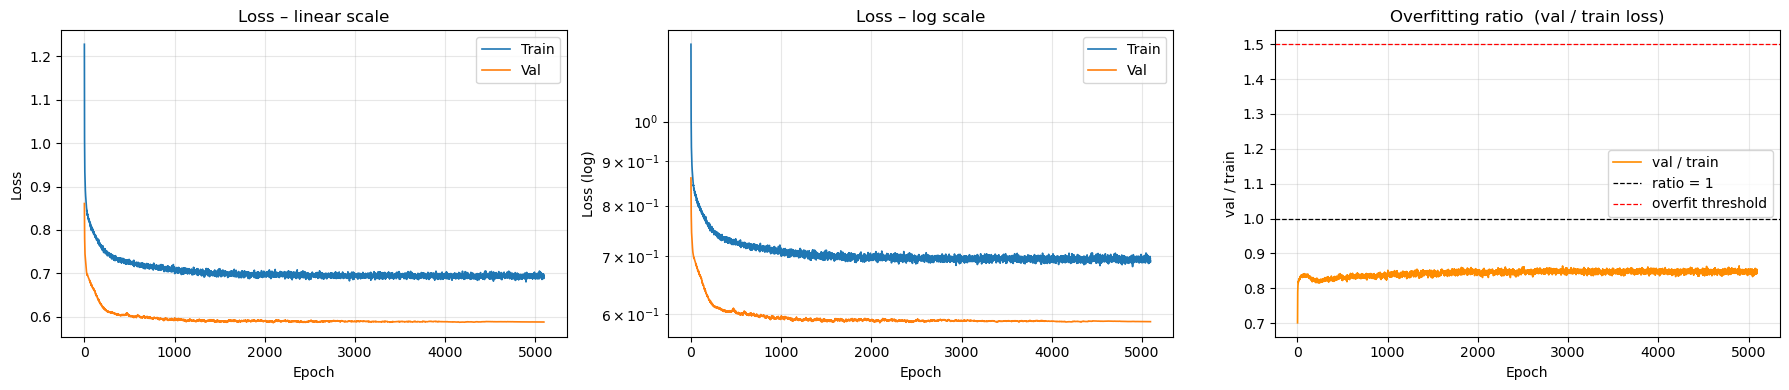

Best val loss at epoch 2094: 0.585738
Final  train / val: 0.690495 / 0.587525
Final  overfitting ratio: 0.851  (>1.5 suggests overfitting)


In [11]:
# Normalization
norm = DynamicsNormalizer(
    pos_scale=10.0,
    angle_scale=np.pi,
    vel_scale=5.0,
    omega_scale=5.0,
    u_scale=1.0
).to(device)
# ── Model ────────────────────────────────────────────────────────────────────────
model = ResidualBModel(
    hidden_layers_size=HIDDEN_LAYERS,
    activation_fn=nn.ELU,
    output_activation=nn.Identity,
    dropout_rate=DROPOUT_RATE,
    vel_mean=vel_mean,         vel_std=vel_std,
    ang_vel_mean=ang_vel_mean, ang_vel_std=ang_vel_std,
    ctrl_mean=ctrl_mean,       ctrl_std=ctrl_std,
).to(device)

# ── Optimizer ──────────────────────────────────────────────────────────────────
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# ── LR schedulers ─────────────────────────────────────────────────────────────
scheduler_cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=3500, eta_min=1e-4)
scheduler_plateau = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=300,
    threshold=1e-5, threshold_mode='abs', min_lr=1e-5)

# ── Move pair tensors to device ──────────────────────────────────────────────────────
# These tensors were built in Cell 9 from boundary-clean shuffled pairs.
X_train_phys_d      = X_train_phys.to(device)
X_train_next_phys_d = X_train_next_phys.to(device)
U_train_d           = U_train.to(device)
dt_train_d          = dt_train.to(device)

X_val_phys_d      = X_val_phys.to(device)
X_val_next_phys_d = X_val_next_phys.to(device)
U_val_d           = U_val.to(device)
dt_val_d          = dt_val.to(device)

# # ── Channel weights ──────────────────────────────────────────────────────────────
# channel_weights = torch.tensor(
#     [0.1, 0.1, 0.1,   # x, y, z
#      0.1, 0.1, 0.1,   # roll, pitch, yaw
#      1.0, 1.0, 1.0,   # vx, vy, vz
#      1.0, 1.0, 1.0],  # w_roll, w_pitch, w_yaw
#     device=device, dtype=X_train_phys_d.dtype)

# ── Pair DataLoader ─────────────────────────────────────────────────────────────
# Training uses only (current, next) pairs.  No windows or multi-step
# horizons are used.  Cross-trajectory boundary pairs were already removed
# by create_and_shuffle_pairs in Cell 9, so each pair is guaranteed to
# belong to a single continuous flight segment.
train_dataset = TensorDataset(X_train_phys_d, U_train_d,
                               X_train_next_phys_d, dt_train_d)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
print(f"Train pairs: {len(train_dataset)}  |  Val pairs: {X_val_phys_d.shape[0]}")

# ── Training state ──────────────────────────────────────────────────────────────
train_losses   = []
val_losses     = []
lr_history     = []
per_ch_train   = [[] for _ in range(6)]
per_ch_val     = [[] for _ in range(6)]

best_val_loss    = float('inf')
best_model_state = None
patience_counter = 0

mass_    = 2.0
inertia_ = torch.tensor([0.0217, 0.0217, 0.04])
g_       = 9.81

# ── Training loop (pair-based) ───────────────────────────────────────────────────
for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_train_loss = 0.0
    epoch_ch_train   = torch.zeros(6)
    epoch_train_loss = 0.0

    for X_b, U_b, Xn_b, dt_b in train_loader:
        optimizer.zero_grad()

        loss_b, extras_b = data_loss(
            model=model,
            xk=X_b, U_curr_NN=U_b, X_next=Xn_b, dt=dt_b,
            mass=mass_, inertia=inertia_, g=g_,
            lambda_corr=LAMBDA_CORR,
        )

        loss_b.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
        optimizer.step()

        epoch_train_loss += loss_b.item() * X_b.size(0)
        epoch_ch_train += extras_b['per_channel'].detach().cpu() * X_b.size(0)

    epoch_train_loss /= len(train_dataset)
    epoch_ch_train   /= len(train_dataset)

    # ── Validation (full batch, no gradient) ──────────────────────────────
    model.eval()
    with torch.no_grad():
        val_loss_t, extras_val = data_loss(
            model=model,
            xk=X_val_phys_d, U_curr_NN=U_val_d,
            X_next=X_val_next_phys_d, dt=dt_val_d,
            mass=mass_, inertia=inertia_, g=g_,
            lambda_corr=LAMBDA_CORR,
        )
    val_loss = float(val_loss_t.item())
    val_ch = extras_val['per_channel']

    # ── LR schedule ──────────────────────────────────────────────────────────
    if optimizer.param_groups[0]['lr'] > 1e-4:
        scheduler_cosine.step()
    else:
        scheduler_plateau.step(val_loss)

    train_losses.append(epoch_train_loss)
    val_losses.append(val_loss)
    lr_history.append(optimizer.param_groups[0]['lr'])
    for ch in range(6):
        per_ch_train[ch].append(epoch_ch_train[ch].item())
        per_ch_val[ch].append(val_ch[ch].item())

    # ── Early stopping ───────────────────────────────────────────────────────────
    if val_loss < best_val_loss - MIN_DELTA:
        best_val_loss    = val_loss
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PAT:
            print(f'Early stopping at epoch {epoch + 1}  '
                  f'(no improvement for {EARLY_STOP_PAT} epochs)')
            break

    if (epoch + 1) % 50 == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch+1:05d}/{NUM_EPOCHS} | train: {epoch_train_loss:.6f} '
              f'| val: {val_loss:.6f} | best_val: {best_val_loss:.6f} | lr: {lr:.2e}')

# ── Restore best checkpoint ──────────────────────────────────────────────────
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f'Restored best model (val loss: {best_val_loss:.6f})')
print('Training complete.')

# ── Training-curve plots ──────────────────────────────────────────────────────
_epochs   = np.arange(1, len(train_losses) + 1)
_train_np = np.array(train_losses)
_val_np   = np.array(val_losses)
_ratio    = _val_np / (_train_np + 1e-12)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(_epochs, _train_np, label='Train', lw=1.2)
axes[0].plot(_epochs, _val_np,   label='Val',   lw=1.2)
axes[0].set_title('Loss – linear scale')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].semilogy(_epochs, _train_np, label='Train', lw=1.2)
axes[1].semilogy(_epochs, _val_np,   label='Val',   lw=1.2)
_overfit_mask = _ratio > 1.5
if _overfit_mask.any():
    axes[1].fill_between(_epochs, _val_np.min() * 0.9, _val_np,
                         where=_overfit_mask, alpha=0.25, color='red',
                         label='val/train > 1.5')
axes[1].set_title('Loss – log scale')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss (log)')
axes[1].legend(); axes[1].grid(True, alpha=0.3, which='both')

axes[2].plot(_epochs, _ratio, color='darkorange', lw=1.2, label='val / train')
axes[2].axhline(1.0, color='k',   ls='--', lw=0.9, label='ratio = 1')
axes[2].axhline(1.5, color='red', ls='--', lw=0.9, label='overfit threshold')
axes[2].set_title('Overfitting ratio  (val / train loss)')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('val / train')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

_best_ep = int(np.argmin(_val_np)) + 1
print(f'Best val loss at epoch {_best_ep}: {_val_np[_best_ep-1]:.6f}')
print(f'Final  train / val: {_train_np[-1]:.6f} / {_val_np[-1]:.6f}')
print(f'Final  overfitting ratio: {_ratio[-1]:.3f}  (>1.5 suggests overfitting)')

trained_model = model

In [12]:
@torch.no_grad()
def _f_phys_nn(model, x, u, dt, mass, inertia, g, use_nn: bool):
    if dt.ndim == 1:
        dt = dt.view(-1, 1)
    elif dt.ndim == 0:
        dt = dt.view(1, 1)

    xdot = system_dynamics(x, u, mass, inertia, g)

    if not use_nn:
        return xdot

    delta_vw_n = model(x, u)
    delta_vw = denormalize_delta_vw(delta_vw_n)

    xdot_corr = torch.zeros_like(xdot)
    xdot_corr[:, 6:9]  = delta_vw[:, 0:3]
    xdot_corr[:, 9:12] = delta_vw[:, 3:6]

    return xdot + xdot_corr


@torch.no_grad()
def _rk4_step(model, x, u, dt, mass, inertia, g, use_nn: bool):
    if dt.ndim == 1:
        dt = dt.view(-1, 1)
    elif dt.ndim == 0:
        dt = dt.view(1, 1)

    k1 = _f_phys_nn(model, x,             u, dt, mass, inertia, g, use_nn)
    k2 = _f_phys_nn(model, x + 0.5*dt*k1, u, dt, mass, inertia, g, use_nn)
    k3 = _f_phys_nn(model, x + 0.5*dt*k2, u, dt, mass, inertia, g, use_nn)
    k4 = _f_phys_nn(model, x + 1.0*dt*k3, u, dt, mass, inertia, g, use_nn)

    return x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)


@torch.no_grad()
def _euler_step(model, x, u, dt, mass, inertia, g, use_nn: bool):
    if dt.ndim == 1:
        dt = dt.view(-1, 1)
    elif dt.ndim == 0:
        dt = dt.view(1, 1)

    if use_nn:
        delta_vw = denormalize_delta_vw(model(x, u))
    else:
        delta_vw = torch.zeros((x.shape[0], 6), device=x.device, dtype=x.dtype)

    return compute_new_pos_angles(delta_vw, x, u, dt, mass, inertia, g)


@torch.no_grad()
def multistep_rollout(model, X0, U_seq, dt_seq, mass, inertia, g,
                      use_nn=True, integrator='euler'):
    if dt_seq.ndim != 1:
        dt_seq = dt_seq.view(-1)

    dev = X0.device
    dtype = X0.dtype
    N_steps = U_seq.shape[0]

    X_hat = torch.zeros((N_steps + 1, 12), device=dev, dtype=dtype)
    X_hat[0] = X0

    x = X0.view(1, 12)
    integrator = integrator.lower()
    if integrator not in ('euler', 'rk4'):
        raise ValueError(f"integrator must be 'euler' or 'rk4', got {integrator}")

    for k in range(N_steps):
        u = U_seq[k].view(1, 4)
        dt = dt_seq[k].view(1, 1)

        if integrator == 'euler':
            x_next = _euler_step(model, x, u, dt, mass, inertia, g, use_nn)
        else:
            x_next = _rk4_step(model, x, u, dt, mass, inertia, g, use_nn)

        X_hat[k + 1] = x_next.view(12)
        x = x_next

    return X_hat


In [13]:
@torch.no_grad()
def rollout_multistep_all(model, X_true, U_true, dt_true,
                          mass=2.0, inertia=torch.tensor([0.0217, 0.0217, 0.04]), g=9.81,
                          horizon_sec=1.0):
    """Roll out up to horizon_sec seconds from X_true[0] using CURRENT controls."""
    device  = next(model.parameters()).device
    X_true  = X_true.to(device)
    U_true  = U_true.to(device)
    dt_true = dt_true.to(device).view(-1)

    cum = torch.cumsum(dt_true[1:], dim=0)
    K   = int((cum <= horizon_sec).sum().item()) + 1
    K   = max(1, min(K, X_true.shape[0] - 1))

    xk     = X_true[0:1]
    X_pred = [xk.squeeze(0)]
    X_ref  = [X_true[0]]

    for k in range(K):
        uk = U_true[k:k+1]
        dt = dt_true[k+1].view(1, 1)
        xk = rollout_step_residual6(model, xk, uk, dt, mass=mass, inertia=inertia, g=g)
        X_pred.append(xk.squeeze(0))
        X_ref.append(X_true[k + 1])

    return torch.stack(X_pred, dim=0), torch.stack(X_ref, dim=0)


In [14]:
import torch

@torch.no_grad()
def rollout_step_residual6(model, xk, uk, dt,
                           mass=2.0,
                           inertia=torch.tensor([0.0217, 0.0217, 0.04]),
                           g=9.81):
    if dt.ndim == 1:
        dt = dt.view(-1, 1)

    delta_vw = denormalize_delta_vw(model(xk, uk))
    x_next = compute_new_pos_angles(delta_vw, xk, uk, dt, mass, inertia, g)
    return x_next


In [15]:
@torch.no_grad()
def predict_onestep_over_segment(model, xk, uk, dt_curr, mass, inertia, g):
    if dt_curr.ndim == 1:
        dt_curr = dt_curr.view(-1, 1)
    return rollout_step_residual6(model, xk, uk, dt_curr, mass=mass, inertia=inertia, g=g)

@torch.no_grad()
def rollout_multistep_over_segment(model, X0, U, dt, mass, inertia, g):
    if dt.ndim == 1:
        dt = dt[:, None]
    dt = dt.to(X0.device)

    xk = X0
    preds = []
    for k in range(U.shape[0]):
        xk = rollout_step_residual6(model, xk, U[k:k+1], dt[k:k+1], mass=mass, inertia=inertia, g=g)
        preds.append(xk)
    return torch.cat(preds, dim=0)


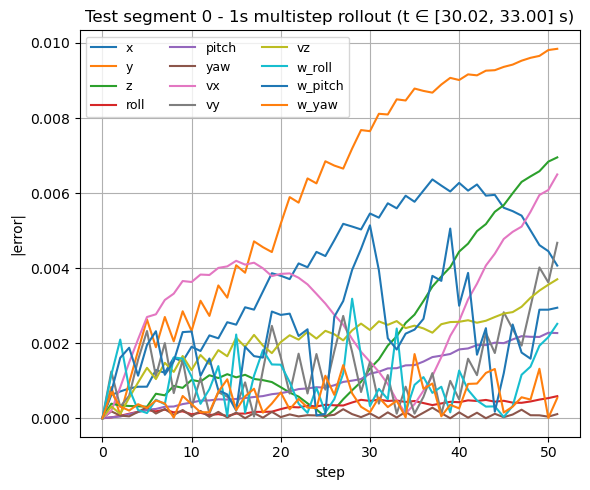

RMSE per channel:
      x: 0.004356
      y: 0.006775
      z: 0.003126
   roll: 0.000347
  pitch: 0.001265
    yaw: 0.000130
     vx: 0.003424
     vy: 0.001697
     vz: 0.002238
 w_roll: 0.001213
w_pitch: 0.002497
  w_yaw: 0.000658


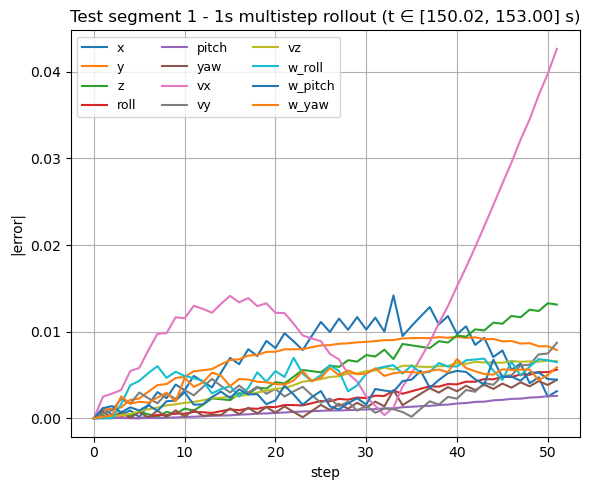

RMSE per channel:
      x: 0.007972
      y: 0.007521
      z: 0.007039
   roll: 0.002844
  pitch: 0.001256
    yaw: 0.002248
     vx: 0.016468
     vy: 0.003412
     vz: 0.004629
 w_roll: 0.005115
w_pitch: 0.003389
  w_yaw: 0.004625


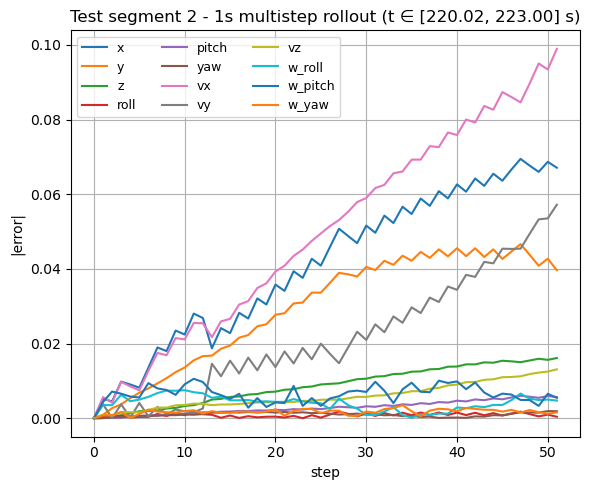

RMSE per channel:
      x: 0.045784
      y: 0.033087
      z: 0.010126
   roll: 0.000959
  pitch: 0.003345
    yaw: 0.001120
     vx: 0.057027
     vy: 0.026940
     vz: 0.006802
 w_roll: 0.004466
w_pitch: 0.006859
  w_yaw: 0.001875


In [39]:
import matplotlib.pyplot as plt
import torch

def plot_rollout_error(X_pred, X_ref, dt=None, title="3s multistep rollout error"):

    err = (X_pred - X_ref).detach().cpu()  # (K+1,12)

    channel_names = [
        "x", "y", "z",
        "roll", "pitch", "yaw",
        "vx", "vy", "vz",
        "w_roll", "w_pitch", "w_yaw",
    ]

    # x-axis
    if dt is None:
        t = torch.arange(err.shape[0])
        xlab = "step"
    else:
        dt = torch.as_tensor(dt).detach().cpu().view(-1)
        # If dt is length K (transitions), build K+1 timestamps
        if dt.numel() == err.shape[0] - 1:
            t = torch.cat([torch.zeros(1), torch.cumsum(dt, dim=0)])
        else:
            t = torch.cumsum(dt[:err.shape[0]], dim=0)
        xlab = "time [s]"

    plt.figure(figsize=(6, 5))
    for i in range(err.shape[1]):
        plt.plot(t.numpy(), err[:, i].abs().numpy(), label=channel_names[i])

    plt.title(title)
    plt.xlabel(xlab)
    plt.ylabel("|error|")
    plt.grid(True)
    plt.legend(ncol=3, fontsize=9)  # adjust columns/font as you like
    plt.tight_layout()
    plt.show()

    rmse = torch.sqrt(torch.mean(err**2, dim=0))
    print("RMSE per channel:")
    for name, val in zip(channel_names, rmse.numpy()):
        print(f"{name:>7s}: {val:.6f}")

for seg_i, seg in enumerate(data_test_segments):
    states, controls, dt_seg = configure_data(seg)

    X_true = torch.tensor(states[:, :12], dtype=torch.float32, device=device)
    U_true = torch.tensor(controls, dtype=torch.float32, device=device)
    dt_true = torch.tensor(dt_seg.squeeze(), dtype=torch.float32, device=device)

    # Your existing function (whatever it returns)
    X_pred, X_ref = rollout_multistep_all(model, X_true, U_true, dt_true)

    plot_rollout_error(
        X_pred, X_ref,
        title=f"Test segment {seg_i} - 1s multistep rollout (t ∈ [{float(seg[0,0]):.2f}, {float(seg[-1,0]):.2f}] s)"
    )

In [17]:
@torch.no_grad()
def predict_next_state_residual6(model, xk, uk, dt,
                                 mass=2.0,
                                 inertia=torch.tensor([0.0217, 0.0217, 0.04]),
                                 g=9.81):
    if dt.ndim == 1:
        dt = dt.view(-1, 1)
    delta_vw = denormalize_delta_vw(model(xk, uk))
    X_next_pred = compute_new_pos_angles(delta_vw, xk, uk, dt, mass, inertia, g)
    return X_next_pred


In [18]:
def analyze_rollout(X_pred, X_true):
    err = X_pred - X_true

    pos_err = err[:, 0:3].norm(dim=1)
    vel_err = err[:, 6:9].norm(dim=1)
    omega_err = err[:, 9:12].norm(dim=1)

    print("Final position error:", pos_err[-1].item())
    print("Final velocity error:", vel_err[-1].item())
    print("Final omega error:", omega_err[-1].item())

    print("Mean omega error:", omega_err.mean().item())


# Training Diagnostics

The cells below help answer two key questions:

1. **Is the model overfitting?** — Compare one-step predictions on a *training* segment vs a *test* segment.  If training looks much better than test, the network has memorised the training distribution.
2. **Which output dimensions are hardest to learn?** — Per-channel loss curves show whether some velocity / angular-rate components converge more slowly or diverge on validation while continuing to improve on training.


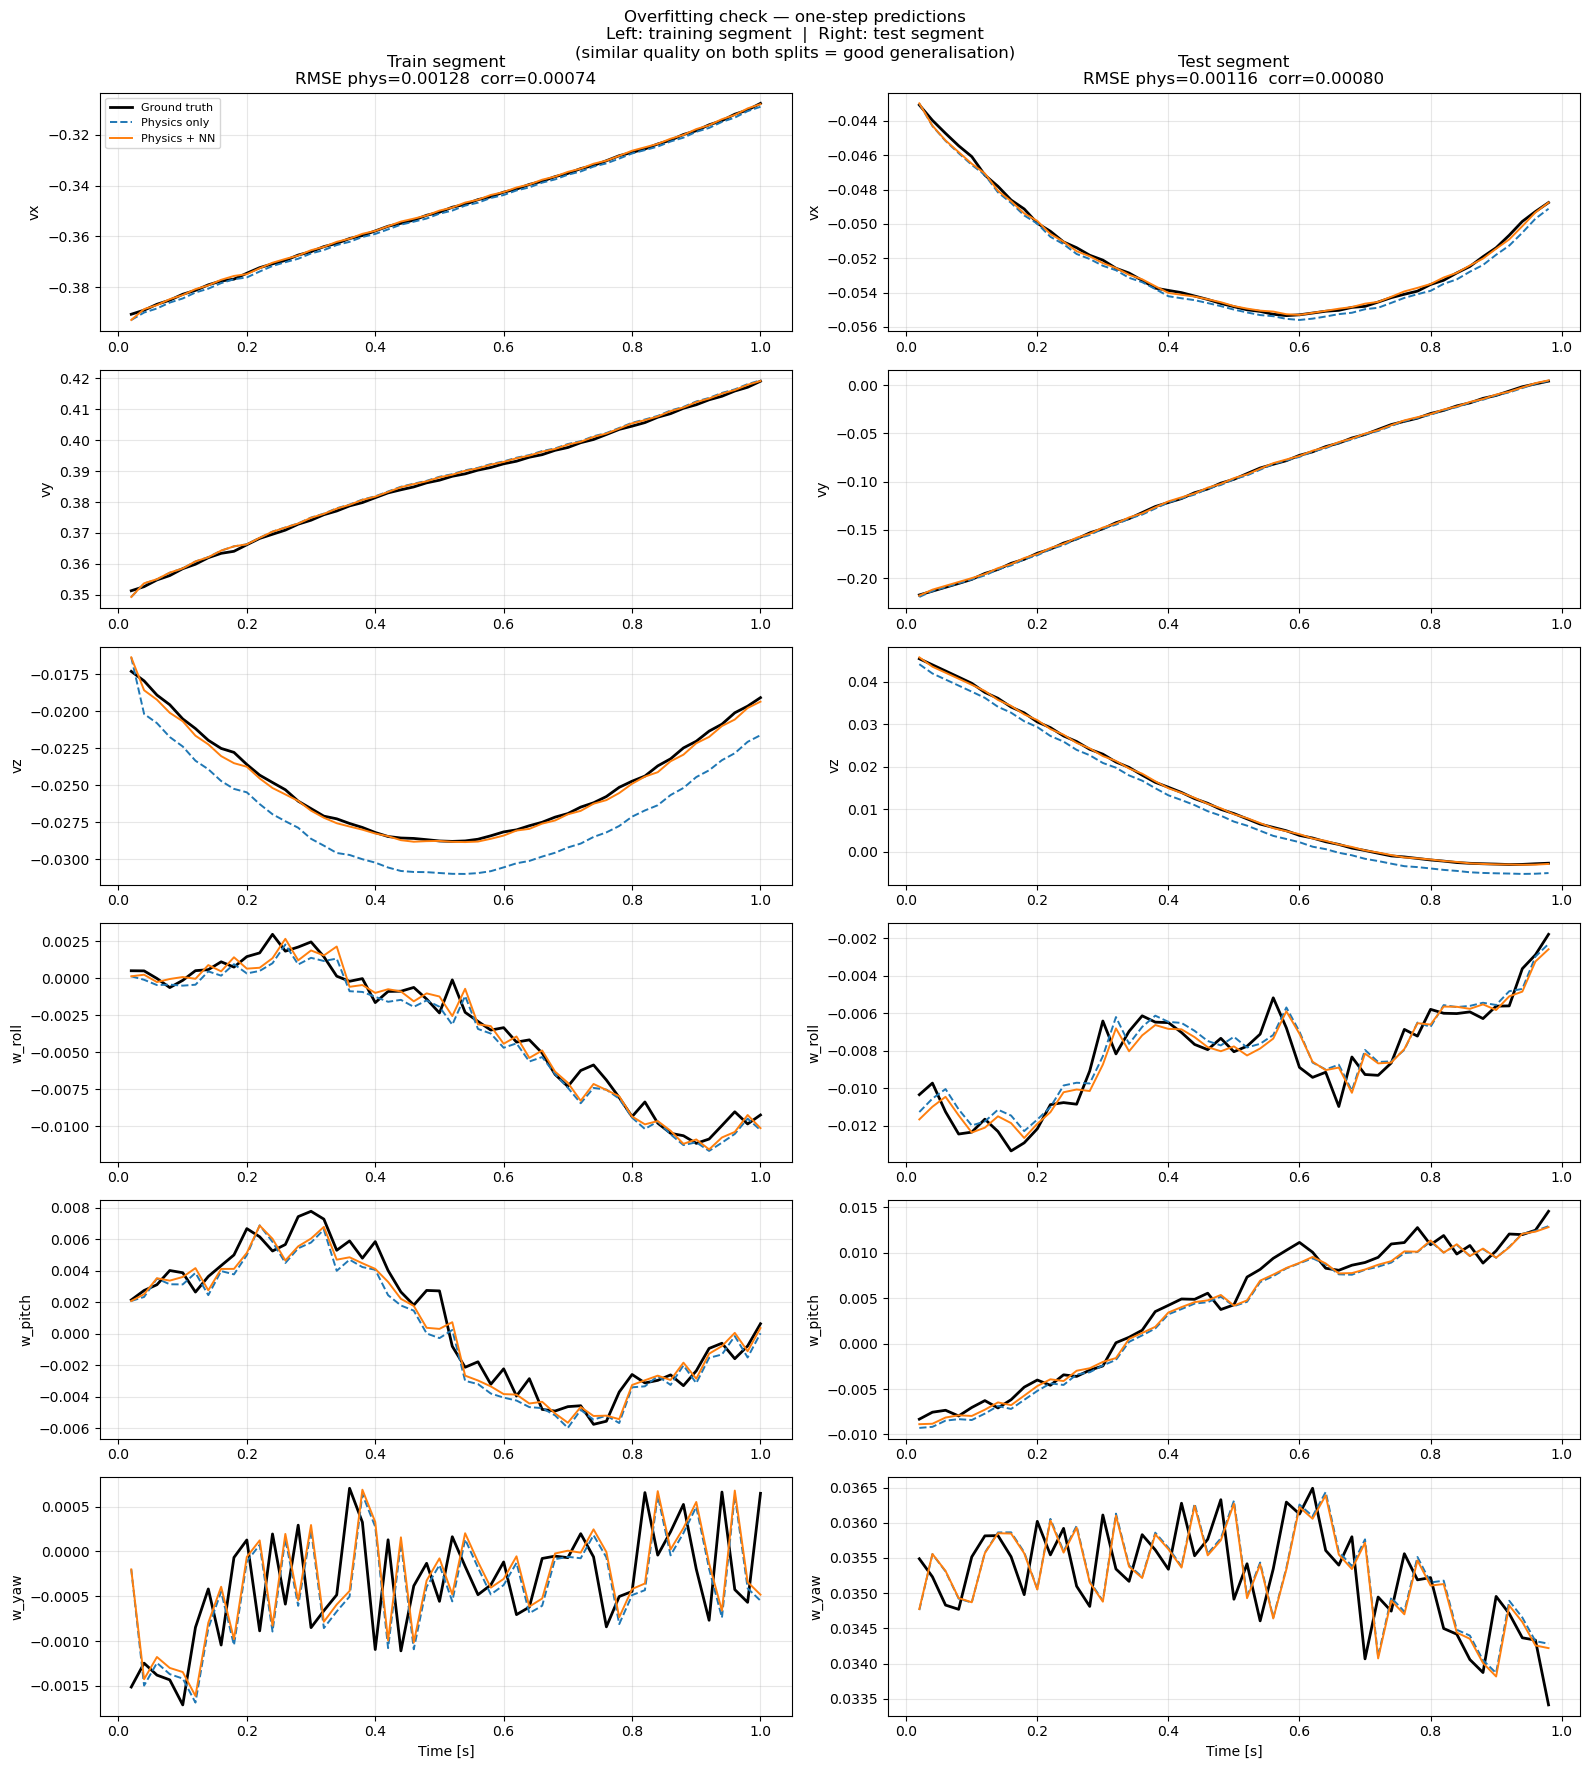

In [19]:
# ── Overfitting check: one-step predictions on training vs test segment ──
# A healthy model should show similar prediction quality on both splits.
# If the training segment is predicted almost perfectly while the test
# segment has large errors, the network is overfitting.

#Change it to multistep instead of onestep and also do validation.

import torch, numpy as np, matplotlib.pyplot as plt

model = trained_model.to(device)
model.eval()

_VW_NAMES = ["vx", "vy", "vz", "w_roll", "w_pitch", "w_yaw"]

def _one_step_segment(seg_np):
    """Return (t_rel, gt, phys, corr) arrays (N-1, 12) for a data segment."""
    states_np, controls_np, dt_np = configure_data(seg_np)
    X  = torch.tensor(states_np[:, :12], dtype=torch.float32, device=device)
    U  = torch.tensor(controls_np,       dtype=torch.float32, device=device)
    dt = torch.tensor(dt_np.squeeze(-1), dtype=torch.float32, device=device)
    xk = X[:-1]; uk = U[1:]; dt_curr = dt[:-1].view(-1, 1)  # U[1:] = next control, consistent with use_next_controls=True
    with torch.no_grad():
        xdot   = system_dynamics(xk, uk, mass=mass, inertia=inertia, g=g)
        X_phys = xk + xdot * dt_curr
        X_corr = predict_onestep_over_segment(model, xk, uk, dt_curr, mass, inertia, g)
    t_rel = seg_np[1:, 0] - seg_np[0, 0]
    return t_rel, X[1:].cpu().numpy(), X_phys.cpu().numpy(), X_corr.cpu().numpy()

# --- build a representative training segment (first ~1 s of train/val block) ---
DIAGNOSTIC_SEGMENT_DURATION = 1.0  # seconds of flight used for the overfitting check
seg_train = data_train_val[:int(DIAGNOSTIC_SEGMENT_DURATION / dt_nominal) + 1, :]
seg_test  = data_test_segments[0]

fig, axes = plt.subplots(6, 2, figsize=(16, 3 * 6), sharex=False)
fig.suptitle(
    "Overfitting check — one-step predictions\n"
    "Left: training segment  |  Right: test segment\n"
    "(similar quality on both splits = good generalisation)",
    fontsize=12)

for col, (seg, label) in enumerate([(seg_train, "Train segment"),
                                     (seg_test,  "Test segment")]):
    if seg.shape[0] < 3:
        continue
    t, gt, phys, corr = _one_step_segment(seg)
    rmse_phys = float(np.sqrt(np.mean((phys[:, 6:12] - gt[:, 6:12])**2)))
    rmse_corr = float(np.sqrt(np.mean((corr[:, 6:12] - gt[:, 6:12])**2)))
    for row, name in enumerate(_VW_NAMES):
        ax = axes[row, col]
        ax.plot(t, gt[:,   6 + row], "k-",   lw=2,   label="Ground truth")
        ax.plot(t, phys[:, 6 + row], "C0--", lw=1.4, label="Physics only")
        ax.plot(t, corr[:, 6 + row], "C1-",  lw=1.4, label="Physics + NN")
        ax.set_ylabel(name); ax.grid(True, alpha=0.3)
        if row == 0:
            ax.set_title(f"{label}\nRMSE phys={rmse_phys:.5f}  corr={rmse_corr:.5f}")
        if row == 5:
            ax.set_xlabel("Time [s]")
        if row == 0 and col == 0:
            ax.legend(fontsize=8)

plt.tight_layout(); plt.show()


In [20]:
import torch
import numpy as np


print("Using real logged controls [thrust, cmd_roll_rate, cmd_pitch_rate, cmd_yaw_rate]")
print("Rotational dynamics model: fitted affine surrogate w_dot = a*w + b*u_rate + c")

# ------------------------------------------------------------------
# Single source of truth for state / control / dt alignment.
#
# delay_mode='next' means the transition x[k] -> x[k+1] is driven by U[k+1]
# and dt[k+1]. This matches the shift you observed in angular velocities and
# the training setup that used use_next_controls=True.
# ------------------------------------------------------------------

def build_aligned_transitions(X, U, dt, delay_mode="curr"):
    """
    X : (N,12)
    U : (N,4)
    dt: (N,) or (N,1)

    Returns:
      xk      : (N-1,12)
      X_next  : (N-1,12)
      uk      : (N-1,4)
      dt_curr : (N-1,1)

    delay_mode='next': use U[k+1], dt[k+1] for transition x[k] -> x[k+1]
    delay_mode='curr': use U[k],   dt[k+1] for transition x[k] -> x[k+1]
    """
    if dt.ndim == 1:
        dt = dt.view(-1, 1)

    xk = X[:-1]
    X_next = X[1:]
    dt_curr = dt[1:]

    if delay_mode == "next":
        uk = U[1:]
    elif delay_mode == "curr":
        uk = U[:-1]
    else:
        raise ValueError(f"delay_mode must be 'next' or 'curr', got {delay_mode}")

    return xk, X_next, uk, dt_curr


@torch.no_grad()
def control_alignment_diagnostic(model, X, U, dt, mass, inertia, g):
    """
    Compare three choices for the control associated with x[k] -> x[k+1]:
      - U[k]
      - U[k+1]
      - 0.5 * (U[k] + U[k+1])

    This helps verify whether a delay / shift is present in the logged controls.
    """
    if dt.ndim == 1:
        dt = dt.view(-1, 1)

    xk = X[:-1]
    X_next = X[1:]
    dt_curr = dt[1:]

    U_curr = U[:-1]
    U_next = U[1:]
    U_mid = 0.5 * (U_curr + U_next)

    zero_delta_vw = torch.zeros((xk.shape[0], 6), device=xk.device, dtype=xk.dtype)

    # Physics-only predictions under three alignment choices
    pred_phys_curr = compute_new_pos_angles(zero_delta_vw, xk, U_curr, dt_curr, mass, inertia, g)
    pred_phys_next = compute_new_pos_angles(zero_delta_vw, xk, U_next, dt_curr, mass, inertia, g)
    pred_phys_mid = compute_new_pos_angles(zero_delta_vw, xk, U_mid, dt_curr, mass, inertia, g)

    # NN-corrected predictions under three alignment choices
    pred_nn_curr = compute_new_pos_angles(denormalize_delta_vw(model(xk, U_curr)), xk, U_curr, dt_curr, mass, inertia, g)
    pred_nn_next = compute_new_pos_angles(denormalize_delta_vw(model(xk, U_next)), xk, U_next, dt_curr, mass, inertia, g)
    pred_nn_mid = compute_new_pos_angles(denormalize_delta_vw(model(xk, U_mid)), xk, U_mid, dt_curr, mass, inertia, g)

    def rmse(pred):
        return torch.sqrt(torch.mean((pred - X_next) ** 2)).item()

    print("=== CONTROL ALIGNMENT DIAGNOSTIC ===")
    print(f"Physics, U[k]   RMSE: {rmse(pred_phys_curr):.6f}")
    print(f"Physics, U[k+1] RMSE: {rmse(pred_phys_next):.6f}")
    print(f"Physics, U[mid] RMSE: {rmse(pred_phys_mid):.6f}")
    print(f"NN,      U[k]   RMSE: {rmse(pred_nn_curr):.6f}")
    print(f"NN,      U[k+1] RMSE: {rmse(pred_nn_next):.6f}")
    print(f"NN,      U[mid] RMSE: {rmse(pred_nn_mid):.6f}")

    return {
        "phys_curr": rmse(pred_phys_curr),
        "phys_next": rmse(pred_phys_next),
        "phys_mid": rmse(pred_phys_mid),
        "nn_curr": rmse(pred_nn_curr),
        "nn_next": rmse(pred_nn_next),
        "nn_mid": rmse(pred_nn_mid),
    }


Using real logged controls [thrust, cmd_roll_rate, cmd_pitch_rate, cmd_yaw_rate]
Rotational dynamics model: fitted affine surrogate w_dot = a*w + b*u_rate + c


In [21]:
def combined_dynamics(model, x, u, mass, inertia, g):
    xdot = system_dynamics(x, u, mass, inertia, g)
    delta = denormalize_delta_vw(model(x, u))
    xdot[:, 6:9]  += delta[:, 0:3]
    xdot[:, 9:12] += delta[:, 3:6]
    return xdot


=== CONTROL ALIGNMENT DIAGNOSTIC ===
Physics, U[k]   RMSE: 0.000862
Physics, U[k+1] RMSE: 0.000845
Physics, U[mid] RMSE: 0.000853
NN,      U[k]   RMSE: 0.000608
NN,      U[k+1] RMSE: 0.000597
NN,      U[mid] RMSE: 0.000602
Segment 0
ω error physics: [0.0007996  0.00120121 0.00053618]
ω error NN: [0.00076928 0.00105569 0.00052752]
RMSE physics: 0.0008624169859103858
RMSE NN: 0.0006082401960156858


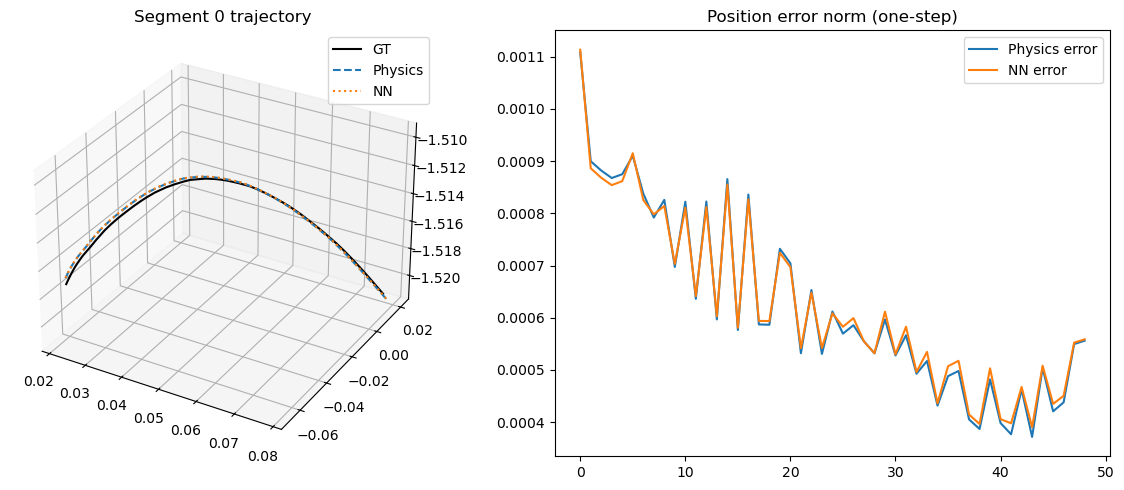

In [22]:
import numpy as np
import torch

mass = 2.0
inertia = torch.tensor([0.0217, 0.0217, 0.04], dtype=torch.float32, device=device)
g = 9.81

model = trained_model.to(device)
model.eval()


@torch.no_grad()
def compute_one_step_error(model, X, U, dt, mass, inertia, g, delay_mode="curr"):
    """
    Computes one-step prediction error with an explicit control-delay assumption.

    delay_mode='curr' is the default baseline alignment.
    """
    xk, X_next, uk, dt_curr = build_aligned_transitions(X, U, dt, delay_mode=delay_mode)

    # ---- physics prediction ----
    zero_delta_vw = torch.zeros((xk.shape[0], 6), device=xk.device, dtype=xk.dtype)
    X_pred_phys = compute_new_pos_angles(zero_delta_vw, xk, uk, dt_curr, mass, inertia, g)

    # ---- NN prediction ----
    delta_vw = denormalize_delta_vw(model(xk, uk))
    X_pred_nn = compute_new_pos_angles(delta_vw, xk, uk, dt_curr, mass, inertia, g)

    # ---- errors ----
    err_phys = (X_pred_phys - X_next).abs()
    err_nn   = (X_pred_nn   - X_next).abs()

    return err_phys, err_nn, X_pred_phys, X_pred_nn, X_next


# =========================================================
# MAIN LOOP
# =========================================================
for seg_i, seg in enumerate(data_test_segments):

    # ---- load data ----
    states_np, controls_np, dt_np = configure_data(seg)

    X = torch.tensor(states_np[:, :12], dtype=torch.float32, device=device)
    U = torch.tensor(controls_np, dtype=torch.float32, device=device)
    dt = torch.tensor(dt_np.squeeze(-1), dtype=torch.float32, device=device)

    control_alignment_diagnostic(model, X, U, dt, mass, inertia, g)

    # =====================================================
    # ONE-STEP DIAGNOSTIC
    # =====================================================
    err_phys, err_nn, X_phys, X_nn, X_gt = compute_one_step_error(
        model, X, U, dt, mass, inertia, g, delay_mode="curr"
    )

    omega_idx = slice(9, 12)

    print(f"Segment {seg_i}")
    print("ω error physics:", err_phys[:, omega_idx].mean(dim=0).cpu().numpy())
    print("ω error NN:", err_nn[:, omega_idx].mean(dim=0).cpu().numpy())
    print("RMSE physics:", torch.sqrt(((X_phys - X_gt) ** 2).mean()).item())
    print("RMSE NN:", torch.sqrt(((X_nn - X_gt) ** 2).mean()).item())

    # =====================================================
    # OPTIONAL: visualize trajectory sanity check
    # =====================================================
    t_next = seg[1:, 0] - seg[0, 0]

    phys_pos = X_phys[:, :3].cpu().numpy()
    nn_pos   = X_nn[:, :3].cpu().numpy()
    gt_pos   = X_gt[:, :3].cpu().numpy()

    import matplotlib.pyplot as plt

    fig = plt.figure(figsize=(12, 5))

    ax = fig.add_subplot(1, 2, 1, projection='3d')
    ax.plot(gt_pos[:,0], gt_pos[:,1], gt_pos[:,2], 'k', label='GT')
    ax.plot(phys_pos[:,0], phys_pos[:,1], phys_pos[:,2], '--', label='Physics')
    ax.plot(nn_pos[:,0], nn_pos[:,1], nn_pos[:,2], ':', label='NN')
    ax.set_title(f"Segment {seg_i} trajectory")
    ax.legend()

    ax2 = fig.add_subplot(1, 2, 2)
    ax2.plot(np.linalg.norm(phys_pos - gt_pos, axis=1), label="Physics error")
    ax2.plot(np.linalg.norm(nn_pos - gt_pos, axis=1), label="NN error")
    ax2.set_title("Position error norm (one-step)")
    ax2.legend()

    plt.tight_layout()
    plt.show()
    break


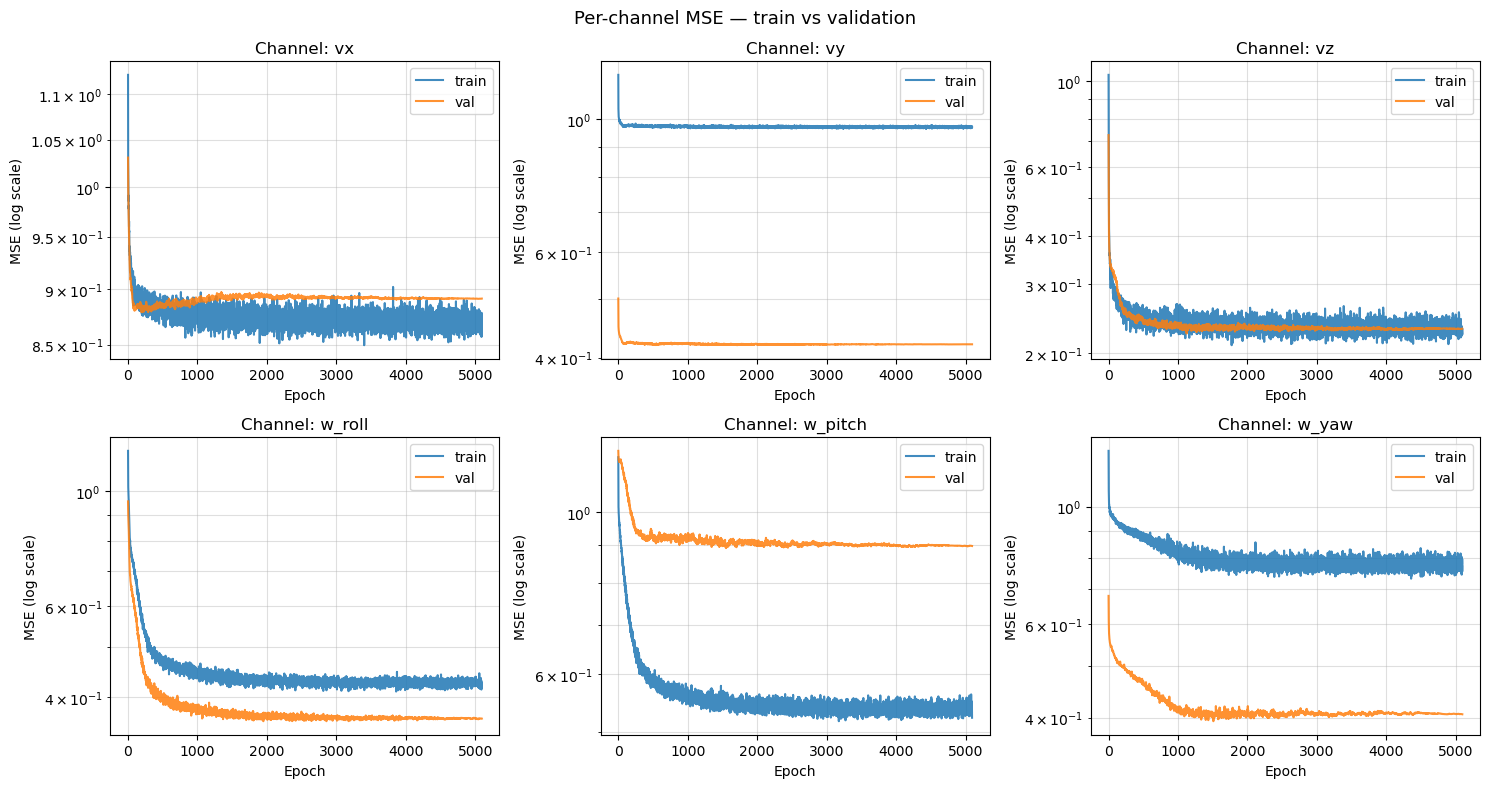

In [23]:
# ── Per-channel loss curves ──
# Each panel shows the MSE for one output dimension (vx … w_yaw).
# If train loss keeps falling while val loss rises or plateaus on a
# specific channel, that channel is the main source of overfitting.

import matplotlib.pyplot as plt

CH_NAMES  = ["vx", "vy", "vz", "w_roll", "w_pitch", "w_yaw"]
epochs_ran = len(per_ch_train[0])
ep = range(epochs_ran)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ch in range(6):
    ax = axes[ch]
    ax.semilogy(ep, per_ch_train[ch], label="train", alpha=0.85)
    ax.semilogy(ep, per_ch_val[ch],   label="val",   alpha=0.85)
    ax.set_title(f"Channel: {CH_NAMES[ch]}")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE (log scale)")
    ax.grid(True, which='both', alpha=0.4); ax.legend()

plt.suptitle("Per-channel MSE — train vs validation", fontsize=13)
plt.tight_layout(); plt.show()


# Plotting the results

### Patch notes
- real controls are treated with a fitted body-rate inner-loop surrogate, not as torques
- the NN is trained on normalized derivative residuals in physical units
- training now uses raw physical x/u as model inputs (the model normalizes internally)
- rollout uses current controls and RK4 by default for multistep


**Step 7: Testing**

# One step (euler, xavier, ELu)

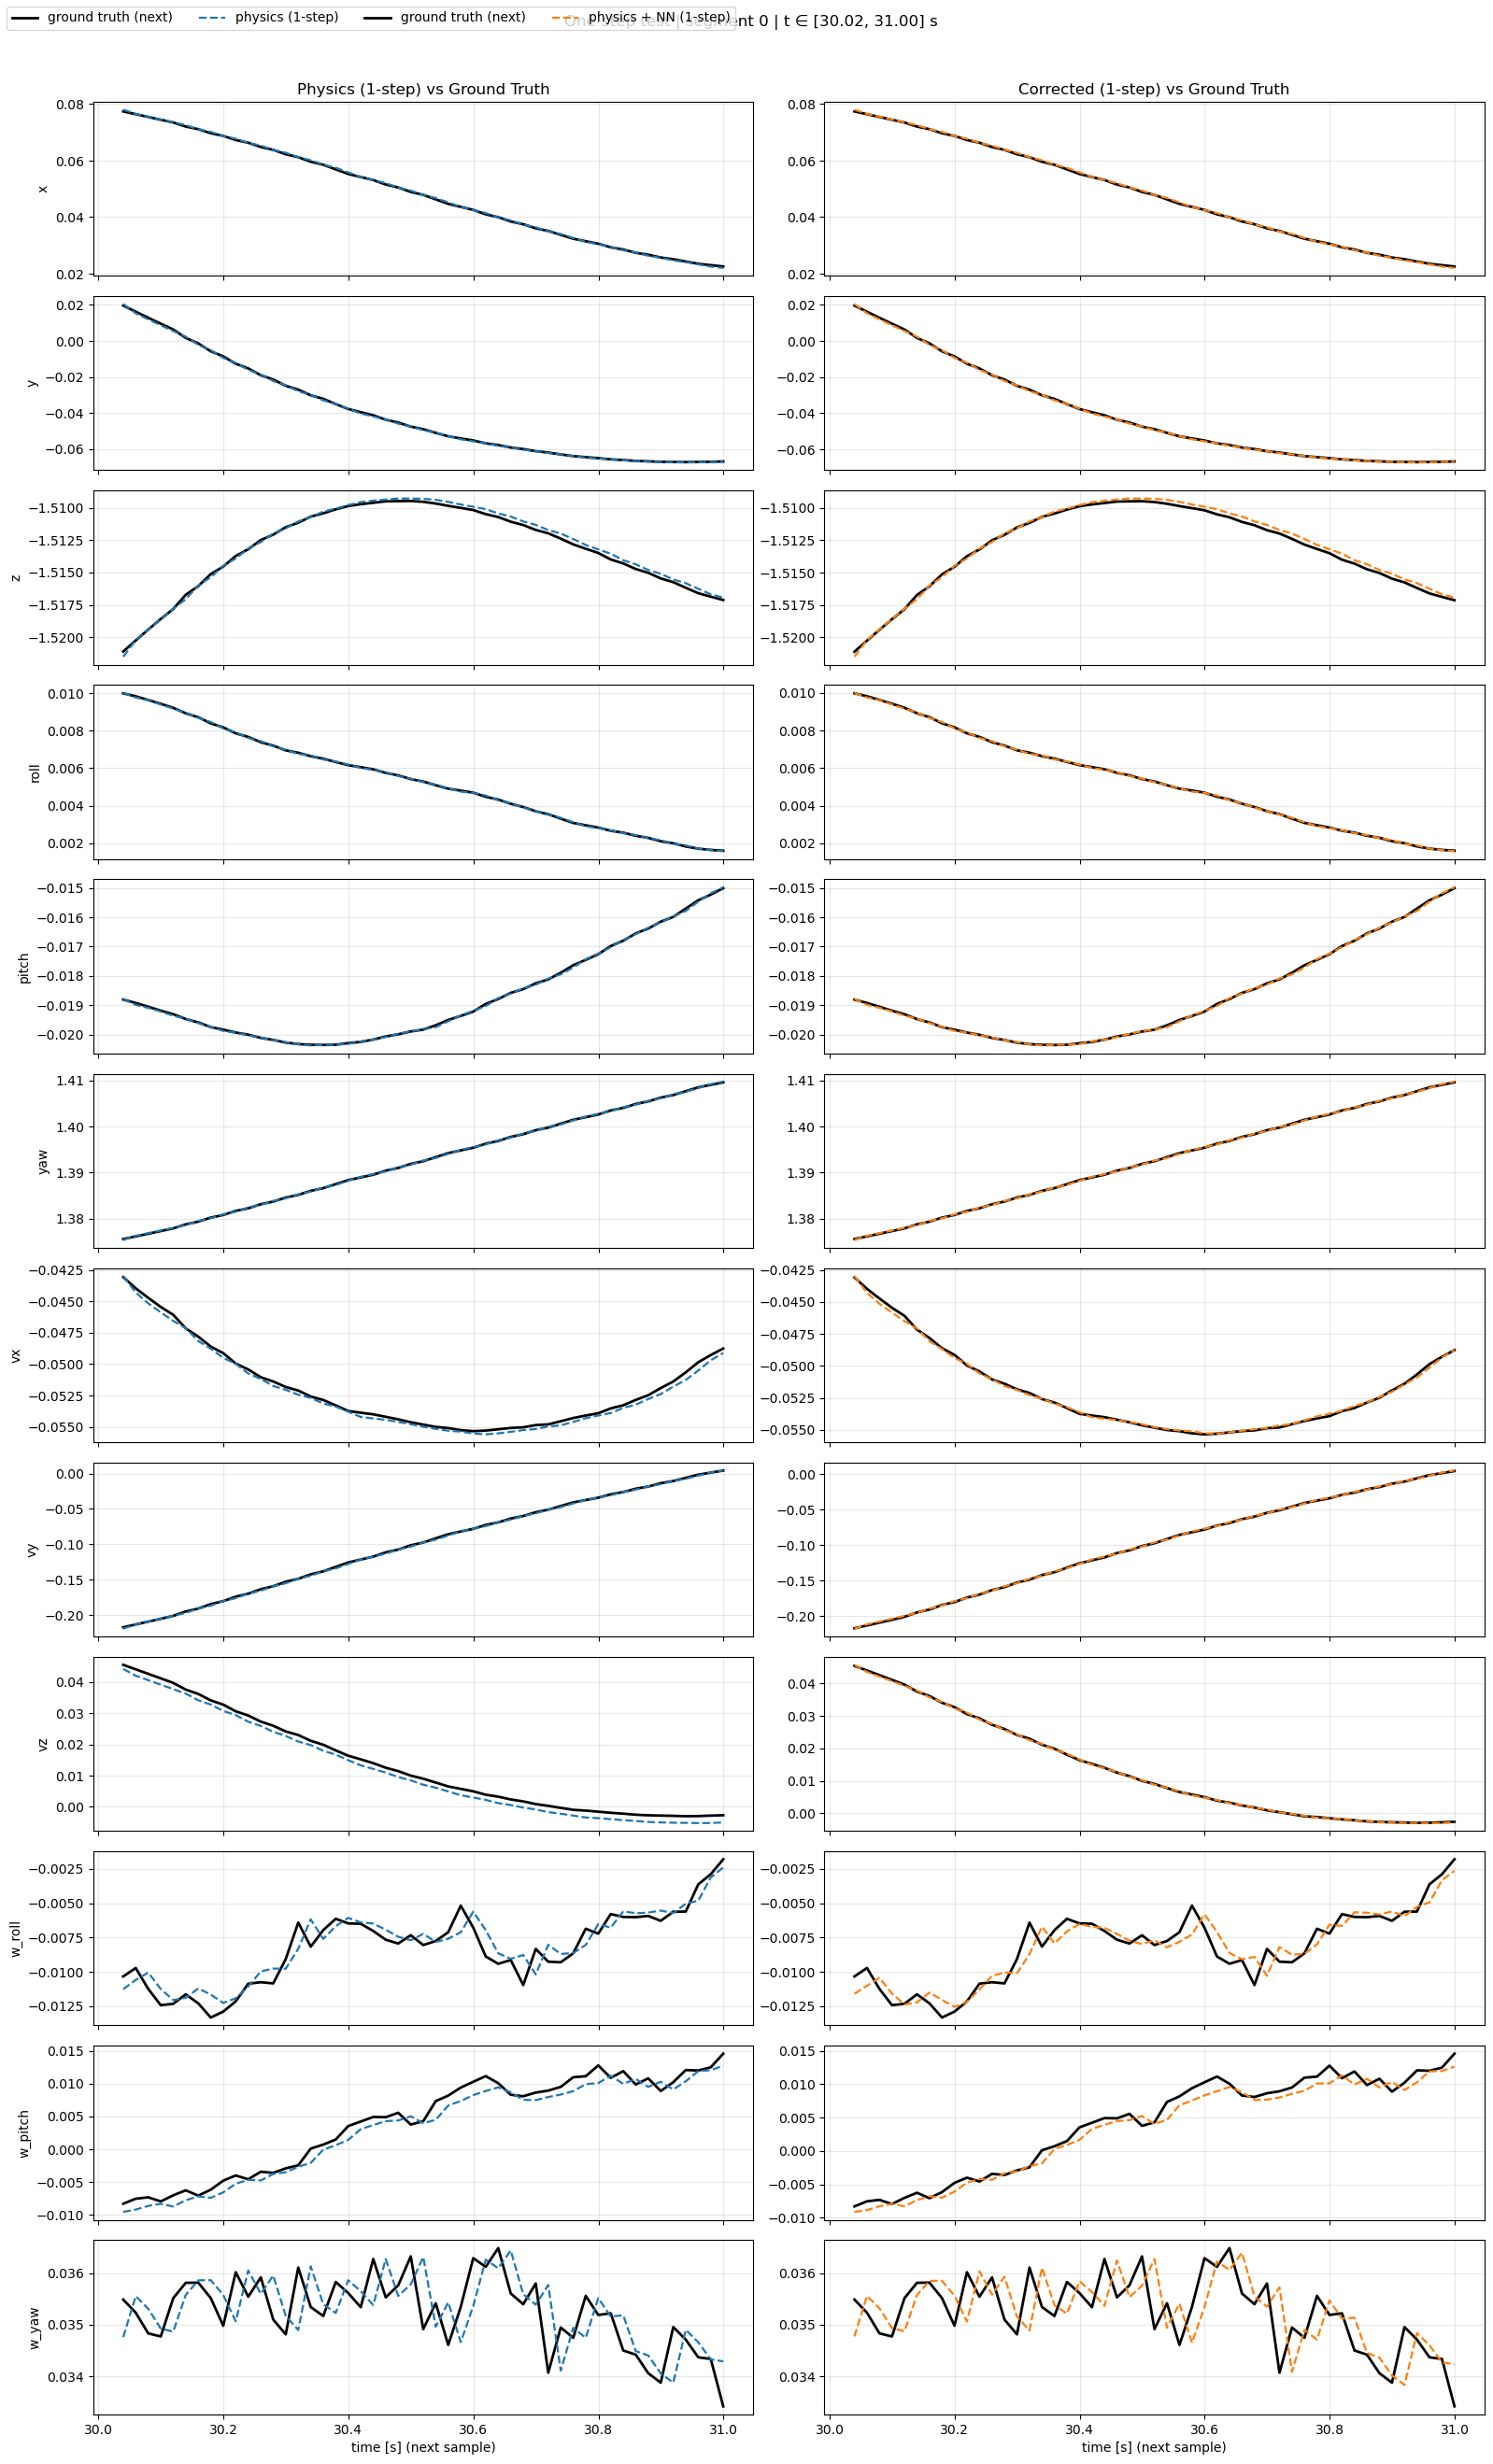

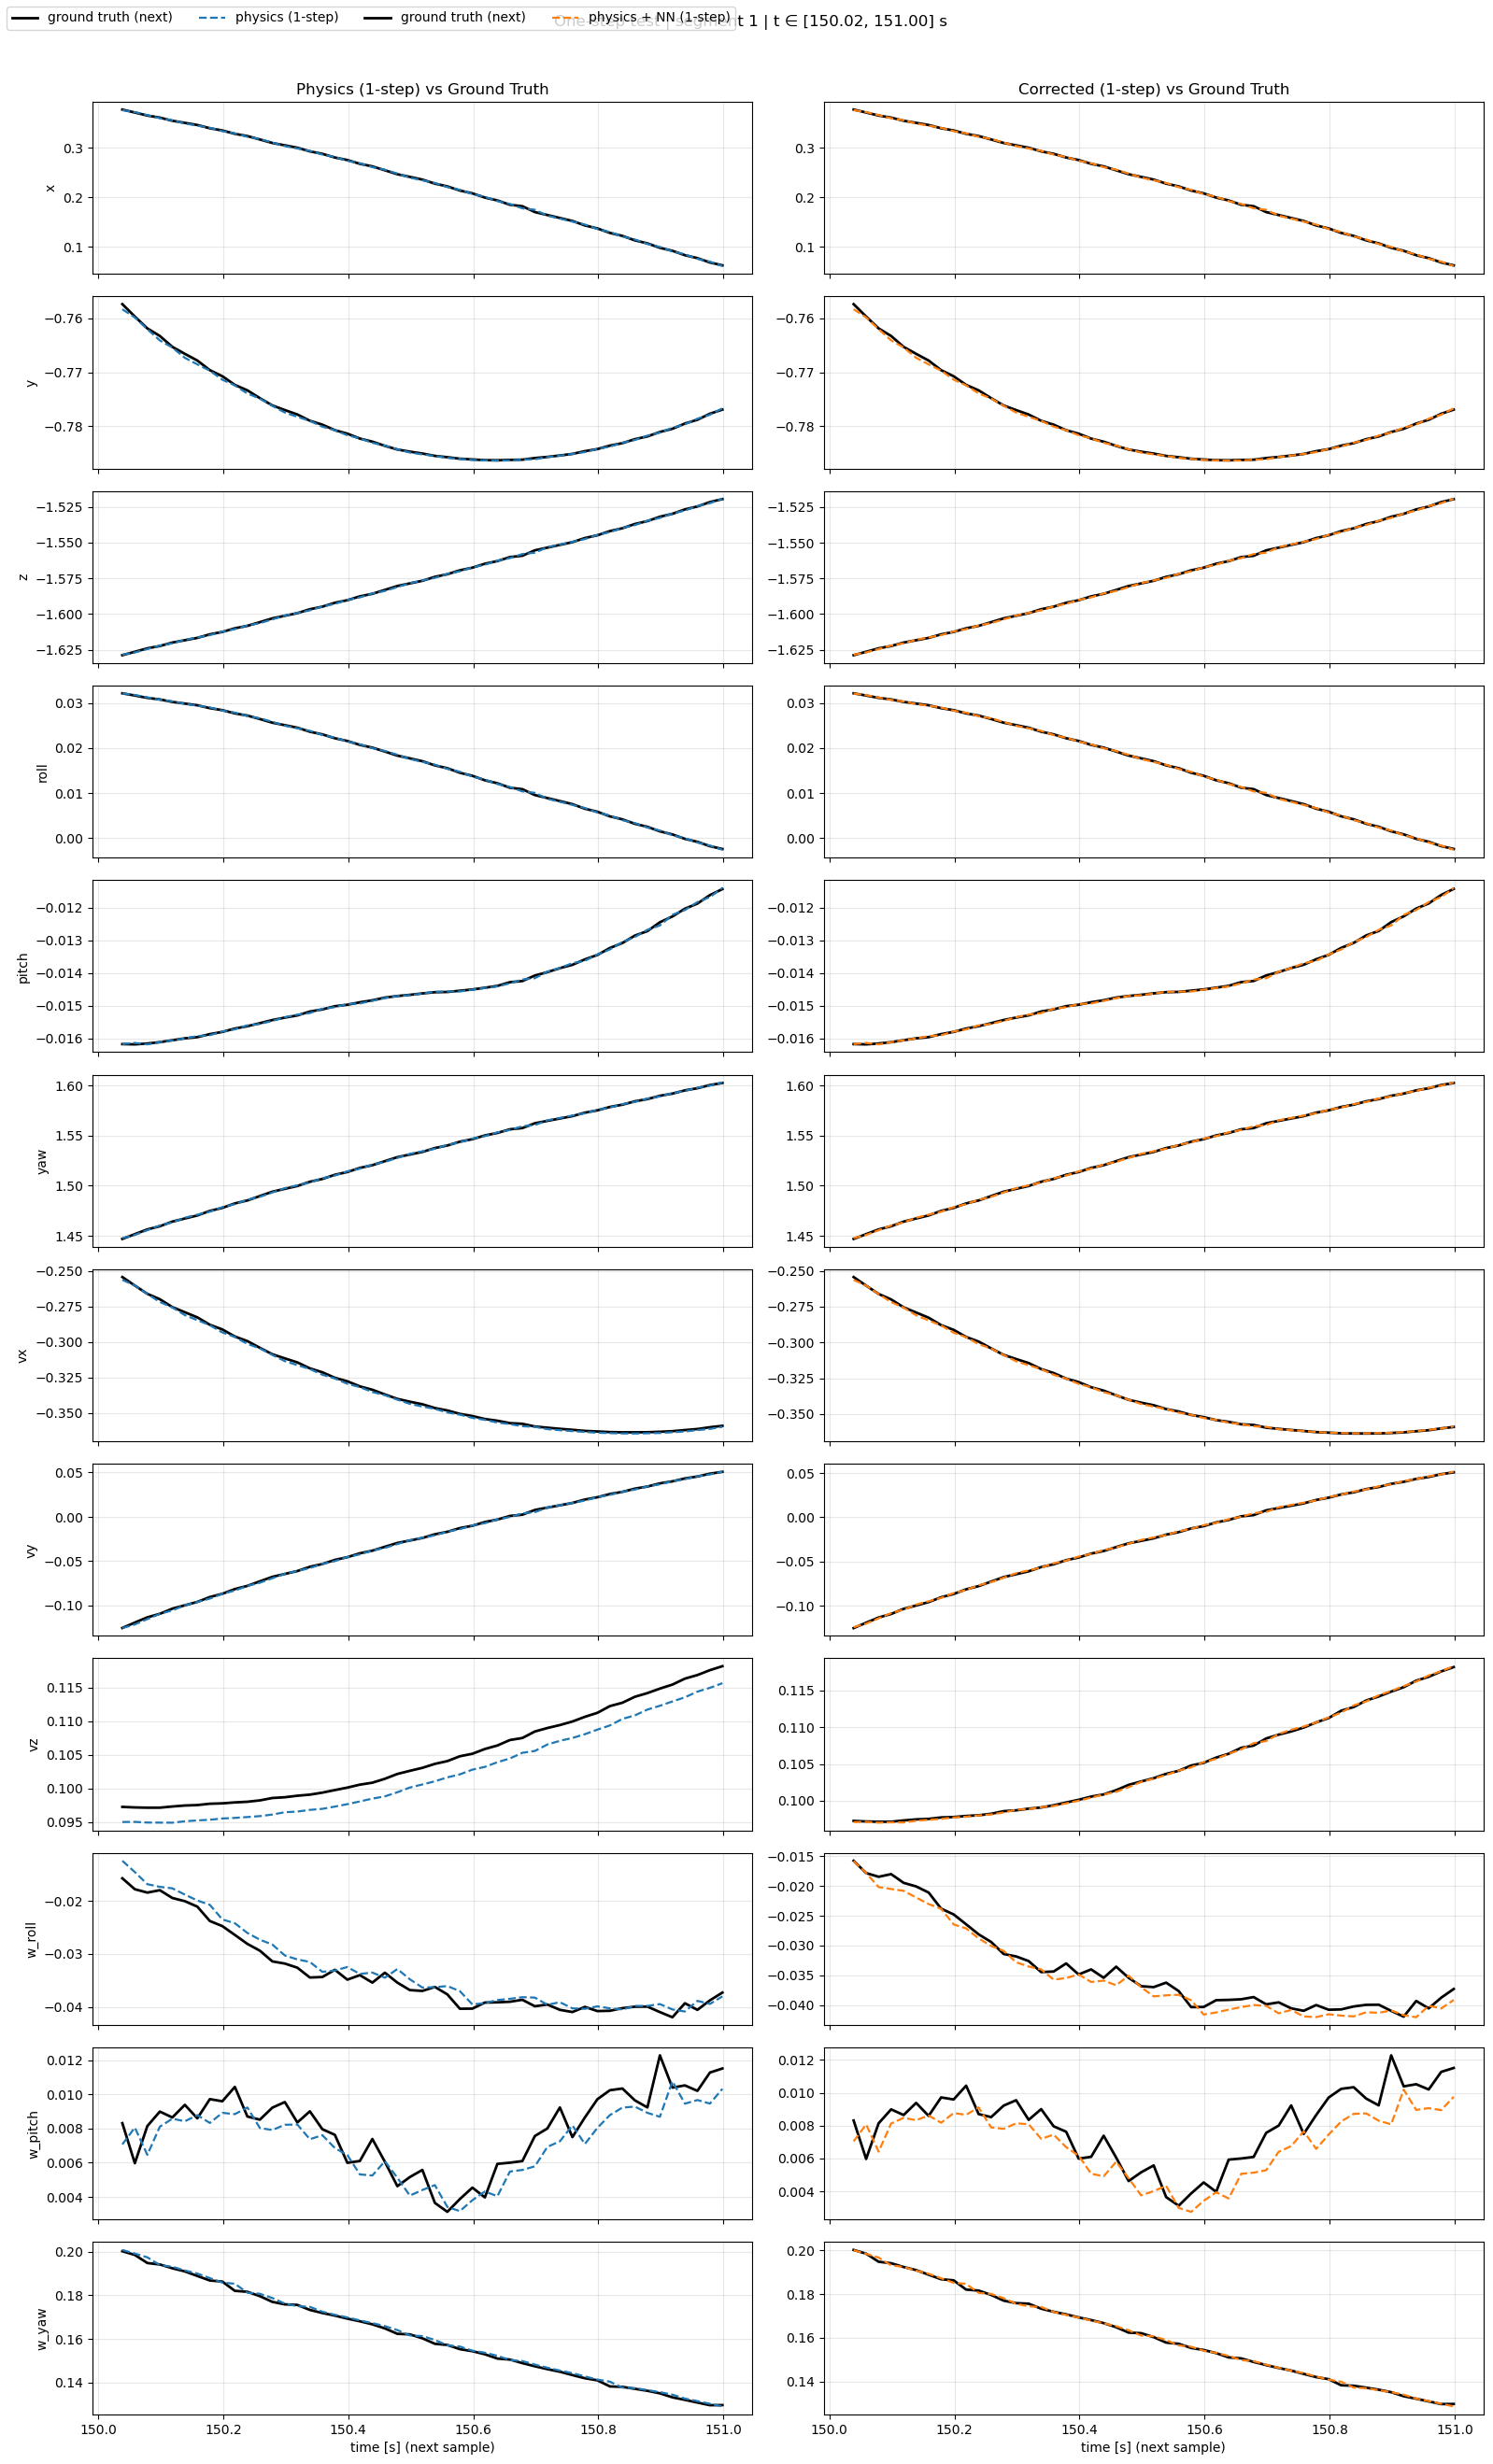

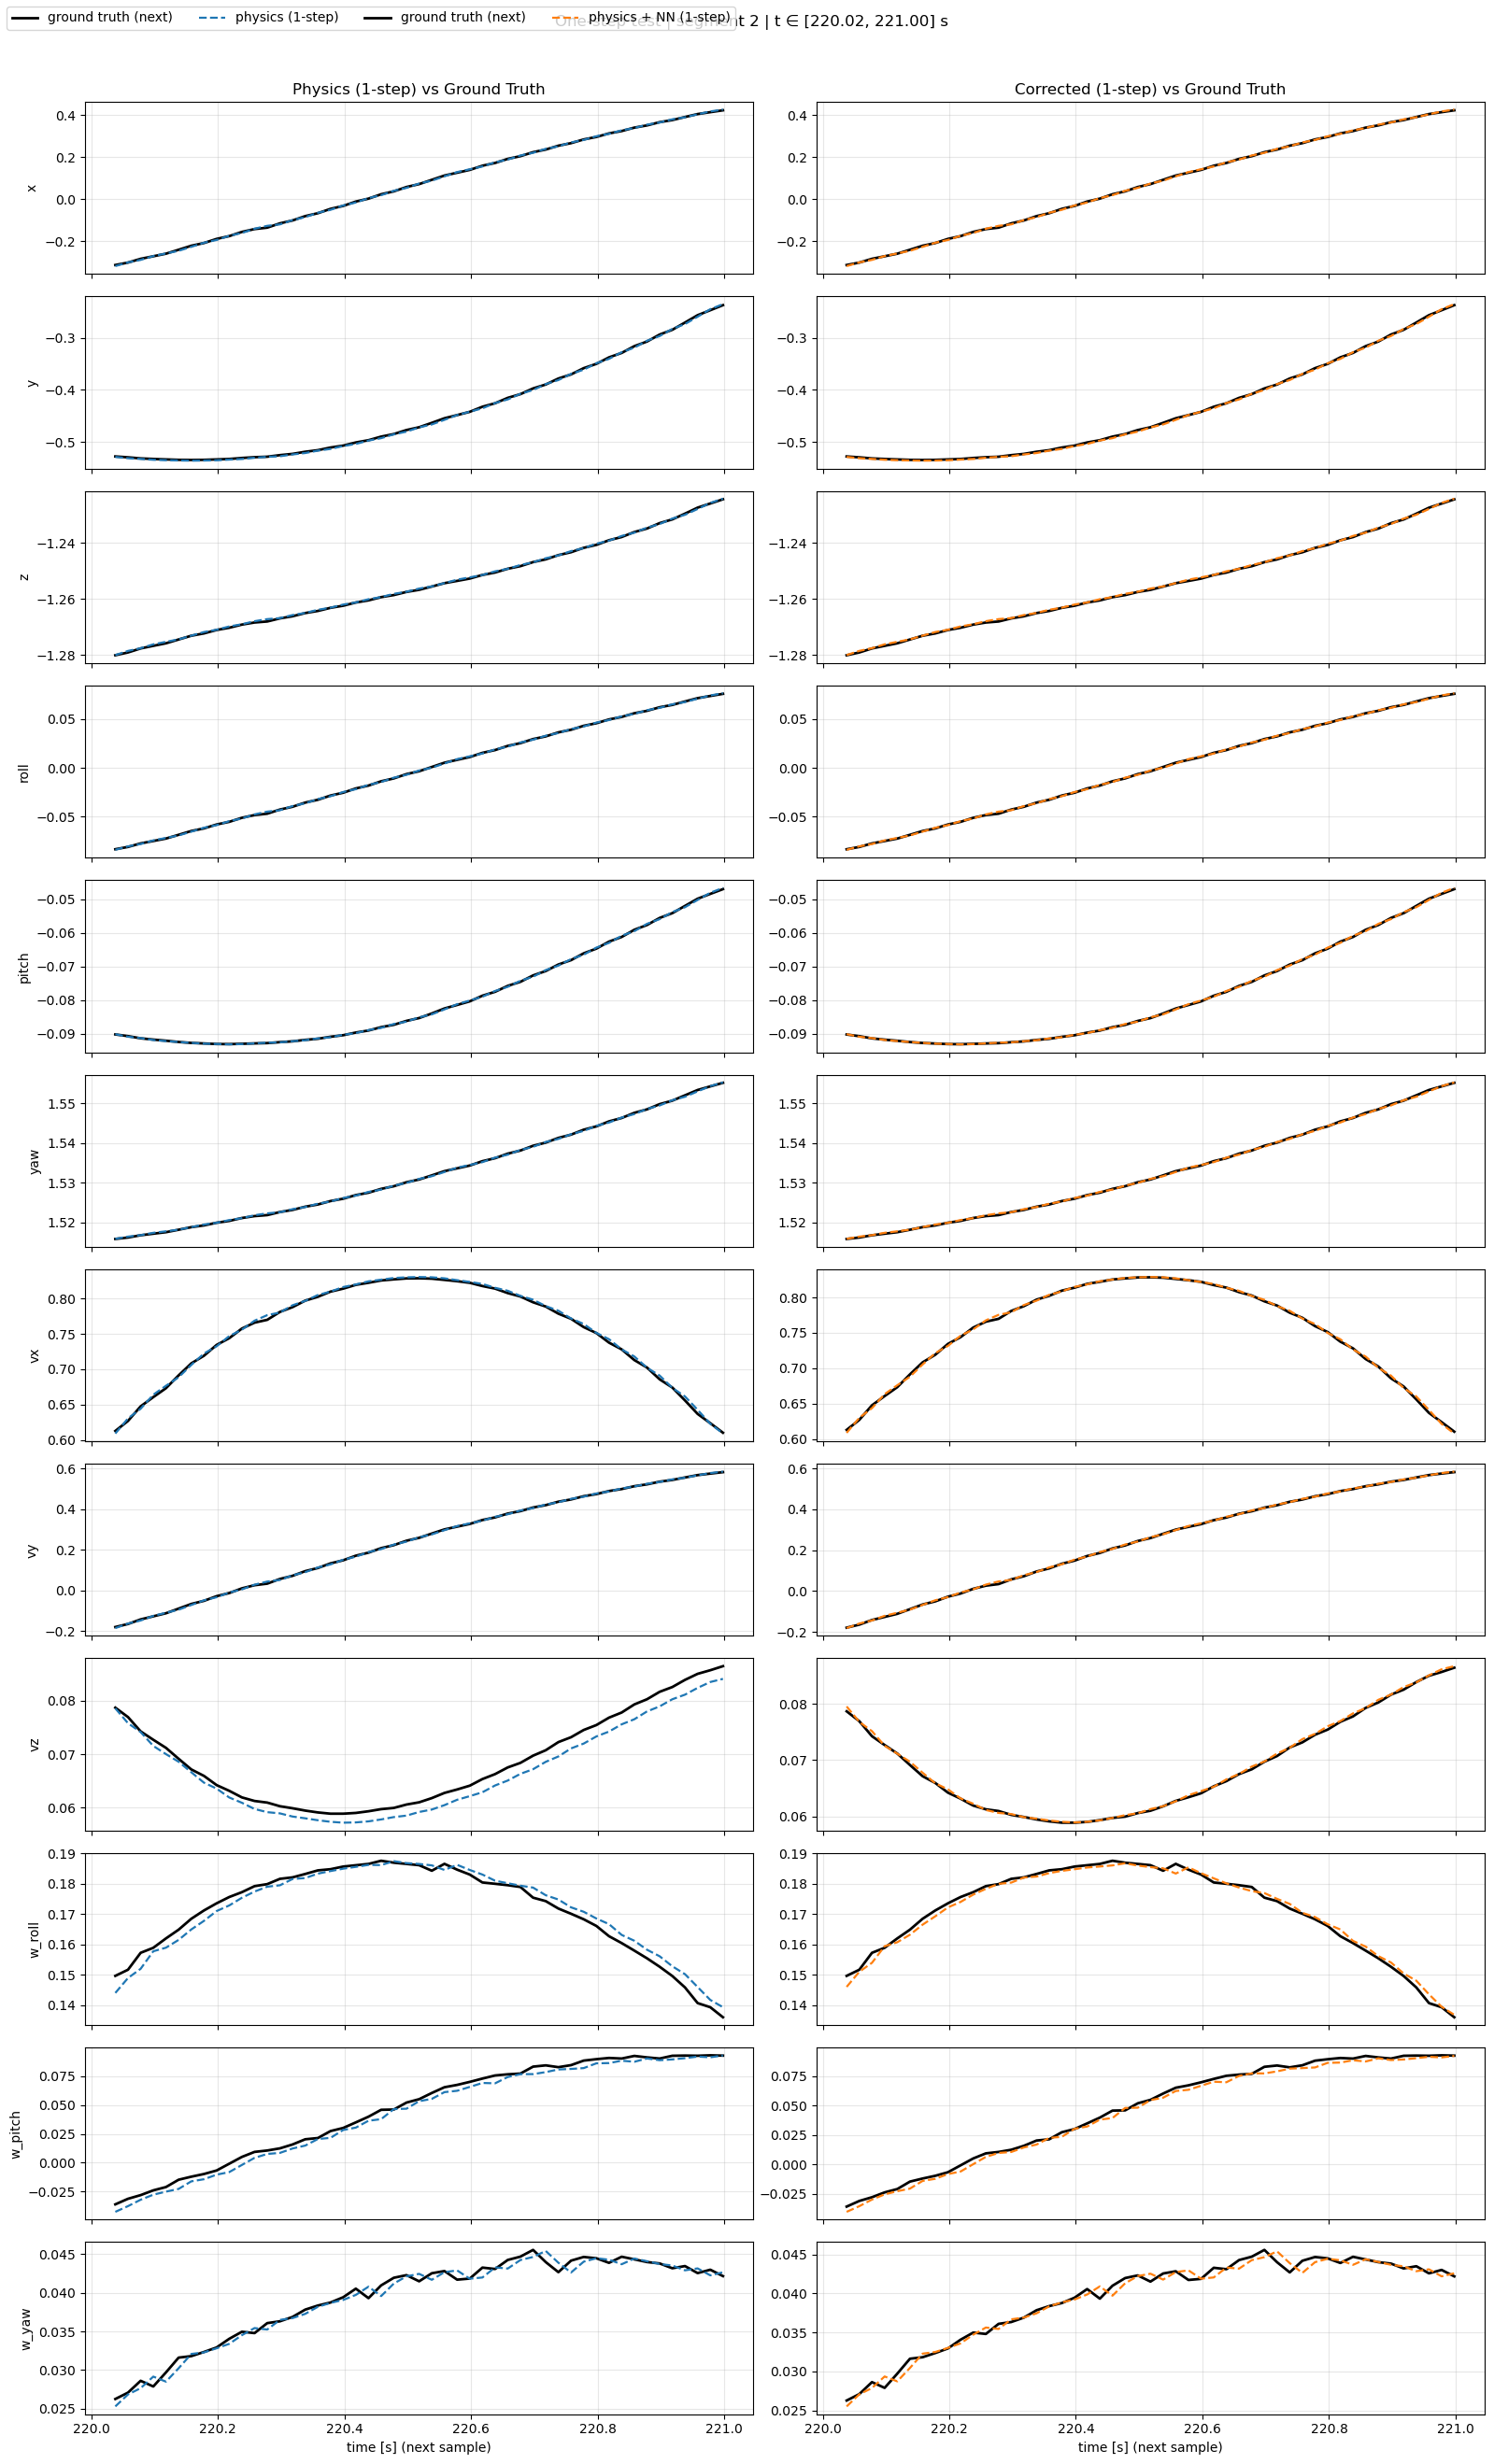

In [24]:
import numpy as np
import torch
import matplotlib.pyplot as plt

STATE_NAMES = ["x","y","z","roll","pitch","yaw","vx","vy","vz","w_roll","w_pitch","w_yaw"]

@torch.no_grad()
def one_step_predictions(model, xk, uk, dt_curr, mass, inertia, g):
    """
    xk: (N-1,12)
    uk: (N-1,4)
    dt_curr: (N-1,1) or (N-1,)
    returns:
      X_next_phys: (N-1,12)
      X_next_corr: (N-1,12)
    """
    if dt_curr.ndim == 1:
        dt_curr = dt_curr.view(-1, 1)

    # physics-only
    zero_delta_vw = torch.zeros((xk.shape[0], 6), device=xk.device, dtype=xk.dtype)
    X_next_phys = compute_new_pos_angles(zero_delta_vw, xk, uk, dt_curr, mass, inertia, g)

    # corrected
    delta_vw = denormalize_delta_vw(model(xk, uk))  # physical units, (N-1,6)
    X_next_corr = compute_new_pos_angles(delta_vw, xk, uk, dt_curr, mass, inertia, g)

    return X_next_phys, X_next_corr

def plot_two_column_next_state(t_next, X_next_gt, X_next_phys, X_next_corr, title):
    """
    t_next: (N-1,)
    X_next_*: (N-1,12)
    """
    n_states = 12
    fig, axes = plt.subplots(n_states, 2, figsize=(16, 2.2 * n_states), sharex=True)

    for i in range(n_states):
        axL = axes[i, 0]
        axL.plot(t_next, X_next_gt[:, i], "k-", lw=2, label="ground truth (next)")
        axL.plot(t_next, X_next_phys[:, i], "C0--", lw=1.6, label="physics (1-step)")
        axL.set_ylabel(STATE_NAMES[i])
        axL.grid(True, alpha=0.3)
        if i == 0:
            axL.set_title("Physics (1-step) vs Ground Truth")
        if i == n_states - 1:
            axL.set_xlabel("time [s] (next sample)")

        axR = axes[i, 1]
        axR.plot(t_next, X_next_gt[:, i], "k-", lw=2, label="ground truth (next)")
        axR.plot(t_next, X_next_corr[:, i], "C1--", lw=1.6, label="physics + NN (1-step)")
        axR.grid(True, alpha=0.3)
        if i == 0:
            axR.set_title("Corrected (1-step) vs Ground Truth")
        if i == n_states - 1:
            axR.set_xlabel("time [s] (next sample)")

    handlesL, labelsL = axes[0, 0].get_legend_handles_labels()
    handlesR, labelsR = axes[0, 1].get_legend_handles_labels()
    fig.legend(handlesL + handlesR, labelsL + labelsR, loc="upper left", ncol=4, frameon=True)

    fig.suptitle(title, y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.985])
    plt.show()

# ---------- run on your test segments ----------
mass = 2.0
inertia = torch.tensor([0.0217, 0.0217, 0.04], dtype=torch.float32, device=device)
g = 9.81

model = trained_model.to(device)
model.eval()

for seg_i, seg in enumerate(data_test_segments):
    # seg: (N, dataset_cols)
    states_np, controls_np, dt_np = configure_data(seg)  # states_np: (N,18), controls_np: (N,4), dt_np: (N,1)

    X = torch.tensor(states_np[:, :12], dtype=torch.float32, device=device)  # (N,12)
    U = torch.tensor(controls_np, dtype=torch.float32, device=device)        # (N,4)
    dt = torch.tensor(dt_np.squeeze(-1), dtype=torch.float32, device=device) # (N,)

    # Build 1-step pairs inside the segment
    xk = X[:-1]
    X_next_gt = X[1:, :]

    uk = U[:-1]  # current control aligns with the real-control inner-loop model

    # dt that takes you from curr -> next (dt[0] is often 0 due to diff; so use dt[1:])
    dt_curr = dt[1:]  # dt taking you from x[k] to x[k+1]

    # time axis: next sample times
    t_next = seg[1:, 0]

    X_next_phys, X_next_corr = one_step_predictions(
        model=model,
        xk=xk,
        uk=uk,
        dt_curr=dt_curr,
        mass=mass,
        inertia=inertia,
        g=g
    )

    plot_two_column_next_state(
        t_next=t_next,
        X_next_gt=X_next_gt.detach().cpu().numpy(),
        X_next_phys=X_next_phys.detach().cpu().numpy(),
        X_next_corr=X_next_corr.detach().cpu().numpy(),
        title=f"One-step test | segment {seg_i} | t ∈ [{float(seg[0,0]):.2f}, {float(seg[-1,0]):.2f}] s"
    )


# Multistep (Euler, xavier, ELu)

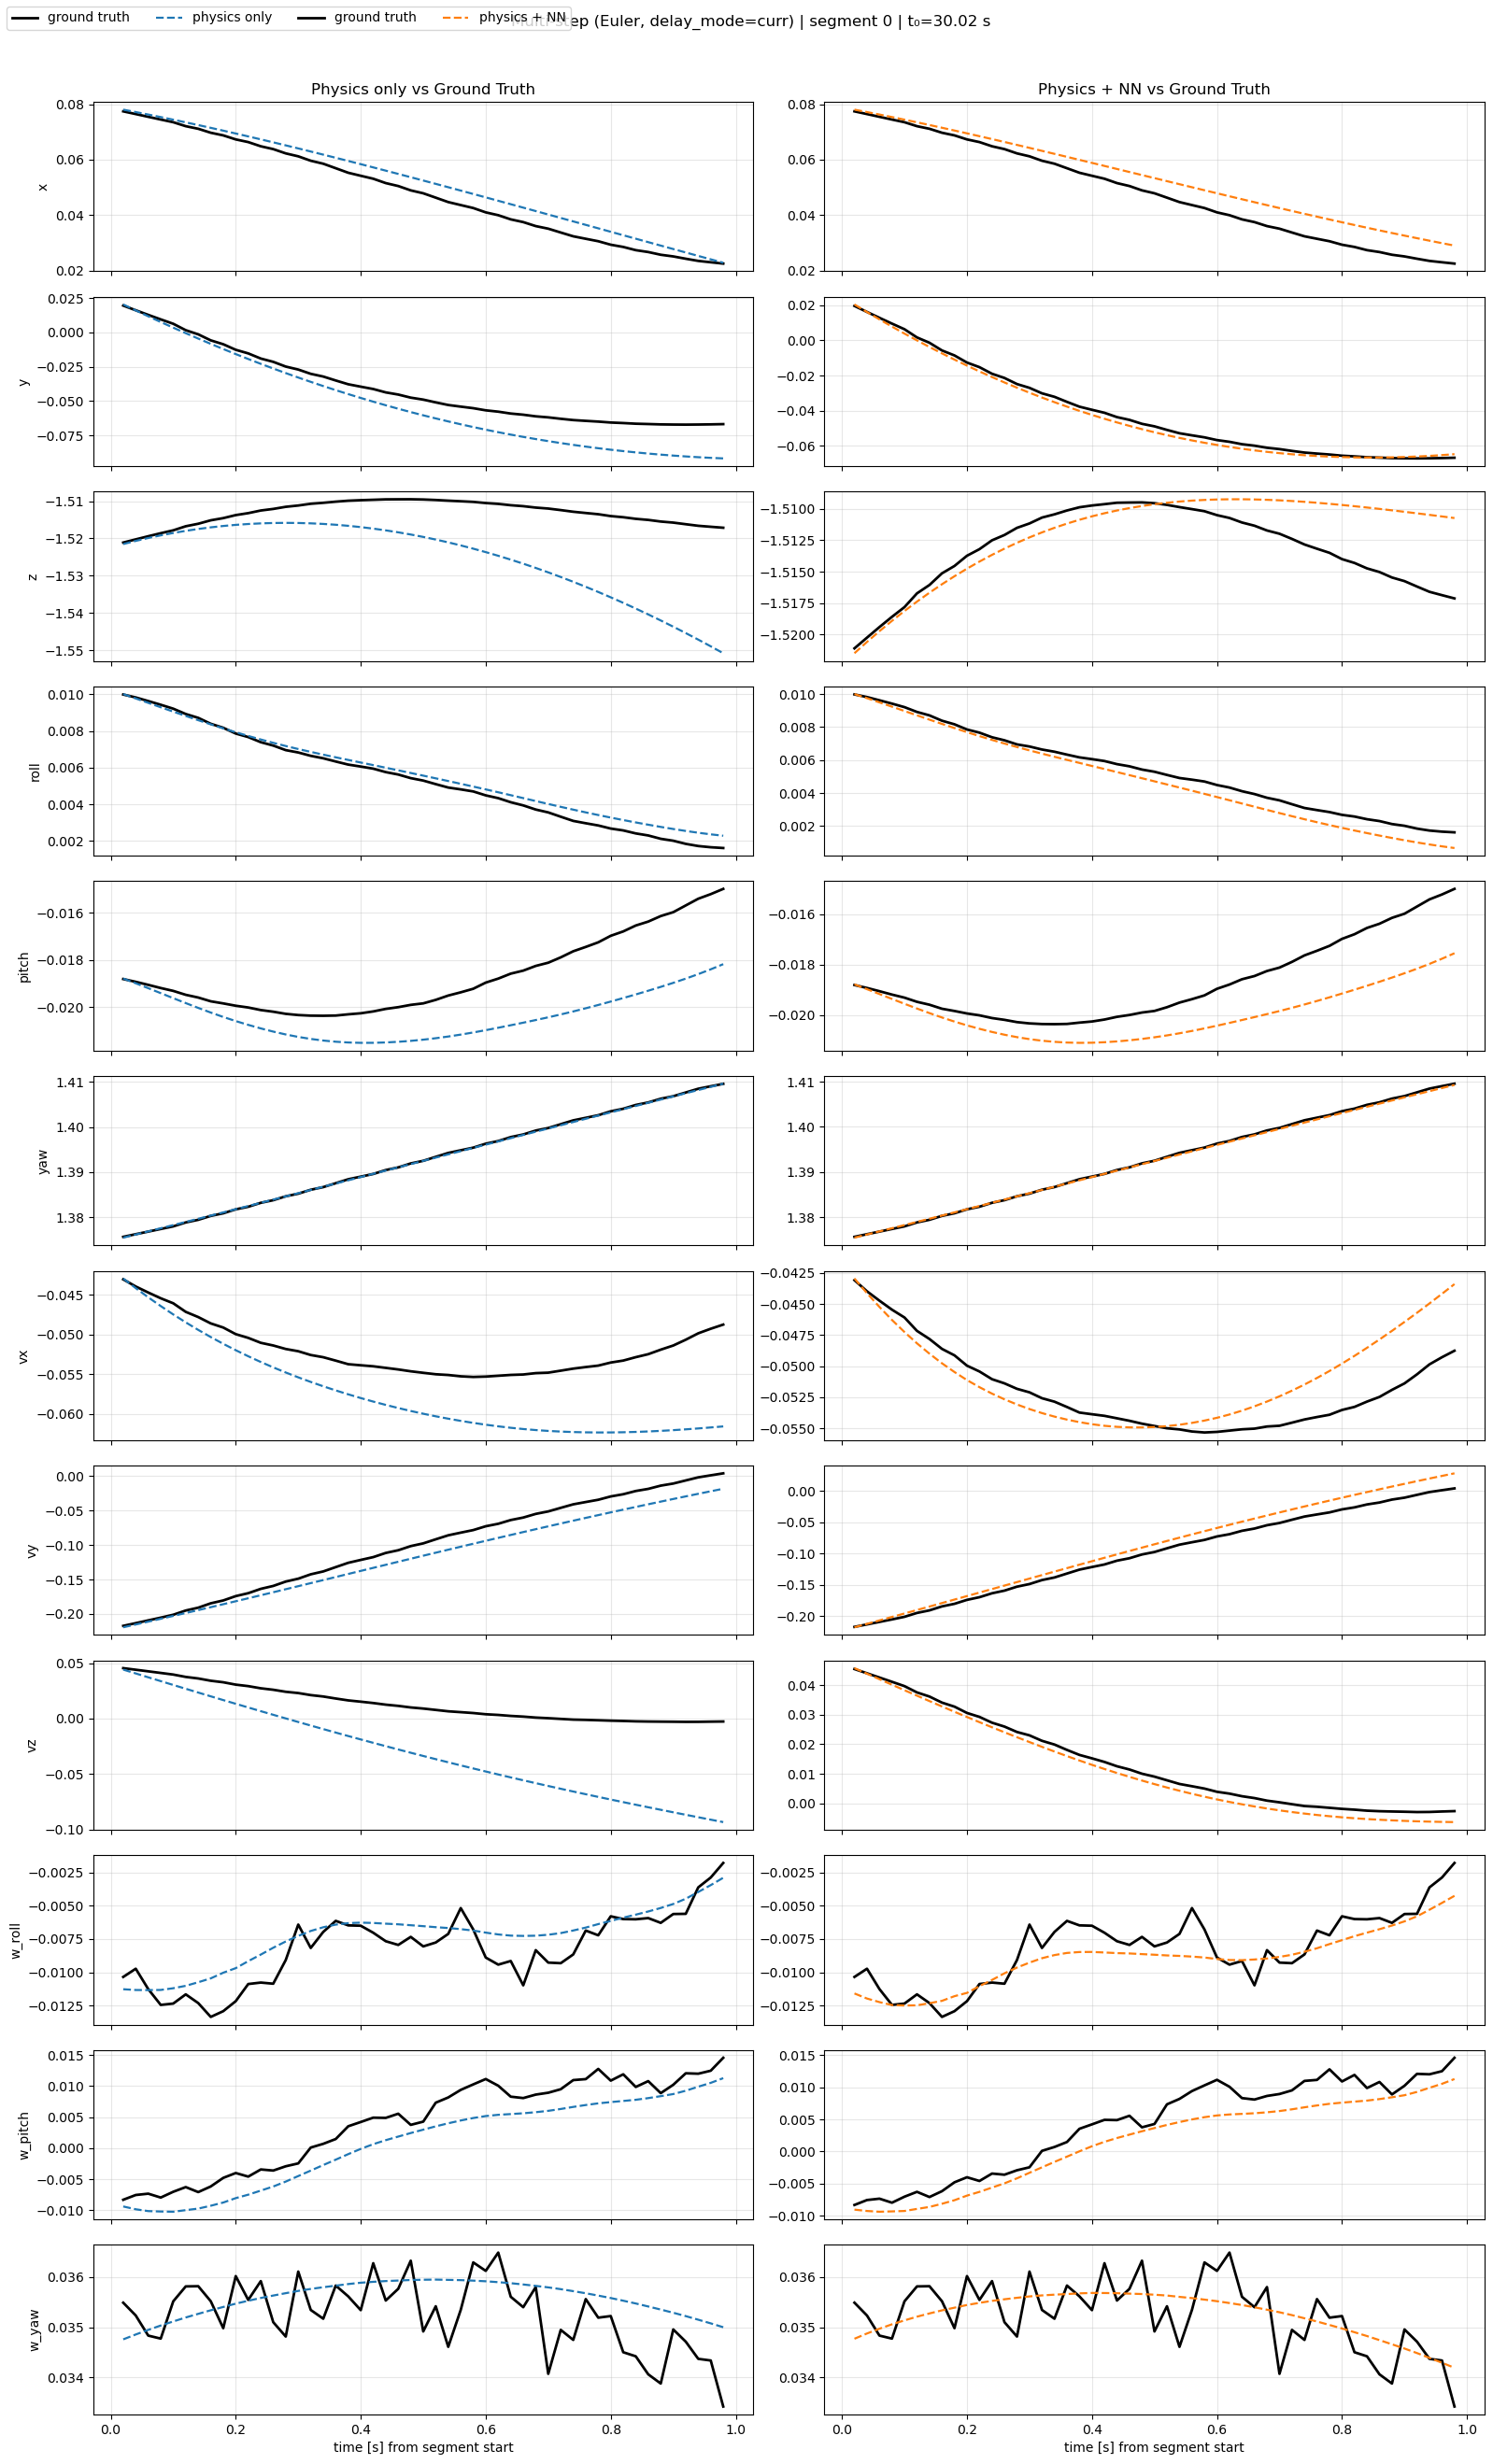

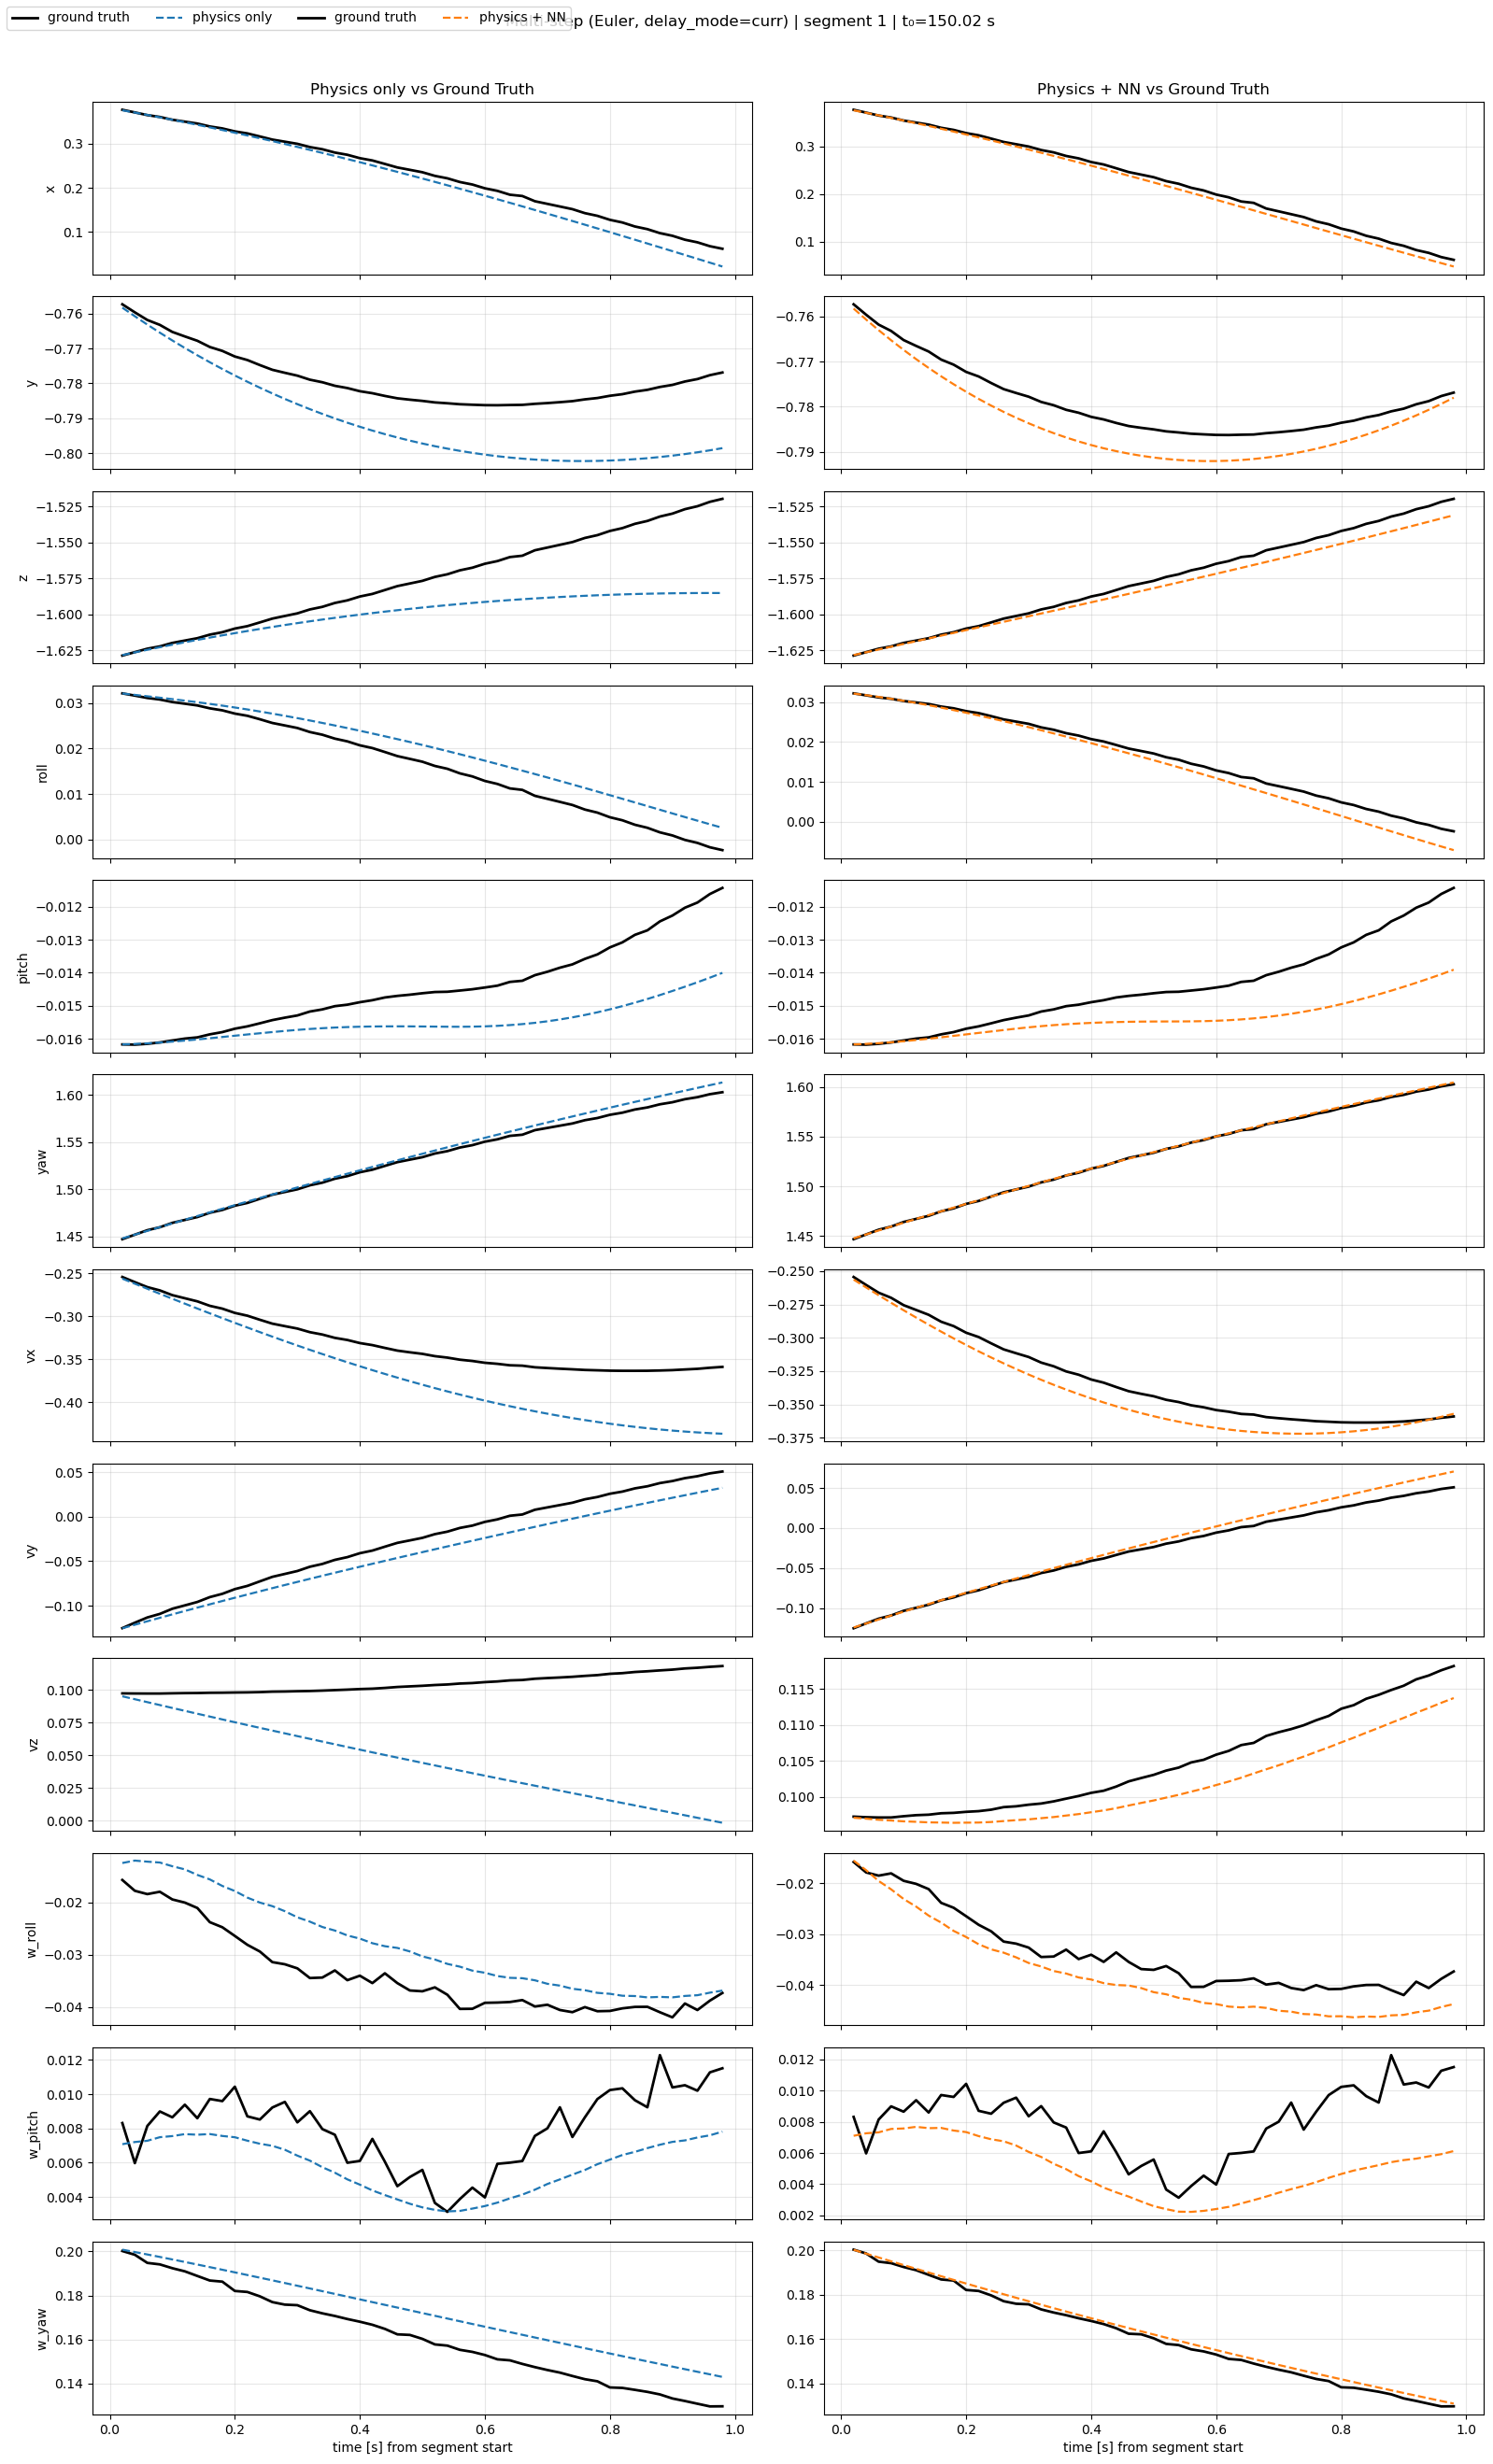

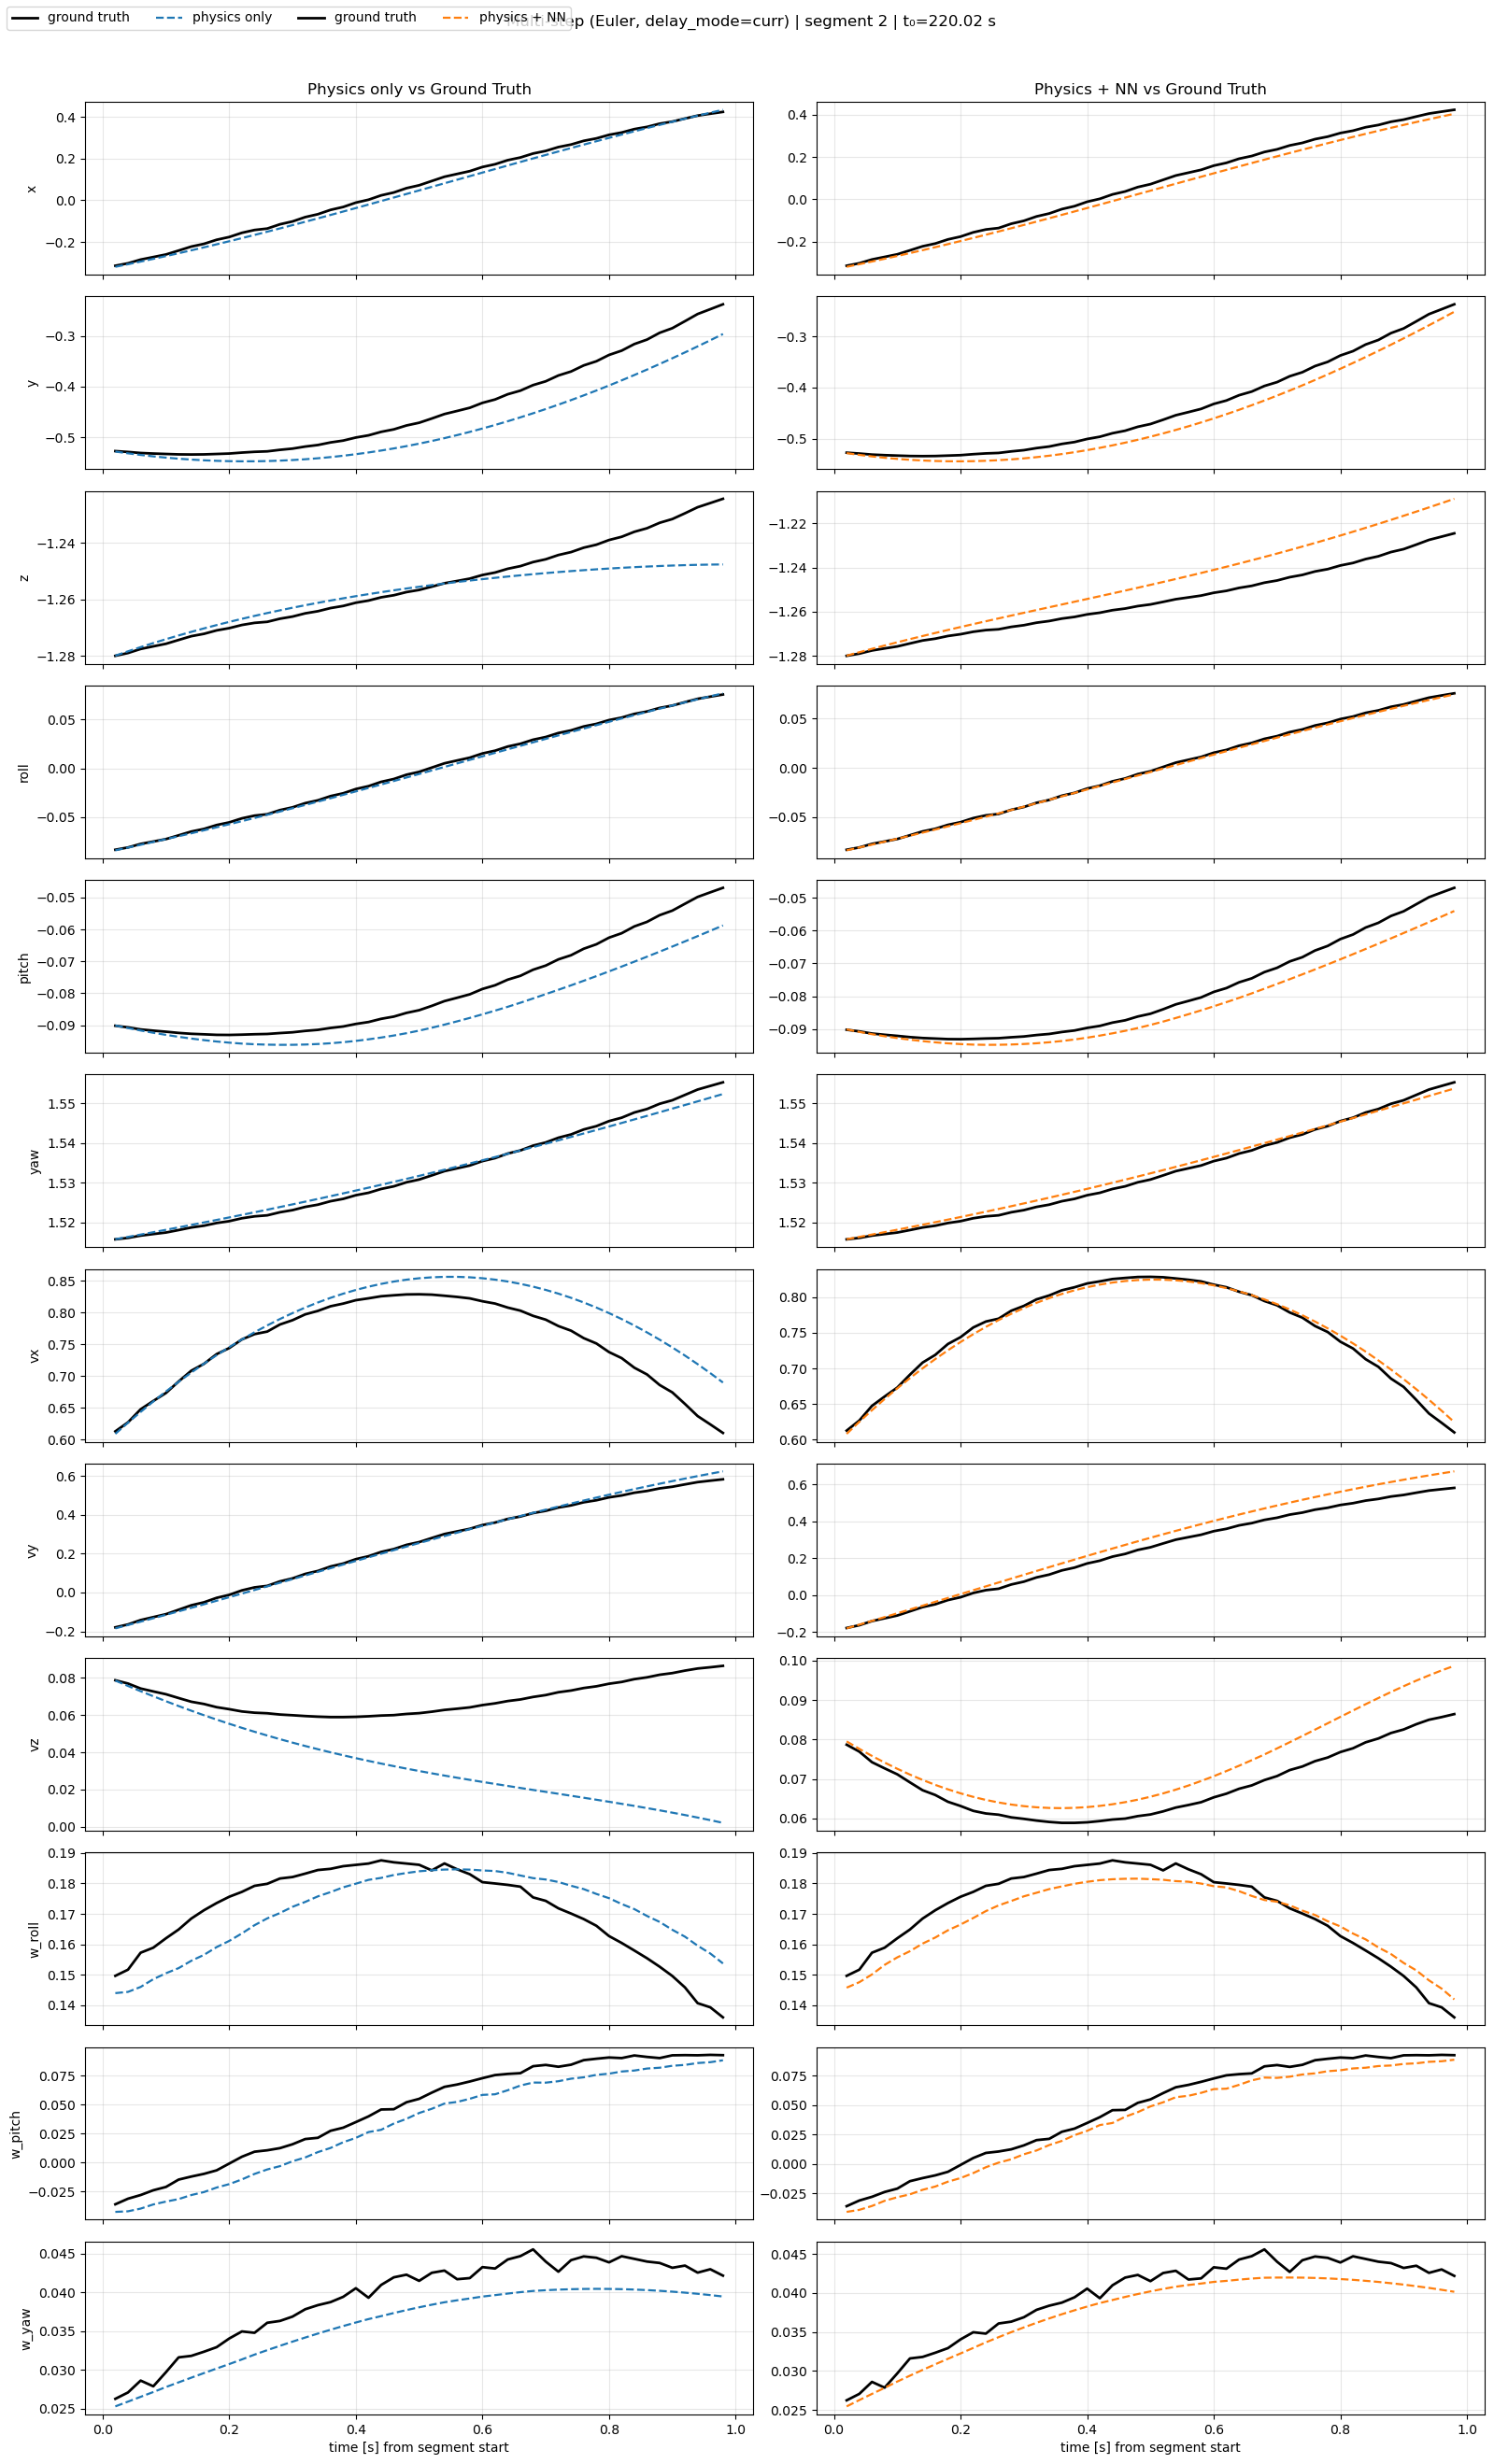

In [47]:
import numpy as np
import torch
import matplotlib.pyplot as plt

STATE_NAMES = ["x","y","z","roll","pitch","yaw","vx","vy","vz","w_roll","w_pitch","w_yaw"]

# multistep_rollout (Euler + RK4) is defined in the integrator cell above.

def plot_two_column_next_state(t_next, X_next_gt, X_next_phys, X_next_corr, title):
    """
    Two-column plot: left = physics-only, right = physics + NN correction.
    t_next     : 1-D array of time values (seconds from segment start)
    X_next_*   : (N-1, 12) numpy arrays
    """
    n_states = 12
    fig, axes = plt.subplots(n_states, 2, figsize=(16, 2.2 * n_states), sharex=True)

    for i in range(n_states):
        axL = axes[i, 0]
        axL.plot(t_next, X_next_gt[:, i], "k-", lw=2, label="ground truth")
        axL.plot(t_next, X_next_phys[:, i], "C0--", lw=1.6, label="physics only")
        axL.set_ylabel(STATE_NAMES[i])
        axL.grid(True, alpha=0.3)
        if i == 0:
            axL.set_title("Physics only vs Ground Truth")
        if i == n_states - 1:
            axL.set_xlabel("time [s] from segment start")

        axR = axes[i, 1]
        axR.plot(t_next, X_next_gt[:, i], "k-", lw=2, label="ground truth")
        axR.plot(t_next, X_next_corr[:, i], "C1--", lw=1.6, label="physics + NN")
        axR.grid(True, alpha=0.3)
        if i == 0:
            axR.set_title("Physics + NN vs Ground Truth")
        if i == n_states - 1:
            axR.set_xlabel("time [s] from segment start")

    hL, lL = axes[0,0].get_legend_handles_labels()
    hR, lR = axes[0,1].get_legend_handles_labels()
    fig.legend(hL + hR, lL + lR, loc="upper left", ncol=4, frameon=True)
    fig.suptitle(title, y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.985])
    plt.show()


# ---------- run on test segments (Euler multi-step) ----------
mass    = 2.0
inertia = torch.tensor([0.0217, 0.0217, 0.04], dtype=torch.float32, device=device)
g       = 9.81

delay_mode = "curr"  # choose "next" for the shifted-control interpretation

model = trained_model.to(device)
model.eval()

for seg_i, seg in enumerate(data_test_segments):
    states_np, controls_np, dt_np = configure_data(seg)

    X  = torch.tensor(states_np[:, :12], dtype=torch.float32, device=device)
    U  = torch.tensor(controls_np,       dtype=torch.float32, device=device)
    dt = torch.tensor(dt_np.squeeze(-1), dtype=torch.float32, device=device)

    xk, X_next_gt, U_seq, dt_seq = build_aligned_transitions(X, U, dt, delay_mode=delay_mode)
    t_next = seg[1:, 0] - seg[0, 0]

    X0 = X[0]

    X_hat_phys = multistep_rollout(
        model, X0, U_seq, dt_seq.view(-1), mass, inertia, g,
        use_nn=False, integrator="rk4"
    )
    X_hat_corr = multistep_rollout(
        model, X0, U_seq, dt_seq.view(-1), mass, inertia, g,
        use_nn=True, integrator="rk4"
    )

    plot_two_column_next_state(
        t_next=t_next,
        X_next_gt=X_next_gt.detach().cpu().numpy(),
        X_next_phys=X_hat_phys[1:].detach().cpu().numpy(),
        X_next_corr=X_hat_corr[1:].detach().cpu().numpy(),
        title=f"Multi-step (Euler, delay_mode={delay_mode}) | segment {seg_i} | t₀={float(seg[0,0]):.2f} s"
    )



**Step 8: Plot position error in 3D**

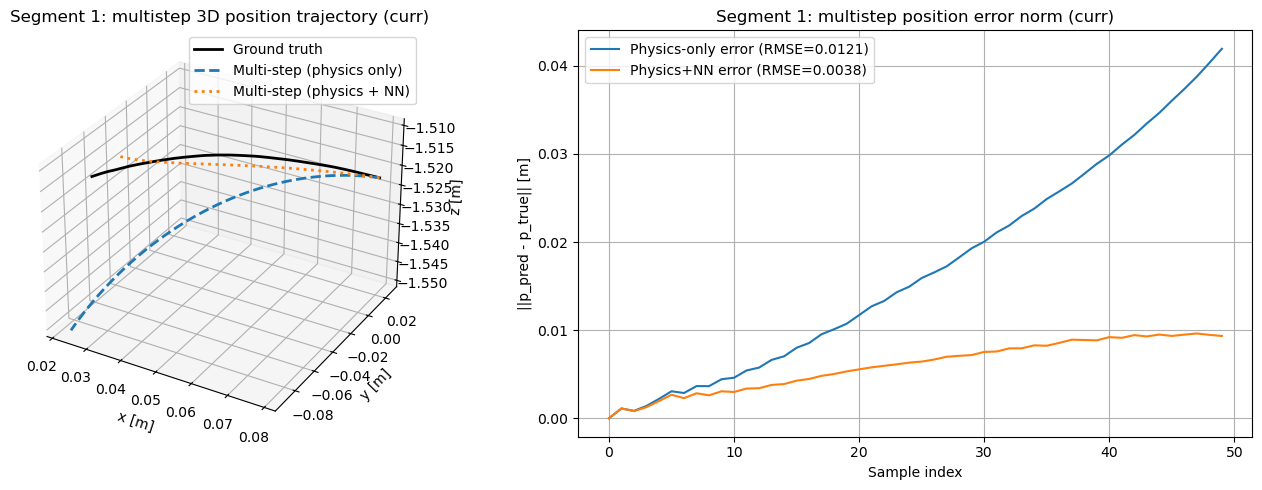

Segment 1 position RMSE -> physics-only: 0.012091, physics+NN: 0.003828


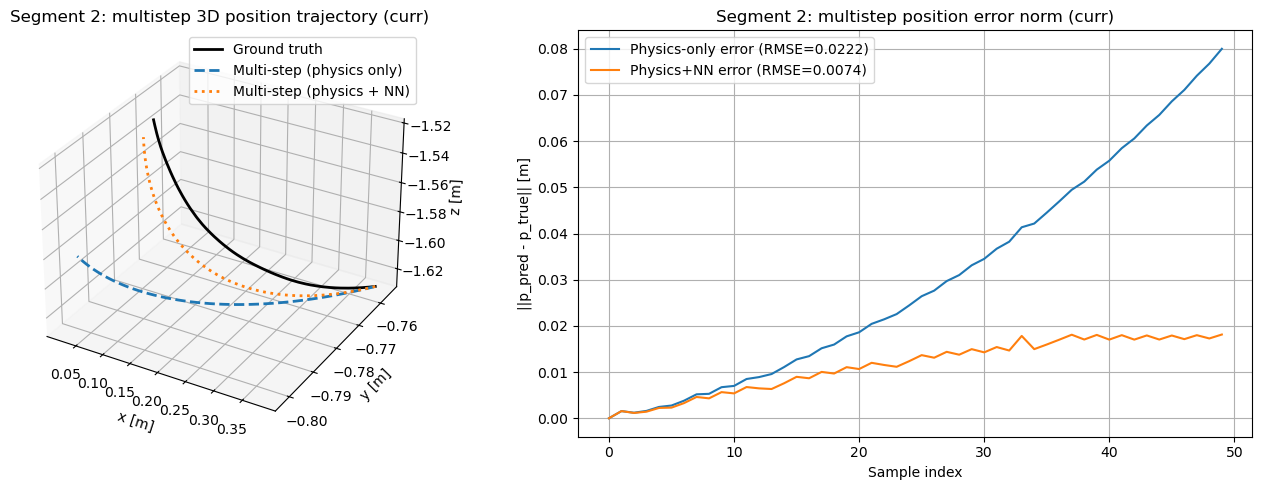

Segment 2 position RMSE -> physics-only: 0.022233, physics+NN: 0.007392


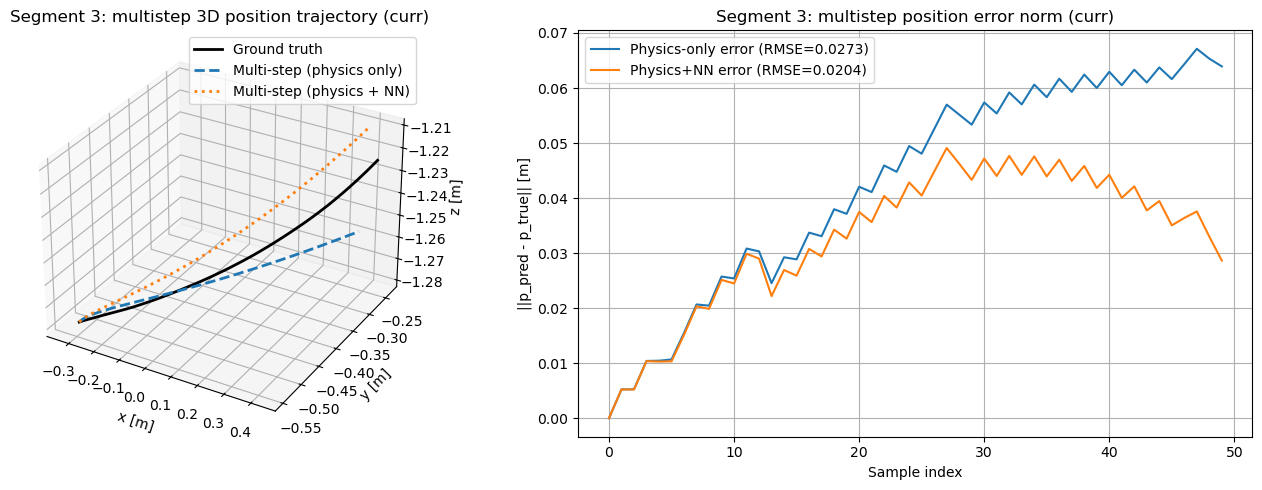

Segment 3 position RMSE -> physics-only: 0.027259, physics+NN: 0.020445


In [48]:
import torch
import numpy as np
import matplotlib.pyplot as plt

model = trained_model.to(device)
model.eval()

delay_mode = "curr"

for seg_idx, seg in enumerate(data_test_segments, start=1):
    if seg.shape[0] < 3:
        continue

    states, controls, dt_seg = configure_data(seg)

    X = torch.tensor(states[:, :12], dtype=torch.float32, device=device)
    U = torch.tensor(controls, dtype=torch.float32, device=device)
    dt = torch.tensor(dt_seg.squeeze(-1), dtype=torch.float32, device=device)

    _, X_next_gt, U_seq, dt_seq = build_aligned_transitions(X, U, dt, delay_mode=delay_mode)

    with torch.no_grad():
        X_hat_phys = multistep_rollout(
            model=model,
            X0=X[0],
            U_seq=U_seq,
            dt_seq=dt_seq.view(-1),
            mass=mass,
            inertia=inertia,
            g=g,
            use_nn=False,
            integrator="rk4"
        )

        X_hat_nn = multistep_rollout(
            model=model,
            X0=X[0],
            U_seq=U_seq,
            dt_seq=dt_seq.view(-1),
            mass=mass,
            inertia=inertia,
            g=g,
            use_nn=True,
            integrator="rk4"
        )

    gt_pos = X[:, 0:3].detach().cpu().numpy()
    phys_pos = X_hat_phys[:, 0:3].detach().cpu().numpy()
    nn_pos   = X_hat_nn[:, 0:3].detach().cpu().numpy()

    err_phys = np.linalg.norm(phys_pos - gt_pos, axis=1)
    err_nn   = np.linalg.norm(nn_pos   - gt_pos, axis=1)

    rmse_phys = float(np.sqrt(np.mean((phys_pos - gt_pos) ** 2)))
    rmse_nn   = float(np.sqrt(np.mean((nn_pos   - gt_pos) ** 2)))

    fig = plt.figure(figsize=(14, 5))

    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    ax1.plot(gt_pos[:, 0], gt_pos[:, 1], gt_pos[:, 2], label="Ground truth", linewidth=2, color = "black")
    ax1.plot(phys_pos[:, 0], phys_pos[:, 1], phys_pos[:, 2], "--", label="Multi-step (physics only)", linewidth=2)
    ax1.plot(nn_pos[:, 0], nn_pos[:, 1], nn_pos[:, 2], ":", label="Multi-step (physics + NN)", linewidth=2)
    ax1.set_title(f"Segment {seg_idx}: multistep 3D position trajectory ({delay_mode})")
    ax1.set_xlabel("x [m]")
    ax1.set_ylabel("y [m]")
    ax1.set_zlabel("z [m]")
    ax1.legend()

    ax2 = fig.add_subplot(1, 2, 2)
    ax2.plot(err_phys, label=f"Physics-only error (RMSE={rmse_phys:.4f})")
    ax2.plot(err_nn,   label=f"Physics+NN error (RMSE={rmse_nn:.4f})")
    ax2.set_title(f"Segment {seg_idx}: multistep position error norm ({delay_mode})")
    ax2.set_xlabel("Sample index")
    ax2.set_ylabel("||p_pred - p_true|| [m]")
    ax2.grid(True)
    ax2.legend()

    plt.tight_layout()
    plt.show()

    print(f"Segment {seg_idx} position RMSE -> physics-only: {rmse_phys:.6f}, physics+NN: {rmse_nn:.6f}")



# NN Internals Analysis

These cells reveal *how* the network is doing its job:

* **Correction magnitude vs physics** — If the NN corrections are much larger than the physics step, the NN is compensating for a poorly calibrated physical model rather than learning small residual effects.  This suggests improving the physical parameters or using a more expressive integrator.
* **Weight / bias distributions** — Healthy networks have weights roughly normally distributed around zero.  Very large weights indicate overfitting or missing regularisation.  Dead neurons (weights collapsed to ~0) can appear with ReLU but are less common with ELU.


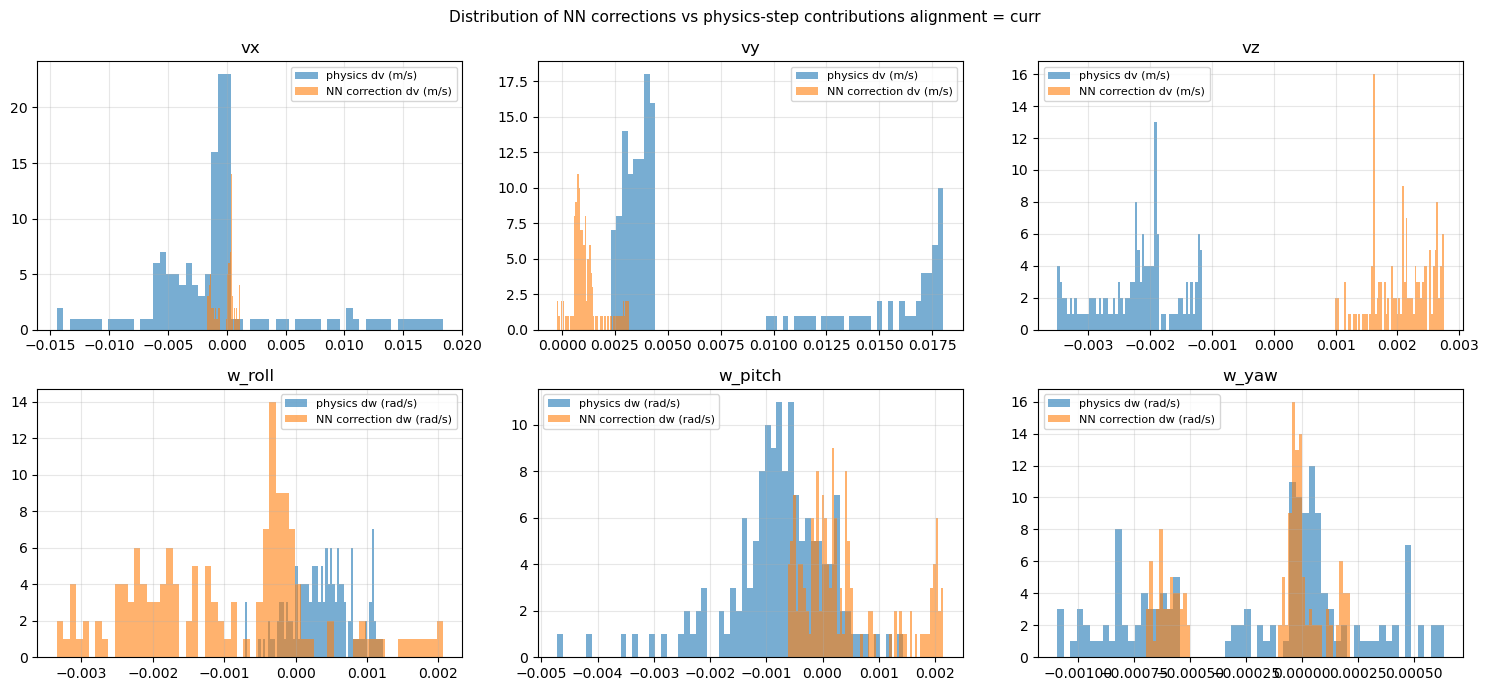

=== Correction RMS vs Physics-step RMS (alignment=curr) ===
  vx: NN=0.00084  Physics=0.00626  ratio=0.134
  vy: NN=0.00137  Physics=0.00960  ratio=0.143
  vz: NN=0.00213  Physics=0.00230  ratio=0.925
  w_roll: NN=0.00158  Physics=0.00057  ratio=2.792
  w_pitch: NN=0.00092  Physics=0.00122  ratio=0.751
  w_yaw: NN=0.00036  Physics=0.00050  ratio=0.720


In [49]:
# ── NN correction magnitude vs physics-step contribution ──
# Histograms compare the velocity change due to the NN correction (vdot_corr*dt)
# to the velocity change due to physics alone (vdot_phys*dt) over one time-step.
# Both are in m/s (or rad/s), so the ratio tells how much work the NN does.

import torch, numpy as np, matplotlib.pyplot as plt

model = trained_model.to(device)
model.eval()

delay_mode = "curr"

all_delta_v, all_delta_w = [], []
all_phys_v,  all_phys_w  = [], []

for seg in data_test_segments:
    if seg.shape[0] < 3:
        continue

    states_np, controls_np, dt_np = configure_data(seg)
    X  = torch.tensor(states_np[:, :12], dtype=torch.float32, device=device)
    U  = torch.tensor(controls_np,       dtype=torch.float32, device=device)
    dt = torch.tensor(dt_np.squeeze(-1), dtype=torch.float32, device=device)

    xk, _, uk, dt_curr = build_aligned_transitions(X, U, dt, delay_mode=delay_mode)

    with torch.no_grad():
        delta_vw = denormalize_delta_vw(model(xk, uk))
        xdot     = system_dynamics(xk, uk, mass=mass, inertia=inertia, g=g)

    all_delta_v.append((delta_vw[:, 0:3] * dt_curr).cpu())
    all_delta_w.append((delta_vw[:, 3:6] * dt_curr).cpu())
    all_phys_v.append((xdot[:, 6:9]  * dt_curr).cpu())
    all_phys_w.append((xdot[:, 9:12] * dt_curr).cpu())

delta_v = torch.cat(all_delta_v).numpy()
delta_w = torch.cat(all_delta_w).numpy()
phys_v  = torch.cat(all_phys_v).numpy()
phys_w  = torch.cat(all_phys_w).numpy()

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
v_names = ["vx", "vy", "vz"]
w_names = ["w_roll", "w_pitch", "w_yaw"]

for i, name in enumerate(v_names):
    ax = axes[0, i]
    ax.hist(phys_v[:, i],  bins=60, alpha=0.6, label="physics dv (m/s)", color="C0")
    ax.hist(delta_v[:, i], bins=60, alpha=0.6, label="NN correction dv (m/s)", color="C1")
    ax.set_title(f"{name}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for i, name in enumerate(w_names):
    ax = axes[1, i]
    ax.hist(phys_w[:, i],  bins=60, alpha=0.6, label="physics dw (rad/s)", color="C0")
    ax.hist(delta_w[:, i], bins=60, alpha=0.6, label="NN correction dw (rad/s)", color="C1")
    ax.set_title(f"{name}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "Distribution of NN corrections vs physics-step contributions "
    f"alignment = {delay_mode}",
    fontsize=11
)
plt.tight_layout()
plt.show()

_EPS = 1e-9
print(f"=== Correction RMS vs Physics-step RMS (alignment={delay_mode}) ===")
for i, name in enumerate(v_names):
    r_nn = float(np.sqrt(np.mean(delta_v[:, i]**2)))
    r_ph = float(np.sqrt(np.mean(phys_v[:, i]**2)))
    print(f"  {name}: NN={r_nn:.5f}  Physics={r_ph:.5f}  ratio={r_nn/max(r_ph,_EPS):.3f}")
for i, name in enumerate(w_names):
    r_nn = float(np.sqrt(np.mean(delta_w[:, i]**2)))
    r_ph = float(np.sqrt(np.mean(phys_w[:, i]**2)))
    print(f"  {name}: NN={r_nn:.5f}  Physics={r_ph:.5f}  ratio={r_nn/max(r_ph,_EPS):.3f}")


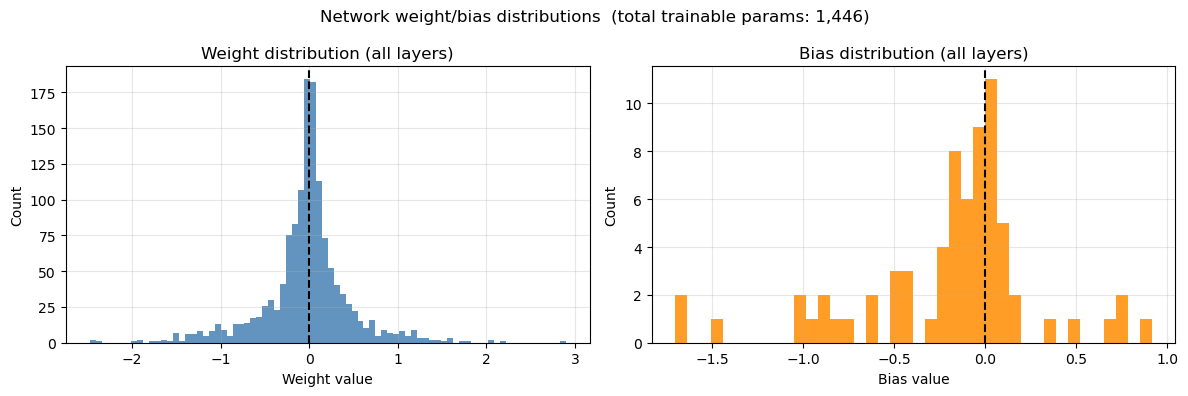

=== Layer-wise weight L2 norms ===
  corr_net.0.weight: L2 = 10.9312
  corr_net.3.weight: L2 = 11.6666
  corr_net.6.weight: L2 = 9.4079
  corr_net.9.weight: L2 = 1.0378


In [50]:
# ── Weight and bias distributions ──
# Healthy: symmetric, roughly normal distribution centred near zero.
# Warning signs:
#   - Very large weights (|w| >> 1) after L2 regularisation → still overfitting.
#   - Most weights collapsing to zero → network capacity is unused.
#   - Strong asymmetry or bimodal distribution → training instability.

import matplotlib.pyplot as plt, numpy as np

model = trained_model

all_weights, all_biases = [], []
for pname, param in model.named_parameters():
    data = param.detach().cpu().numpy().flatten()
    if "weight" in pname:
        all_weights.append(data)
    elif "bias" in pname:
        all_biases.append(data)

w_flat = np.concatenate(all_weights) if all_weights else np.array([])
b_flat = np.concatenate(all_biases)  if all_biases  else np.array([])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(w_flat, bins=80, color="steelblue", alpha=0.85)
axes[0].axvline(0, color='k', lw=1.5, ls='--')
axes[0].set_title("Weight distribution (all layers)")
axes[0].set_xlabel("Weight value"); axes[0].set_ylabel("Count")
axes[0].grid(True, alpha=0.3)

axes[1].hist(b_flat, bins=40, color="darkorange", alpha=0.85)
axes[1].axvline(0, color='k', lw=1.5, ls='--')
axes[1].set_title("Bias distribution (all layers)")
axes[1].set_xlabel("Bias value"); axes[1].set_ylabel("Count")
axes[1].grid(True, alpha=0.3)

total_params = sum(p.numel() for p in model.parameters())
plt.suptitle(f"Network weight/bias distributions  (total trainable params: {total_params:,})",
             fontsize=12)
plt.tight_layout(); plt.show()

print("=== Layer-wise weight L2 norms ===")
for pname, param in model.named_parameters():
    if 'weight' in pname:
        l2 = float(param.detach().norm(2).item())
        print(f"  {pname}: L2 = {l2:.4f}")


In [51]:
with torch.no_grad():
    xk = X[:-1]
    uk = U[:-1]
    dt_curr = dt[1:].view(-1, 1)

    xdot = system_dynamics(xk, uk, mass, inertia, g)

    vz_dot_phys = xdot[:, 8]
    vz_dot_data = (X[1:, 8] - X[:-1, 8]) / dt_curr.squeeze()

    print("mean thrust:", uk[:, 0].mean().item())
    print("mean thrust/mass:", (uk[:, 0] / mass).mean().item())
    print("g:", g)
    print("mean physics vz_dot:", vz_dot_phys.mean().item())
    print("mean data vz_dot:", vz_dot_data.mean().item())

mean thrust: -19.880123138427734
mean thrust/mass: -9.940061569213867
g: 9.81
mean physics vz_dot: -0.0854312926530838
mean data vz_dot: 0.00504542700946331


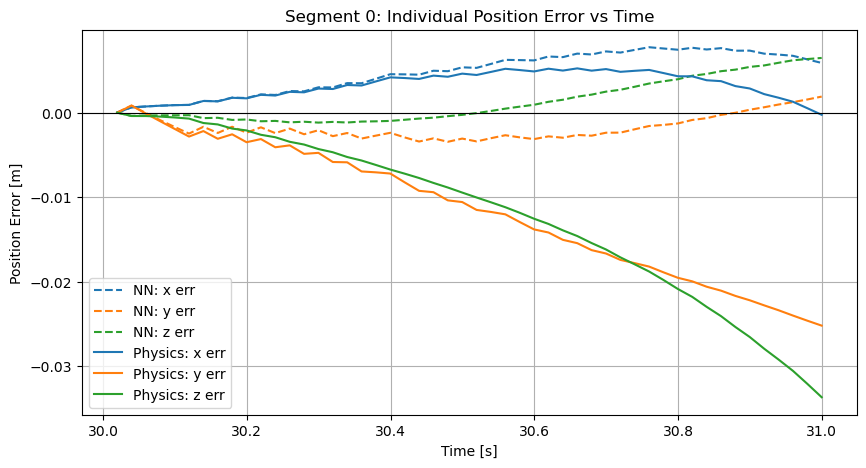

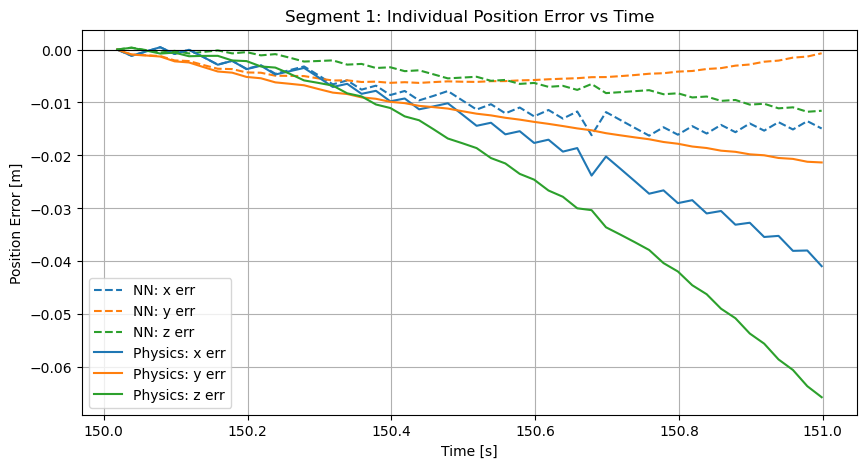

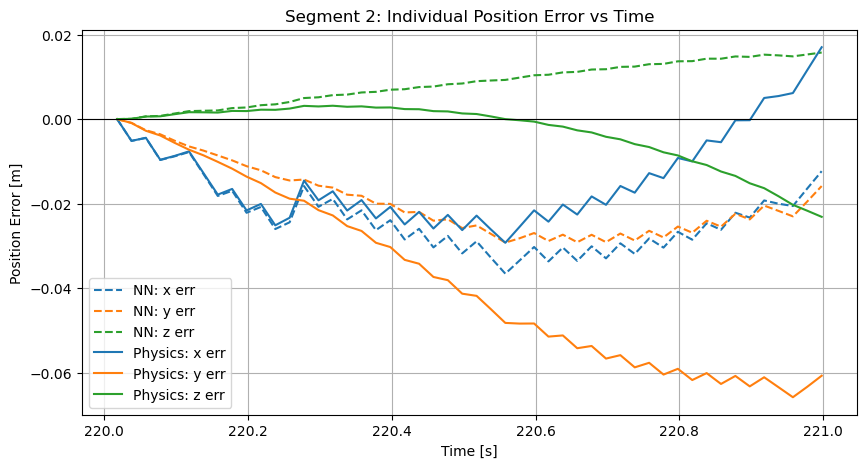

In [52]:
for seg_i, seg in enumerate(data_test_segments):

    states_np, controls_np, dt_np = configure_data(seg)

    X = torch.tensor(states_np[:, :12], dtype=torch.float32, device=device)
    U = torch.tensor(controls_np, dtype=torch.float32, device=device)

    t = seg[:, 0].astype(np.float32)
    dt_seq = torch.tensor(t[1:] - t[:-1], dtype=torch.float32, device=device)

    U_seq = U[:-1, :]
    X0 = X[0]

    X_hat_phys = multistep_rollout(
        trained_model, X0, U_seq, dt_seq,
        mass, inertia, g,
        use_nn=False
    )

    X_hat_corr = multistep_rollout(
        trained_model, X0, U_seq, dt_seq,
        mass, inertia, g,
        use_nn=True
    )

    gt   = X.detach().cpu().numpy()
    phys = X_hat_phys.detach().cpu().numpy()
    corr = X_hat_corr.detach().cpu().numpy()

    err_nn = corr[:, 0:3] - gt[:, 0:3]
    err_phys = phys[:, 0:3] - gt[:, 0:3]

    plt.figure(figsize=(10, 5))

    plt.plot(t, err_nn[:, 0], 'C0--', label='NN: x err')
    plt.plot(t, err_nn[:, 1], 'C1--', label='NN: y err')
    plt.plot(t, err_nn[:, 2], 'C2--', label='NN: z err')

    plt.plot(t, err_phys[:, 0], 'C0-', label='Physics: x err')
    plt.plot(t, err_phys[:, 1], 'C1-', label='Physics: y err')
    plt.plot(t, err_phys[:, 2], 'C2-', label='Physics: z err')

    plt.axhline(0.0, color='k', linewidth=0.8)

    plt.xlabel("Time [s]")
    plt.ylabel("Position Error [m]")
    plt.title(f"Segment {seg_i}: Individual Position Error vs Time")
    plt.legend()
    plt.grid(True)
    plt.show()

In [53]:
for mode in ["curr", "next"]:
    xk, X_next, uk, dt_curr = build_aligned_transitions(X, U, dt, delay_mode=mode)
    with torch.no_grad():
        X_phys, X_corr = one_step_predictions(
            trained_model, xk, uk, dt_curr, mass, inertia, g
        )
    rmse = torch.sqrt(torch.mean((X_corr[:, 9:12] - X_next[:, 9:12])**2, dim=0))
    print(mode, rmse)

curr tensor([0.0014, 0.0032, 0.0008], device='cuda:0')
next tensor([0.0012, 0.0026, 0.0008], device='cuda:0')


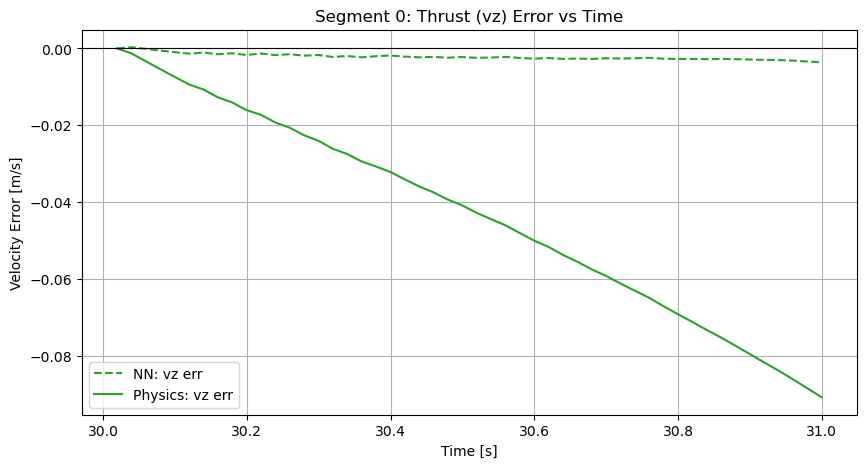

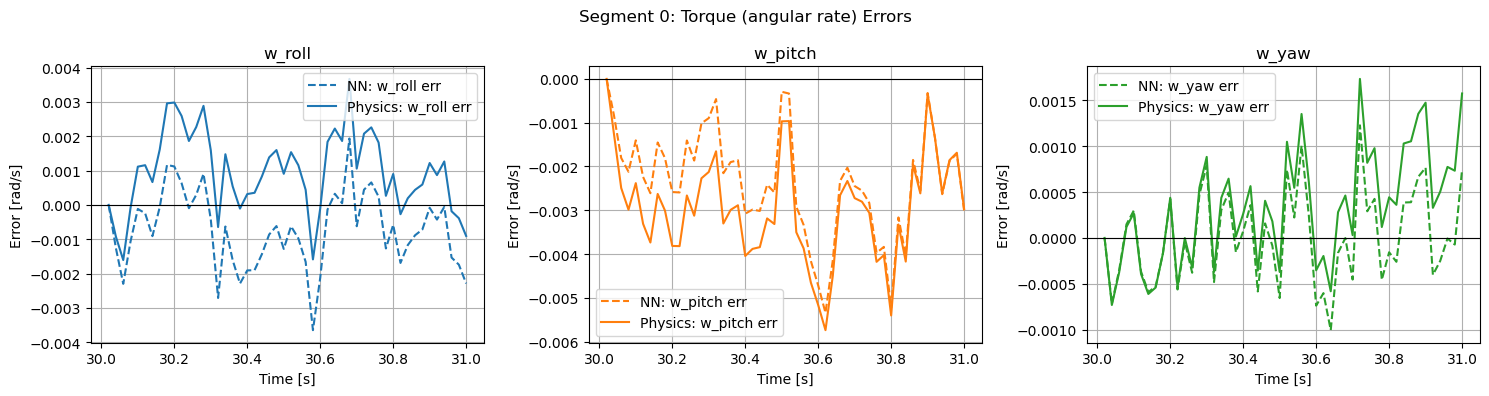

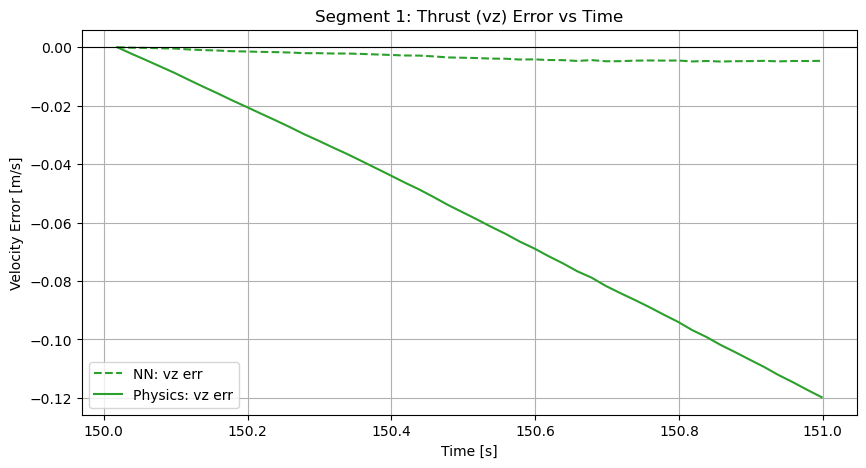

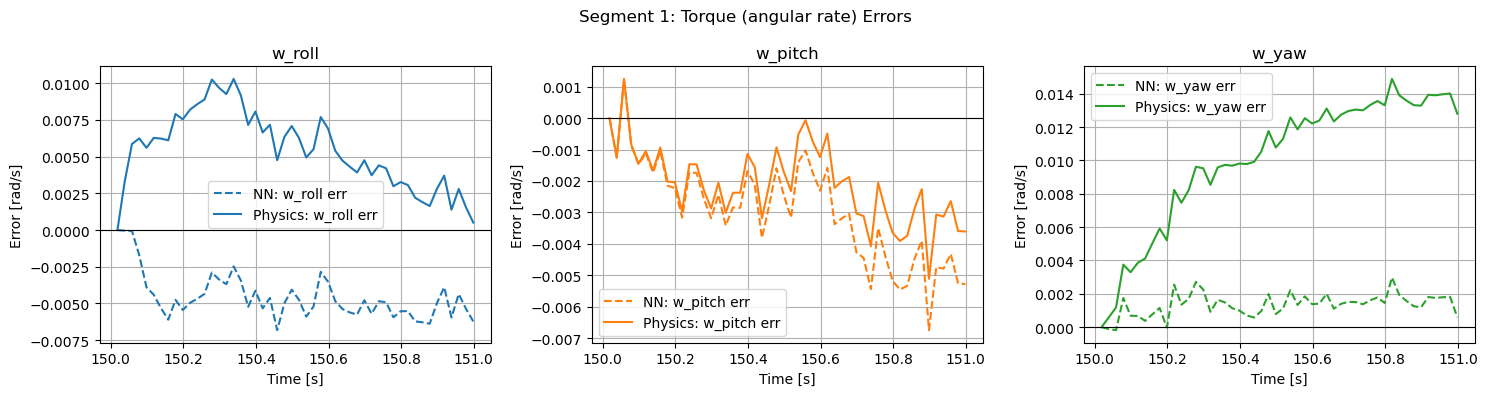

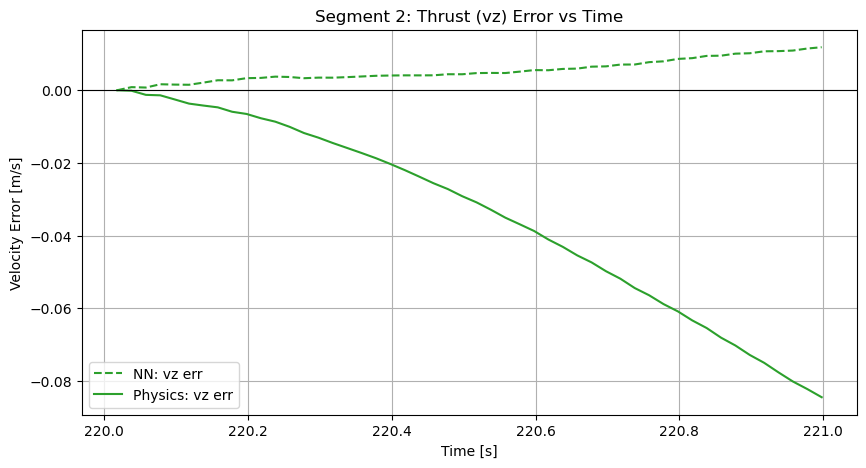

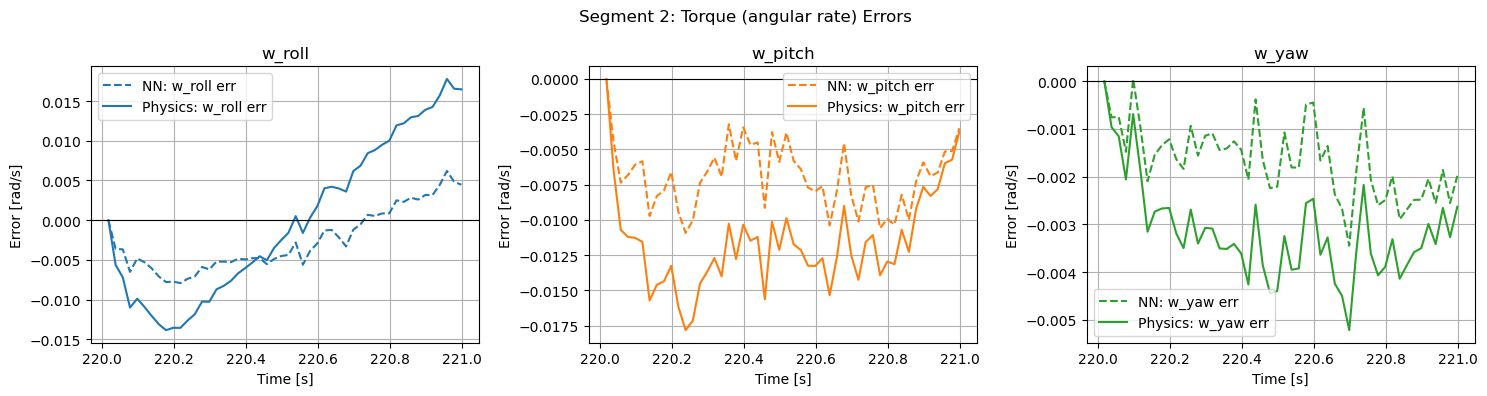

In [54]:
for seg_i, seg in enumerate(data_test_segments):

    states_np, controls_np, dt_np = configure_data(seg)

    X = torch.tensor(states_np[:, :12], dtype=torch.float32, device=device)
    U = torch.tensor(controls_np, dtype=torch.float32, device=device)

    t = seg[:, 0].astype(np.float32)
    dt_seq = torch.tensor(t[1:] - t[:-1], dtype=torch.float32, device=device)

    U_seq = U[:-1, :]
    X0 = X[0]

    X_hat_phys = multistep_rollout(
        trained_model, X0, U_seq, dt_seq,
        mass, inertia, g,
        use_nn=False
    )

    X_hat_corr = multistep_rollout(
        trained_model, X0, U_seq, dt_seq,
        mass, inertia, g,
        use_nn=True
    )

    gt   = X.detach().cpu().numpy()
    phys = X_hat_phys.detach().cpu().numpy()
    corr = X_hat_corr.detach().cpu().numpy()

    # ==============================
    # THRUST (vz)
    # ==============================
    err_nn_vz = corr[:, 8] - gt[:, 8]
    err_phys_vz = phys[:, 8] - gt[:, 8]

    plt.figure(figsize=(10,5))

    plt.plot(t, err_nn_vz, 'C2--', label='NN: vz err')
    plt.plot(t, err_phys_vz, 'C2-', label='Physics: vz err')

    plt.axhline(0.0, color='k', linewidth=0.8)

    plt.xlabel("Time [s]")
    plt.ylabel("Velocity Error [m/s]")
    plt.title(f"Segment {seg_i}: Thrust (vz) Error vs Time")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ==============================
    # TORQUES (side-by-side plots)
    # ==============================
    err_nn = corr[:, 9:12] - gt[:, 9:12]
    err_phys = phys[:, 9:12] - gt[:, 9:12]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

    names = ["w_roll", "w_pitch", "w_yaw"]
    colors = ["C0", "C1", "C2"]

    for i, ax in enumerate(axes):
        ax.plot(t, err_nn[:, i], colors[i] + '--', label=f'NN: {names[i]} err')
        ax.plot(t, err_phys[:, i], colors[i] + '-', label=f'Physics: {names[i]} err')

        ax.axhline(0.0, color='k', linewidth=0.8)
        ax.set_title(names[i])
        ax.set_xlabel("Time [s]")
        ax.set_ylabel("Error [rad/s]")
        ax.grid(True)
        ax.legend()

    fig.suptitle(f"Segment {seg_i}: Torque (angular rate) Errors")
    plt.tight_layout()
    plt.show()